# Scientific Plot Understanding — Complete Pipeline

This notebook contains **all code** from every `.py` file in the project, organized into the full pipeline:

1. **Data Generation** — `generate.py` (original), `generate_synthetic.py` (synthetic variant), `generate_kagglehub.py` (Kaggle data)
2. **YOLO Dataset Building** — `build_yolo_dataset.py`
3. **YOLO Training** — Train layout detection on each dataset
4. **Stage 2: OCR** — `stage2_ocr.py` — Extract text (labels, ticks, titles, legend)
5. **Stage 3: Curve Segmentation** — `stage3_segment.py`
6. **Stage 4: Reconstruction & Analysis** — `stage4_reconstruct.py` + `semantic_analysis.py`
7. **Testing / Visualization** — `test.py`, `batch_stage2_test.py`
8. **Cross-Dataset Comparison** — Train on one dataset, evaluate on others; mix-and-match results

### Datasets
| Dataset | Directory | Source |
|---------|-----------|--------|
| Original (generate.py) | `output/` | Synthetic math functions |
| Synthetic Unique | `synthetic_output/` | Extended synthetic variant |
| Kaggle Real Data | `kaggle_output/` | Real Kaggle CSV datasets |

---
## 0. Setup & Imports

In [7]:
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for generation
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator, FormatStrFormatter
import numpy as np
import json
import random
import re
import sys
import os
import shutil
import traceback
from pathlib import Path
from difflib import get_close_matches

import cv2
import pandas as pd
from PIL import Image, ImageDraw

# Deep learning & OCR
from ultralytics import YOLO
import easyocr

# Scientific analysis
from scipy.signal import find_peaks, savgol_filter
from sklearn.linear_model import LinearRegression

# For inline plots later
%matplotlib inline

print("All imports successful.")

All imports successful.


---
## 1. Data Generation

### 1A. Shared Utilities (used by all generators)

In [8]:
# ============================================================
# SHARED CONSTANTS & UTILITIES (from generate.py / generate_synthetic.py)
# ============================================================

CLASSES = {
    "plot_area": 0,
    "legend": 1,
    "x_label": 2,
    "y_label": 3,
    "x_ticks": 4,
    "y_ticks": 5,
    "title": 6
}

X_LABELS = ["Distance (m)", "Time (s)", "Frequency (Hz)", "Input", "Samples", "Wavelength (nm)", "Pressure (kPa)",
            "Temperature (\u00b0C)", "Flow Rate (L/min)", "Resistance (\u03a9)", "Current (A)", "Voltage (V)", "Power (W)"]
Y_LABELS = ["Amplitude", "Velocity", "Voltage", "Output", "Signal", "Power (W)", "Acceleration (m/s^2)",
            "Force (N)", "Energy (J)", "Intensity (dB)", "Frequency (Hz)", "Resistance (\u03a9)", "Capacitance (F)"]
TITLES   = ["Experiment Results", "Signal Response", "Velocity Profile", "Sample Data", "Measurement",
           "Analysis Results", "Performance Metrics", "System Response", "Test Results", ""]

LINE_FUNCS = [
    lambda x: np.sin(x),
    lambda x: np.cos(x),
    lambda x: np.tanh(x / 3),
    lambda x: x,
    lambda x: x**2 / 60,
    lambda x: np.exp(x / 10),
    lambda x: np.log(np.abs(x) + 1),
]

STYLES   = ["-", "--", ":", "-."]
MARKERS  = [None, "o", "s", "^", "x", "d"]
LEG_LOCS = ["upper left", "upper right", "lower left", "lower right", "best"]
FONTS    = ["DejaVu Sans", "Arial", "Times New Roman"]


def to_yolo_bbox(x1, y1, x2, y2, W, H):
    y1_flipped = H - y2
    y2_flipped = H - y1
    cx = ((x1 + x2) / 2) / W
    cy = ((y1_flipped + y2_flipped) / 2) / H
    w  = (x2 - x1) / W
    h  = (y2_flipped - y1_flipped) / H
    return cx, cy, w, h


def merge_boxes(boxes):
    if not boxes:
        return None
    xs1 = [b[0] for b in boxes]
    ys1 = [b[1] for b in boxes]
    xs2 = [b[2] for b in boxes]
    ys2 = [b[3] for b in boxes]
    return min(xs1), min(ys1), max(xs2), max(ys2)


def safe_float(text):
    t = text.strip().replace("\u2212", "-")
    return float(t)


def to_list(box):
    return [float(x) for x in box]


def maybe(p):
    return random.random() < p


def expand_box(box, pad=6, W=None, H=None):
    if box is None:
        return None
    x1, y1, x2, y2 = box
    x1 -= pad; y1 -= pad; x2 += pad; y2 += pad
    if W is not None and H is not None:
        x1 = max(0, x1); y1 = max(0, y1)
        x2 = min(W, x2); y2 = min(H, y2)
    return (x1, y1, x2, y2)


def force_tick_text(ax):
    ax.tick_params(labelbottom=True, labelleft=True)


def set_tick_style(ax):
    if random.random() < 0.25:
        for t in ax.get_xticklabels():
            t.set_rotation(random.choice([20, 30, 45, 60]))
            t.set_ha("right")
    if random.random() < 0.25:
        for t in ax.get_yticklabels():
            t.set_rotation(random.choice([0, 0, 90]))


def maybe_sci_notation(ax):
    if random.random() < 0.3:
        axis = random.choice(["x", "y"])
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        if axis == "x":
            ax.xaxis.set_major_formatter(formatter)
        else:
            ax.yaxis.set_major_formatter(formatter)

print("Shared utilities loaded.")

Shared utilities loaded.


### 1B. Plot Type Functions

In [9]:
# ============================================================
# PLOT TYPE FUNCTIONS (from generate.py / generate_synthetic.py)
# ============================================================

def plot_line(ax, x):
    n = random.randint(1, 4)
    labels = []
    line_objs = []
    COLORS = ["blue", "orange", "green", "red"]
    for j in range(n):
        func = random.choice(LINE_FUNCS)
        shift = random.uniform(-2, 2)
        scale = random.uniform(0.5, 2.5)
        y = scale * func(x + shift)
        y += np.random.normal(0, 0.03, size=len(x))
        line, = ax.plot(x, y, linestyle="-", marker=None, linewidth=3, color=COLORS[j % len(COLORS)])
        labels.append(f"Line {j}")
        line_objs.append(line)
    return labels, line_objs


def plot_scatter(ax, x):
    n = random.randint(1, 3)
    labels = []
    for j in range(n):
        func = random.choice(LINE_FUNCS)
        shift = random.uniform(-2, 2)
        scale = random.uniform(0.5, 2.5)
        y = scale * func(x + shift)
        y += np.random.normal(0, random.uniform(0.05, 0.4), size=len(x))
        ax.scatter(x, y, s=random.uniform(8, 35), alpha=random.uniform(0.5, 0.9),
                   marker=random.choice(["o", "s", "^", "x", "d"]))
        labels.append(f"Series {j}")
    return labels


def plot_bar(ax):
    n = random.randint(6, 14)
    x = np.arange(n)
    y = np.abs(np.random.normal(loc=random.uniform(1, 8), scale=random.uniform(0.5, 3), size=n))
    ax.bar(x, y, alpha=random.uniform(0.7, 1.0))
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in x])
    return ["Bars"]


def plot_step(ax, x):
    y = np.cumsum(np.random.normal(0, 0.3, size=len(x)))
    ax.step(x, y, where="mid", linewidth=random.uniform(1.0, 2.5))
    return ["Step"]


def plot_stem(ax, x):
    y = np.random.normal(0, 1, size=len(x))
    markerline, stemlines, baseline = ax.stem(x[::10], y[::10])
    plt.setp(stemlines, linewidth=random.uniform(0.8, 2.0))
    plt.setp(markerline, markersize=random.uniform(4, 7))
    return ["Stem"]


def plot_errorbar(ax, x):
    y = np.sin(x / random.uniform(1.5, 3.5)) + np.random.normal(0, 0.1, size=len(x))
    y = y[::10]; x2 = x[::10]
    err = np.abs(np.random.normal(0.2, 0.1, size=len(x2)))
    ax.errorbar(x2, y, yerr=err, fmt=random.choice(["o-", "s--", "^-", "x:"]), capsize=3)
    return ["Error"]


def plot_hist(ax):
    data = np.random.normal(loc=random.uniform(-2, 2), scale=random.uniform(0.5, 2.0), size=600)
    ax.hist(data, bins=random.randint(10, 30), alpha=random.uniform(0.7, 1.0))
    return ["Histogram"]

print("Plot type functions loaded.")

Plot type functions loaded.


### 1C. generate.py — Original Dataset Generator

In [10]:
# ============================================================
# generate.py — Original dataset (output/)
# ============================================================

def generate_plot_original(i, seed=None,
                           out_img=Path("output/images"), out_lbl=Path("output/labels"),
                           out_json=Path("output/ground_truth"), out_mask=Path("output/curve_masks")):
    """Generate a single plot using original generate.py logic."""
    if seed is not None:
        random.seed(seed + i)
        np.random.seed(seed + i)

    for p in [out_img, out_lbl, out_json, out_mask]:
        p.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 12
    ax.tick_params(labelsize=11)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(False)

    plot_type = "line"
    start = random.choice([-20, -10, 0])
    end = random.choice([20, 30, 40])
    x = np.linspace(start, end, random.randint(100, 200))

    legend_labels, line_objs = plot_line(ax, x)

    ax.set_xlabel(random.choice(X_LABELS))
    ax.set_ylabel(random.choice(Y_LABELS))

    title = random.choice(TITLES)
    if title and maybe(0.7):
        ax.set_title(title)

    ax.grid(False)
    force_tick_text(ax)

    has_legend = (len(legend_labels) > 0) and maybe(0.85)
    if has_legend:
        ax.legend(legend_labels, loc=random.choice(LEG_LOCS), framealpha=random.uniform(0.6, 1.0))

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    xmin = int(np.floor(xmin / 5) * 5)
    xmax = int(np.ceil(xmax / 5) * 5)
    ymin = int(np.floor(ymin / 5) * 5)
    ymax = int(np.ceil(ymax / 5) * 5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    W, H = fig.canvas.get_width_height()

    # Save curve masks
    for idx, line in enumerate(line_objs):
        mask = np.zeros((H, W), dtype=np.uint8)
        path = line.get_path().transformed(line.get_transform())
        verts = path.vertices.astype(int)
        for k in range(len(verts) - 1):
            cv2.line(mask, tuple(verts[k]), tuple(verts[k+1]), 255, thickness=4)
        mask = np.flipud(mask)
        cv2.imwrite(str(out_mask / f"plot_{i:06d}_curve_{idx}.png"), mask)

    # BBoxes
    plot_bbox = ax.get_window_extent(renderer=renderer).extents
    xlabel_bbox = expand_box(ax.xaxis.label.get_window_extent(renderer=renderer).extents, pad=8, W=W, H=H)
    ylabel_bbox = expand_box(ax.yaxis.label.get_window_extent(renderer=renderer).extents, pad=8, W=W, H=H)

    xticks = [t.get_window_extent(renderer=renderer).extents for t in ax.get_xticklabels() if t.get_text().strip()]
    yticks = [t.get_window_extent(renderer=renderer).extents for t in ax.get_yticklabels() if t.get_text().strip()]
    x_ticks_box = expand_box(merge_boxes(xticks), pad=3, W=W, H=H)
    y_ticks_box = expand_box(merge_boxes(yticks), pad=5, W=W, H=H)

    title_bbox = None
    if ax.title.get_text().strip():
        title_bbox = expand_box(ax.title.get_window_extent(renderer=renderer).extents, pad=6, W=W, H=H)

    legend_box = None
    if has_legend:
        legend = ax.get_legend()
        if legend is not None:
            legend_box = legend.get_window_extent(renderer=renderer).extents

    img_path = out_img / f"plot_{i:06d}.png"
    fig.savefig(img_path)
    plt.close(fig)

    # YOLO labels
    labels = []
    def add_box(name, box):
        if box is None: return
        cx, cy, w, h = to_yolo_bbox(*box, W, H)
        labels.append((CLASSES[name], cx, cy, w, h))

    add_box("plot_area", plot_bbox)
    add_box("legend", legend_box)
    add_box("x_label", xlabel_bbox)
    add_box("y_label", ylabel_bbox)
    add_box("x_ticks", x_ticks_box)
    add_box("y_ticks", y_ticks_box)
    add_box("title", title_bbox)

    label_path = out_lbl / f"plot_{i:06d}.txt"
    with open(label_path, "w") as f:
        for cls, cx, cy, w, h in labels:
            f.write(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    # Ground truth JSON
    boxes_px = {
        "plot_area": to_list(plot_bbox),
        "legend": to_list(legend_box) if legend_box is not None else None,
        "x_label": to_list(xlabel_bbox),
        "y_label": to_list(ylabel_bbox),
        "x_ticks": to_list(x_ticks_box) if x_ticks_box is not None else None,
        "y_ticks": to_list(y_ticks_box) if y_ticks_box is not None else None,
        "title": to_list(title_bbox) if title_bbox is not None else None
    }
    boxes_yolo = {}
    for k, v in boxes_px.items():
        if v is None:
            boxes_yolo[k] = None
        else:
            cx, cy, w, h = to_yolo_bbox(v[0], v[1], v[2], v[3], W, H)
            boxes_yolo[k] = [cx, cy, w, h]

    def extract_ticks(getter):
        out = []
        for t in getter():
            s = t.get_text().strip()
            if not s: continue
            try: out.append(safe_float(s))
            except: pass
        return out

    gt = {
        "image": img_path.name,
        "image_size": [W, H],
        "plot_type": plot_type,
        "boxes_px": boxes_px,
        "boxes_yolo": boxes_yolo,
        "text": {
            "x_label": ax.get_xlabel(),
            "y_label": ax.get_ylabel(),
            "legend_labels": legend_labels if has_legend else [],
            "x_ticks": extract_ticks(ax.get_xticklabels),
            "y_ticks": extract_ticks(ax.get_yticklabels),
        }
    }
    with open(out_json / f"plot_{i:06d}.json", "w") as f:
        json.dump(gt, f, indent=2)


def generate_original_dataset(n=20, seed=1337):
    """Generate the original dataset."""
    for i in range(n):
        generate_plot_original(i, seed=seed)
    print(f"Generated {n} original plots in output/")

print("Original generator loaded.")

Original generator loaded.


### 1D. generate_synthetic.py — Synthetic Unique Dataset

In [11]:
# ============================================================
# generate_synthetic.py — Synthetic variant (synthetic_output/)
# ============================================================

def generate_plot_synthetic(i, seed=None,
                            out_img=Path("synthetic_output/images"), out_lbl=Path("synthetic_output/labels"),
                            out_json=Path("synthetic_output/ground_truth"), out_mask=Path("synthetic_output/curve_masks")):
    """Generate a single plot using synthetic variant logic (more label/title variety)."""
    if seed is not None:
        random.seed(seed + i)
        np.random.seed(seed + i)

    for p in [out_img, out_lbl, out_json, out_mask]:
        p.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 12
    ax.tick_params(labelsize=11)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(False)

    plot_type = "line"
    start = random.choice([-20, -10, 0])
    end = random.choice([20, 30, 40])
    x = np.linspace(start, end, random.randint(100, 200))

    legend_labels, line_objs = plot_line(ax, x)

    # Labels: sometimes blank (80% chance)
    x_label = random.choice(X_LABELS) if random.random() < 0.8 else ""
    y_label = random.choice(Y_LABELS) if random.random() < 0.8 else ""
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    # Title: sometimes blank (75% chance)
    title = random.choice(TITLES) if random.random() < 0.75 else ""
    if title and maybe(0.7):
        ax.set_title(title)

    ax.grid(False)
    force_tick_text(ax)

    has_legend = (len(legend_labels) > 0) and maybe(0.85)
    if has_legend:
        ax.legend(legend_labels, loc=random.choice(LEG_LOCS), framealpha=random.uniform(0.6, 1.0))

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    xmin = int(np.floor(xmin / 5) * 5)
    xmax = int(np.ceil(xmax / 5) * 5)
    ymin = int(np.floor(ymin / 5) * 5)
    ymax = int(np.ceil(ymax / 5) * 5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    W, H = fig.canvas.get_width_height()

    for idx, line in enumerate(line_objs):
        mask = np.zeros((H, W), dtype=np.uint8)
        path = line.get_path().transformed(line.get_transform())
        verts = path.vertices.astype(int)
        for k in range(len(verts) - 1):
            cv2.line(mask, tuple(verts[k]), tuple(verts[k+1]), 255, thickness=4)
        mask = np.flipud(mask)
        cv2.imwrite(str(out_mask / f"plot_{i:06d}_curve_{idx}.png"), mask)

    plot_bbox = ax.get_window_extent(renderer=renderer).extents

    # FIX: Only get label/title bboxes if the text is non-empty
    xlabel_bbox = expand_box(ax.xaxis.label.get_window_extent(renderer=renderer).extents, pad=8, W=W, H=H) if x_label else None
    ylabel_bbox = expand_box(ax.yaxis.label.get_window_extent(renderer=renderer).extents, pad=8, W=W, H=H) if y_label else None

    xticks = [t.get_window_extent(renderer=renderer).extents for t in ax.get_xticklabels() if t.get_text().strip()]
    yticks = [t.get_window_extent(renderer=renderer).extents for t in ax.get_yticklabels() if t.get_text().strip()]
    x_ticks_box = expand_box(merge_boxes(xticks), pad=3, W=W, H=H)
    y_ticks_box = expand_box(merge_boxes(yticks), pad=5, W=W, H=H)

    title_bbox = None
    if ax.title.get_text().strip():
        title_bbox = expand_box(ax.title.get_window_extent(renderer=renderer).extents, pad=6, W=W, H=H)

    legend_box = None
    if has_legend:
        legend = ax.get_legend()
        if legend is not None:
            legend_box = legend.get_window_extent(renderer=renderer).extents

    img_path = out_img / f"plot_{i:06d}.png"
    fig.savefig(img_path)
    plt.close(fig)

    labels = []
    def add_box(name, box):
        if box is None: return
        cx, cy, w, h = to_yolo_bbox(*box, W, H)
        labels.append((CLASSES[name], cx, cy, w, h))

    add_box("plot_area", plot_bbox); add_box("legend", legend_box)
    add_box("x_label", xlabel_bbox); add_box("y_label", ylabel_bbox)
    add_box("x_ticks", x_ticks_box); add_box("y_ticks", y_ticks_box)
    add_box("title", title_bbox)

    with open(out_lbl / f"plot_{i:06d}.txt", "w") as f:
        for cls, cx, cy, w, h in labels:
            f.write(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    boxes_px = {
        "plot_area": to_list(plot_bbox),
        "legend": to_list(legend_box) if legend_box is not None else None,
        "x_label": to_list(xlabel_bbox) if xlabel_bbox is not None else None,
        "y_label": to_list(ylabel_bbox) if ylabel_bbox is not None else None,
        "x_ticks": to_list(x_ticks_box) if x_ticks_box is not None else None,
        "y_ticks": to_list(y_ticks_box) if y_ticks_box is not None else None,
        "title": to_list(title_bbox) if title_bbox is not None else None
    }
    boxes_yolo = {}
    for k, v in boxes_px.items():
        if v is None:
            boxes_yolo[k] = None
        else:
            cx, cy, w, h = to_yolo_bbox(v[0], v[1], v[2], v[3], W, H)
            boxes_yolo[k] = [cx, cy, w, h]

    def extract_ticks(getter):
        out = []
        for t in getter():
            s = t.get_text().strip()
            if not s: continue
            try: out.append(safe_float(s))
            except: pass
        return out

    gt = {
        "image": img_path.name, "image_size": [W, H], "plot_type": plot_type,
        "boxes_px": boxes_px, "boxes_yolo": boxes_yolo,
        "text": {
            "x_label": ax.get_xlabel(), "y_label": ax.get_ylabel(),
            "legend_labels": legend_labels if has_legend else [],
            "x_ticks": extract_ticks(ax.get_xticklabels),
            "y_ticks": extract_ticks(ax.get_yticklabels),
        }
    }
    with open(out_json / f"plot_{i:06d}.json", "w") as f:
        json.dump(gt, f, indent=2)


def generate_synthetic_dataset(n=100, seed=1337):
    """Generate the synthetic unique dataset."""
    for i in range(n):
        generate_plot_synthetic(i, seed=seed)
    print(f"Generated {n} synthetic plots in synthetic_output/")

print("Synthetic generator loaded.")

Synthetic generator loaded.


### 1E. generate_kagglehub.py — Kaggle Real-Data Generator

In [12]:
# ============================================================
# generate_kagglehub.py — Real Kaggle data (kaggle_output/)
# ============================================================
import kagglehub

PLOT_TITLES_KAGGLE = [
    "Data Analysis", "Trend Analysis", "Historical Data", "Performance Review",
    "Statistical Summary", "Data Visualization", "Comparative Analysis",
    "Time Series Plot", "Distribution Analysis", ""
]

KAGGLE_DATASETS = [
    "wordsforthewise/titanic",
    "uciml/iris",
    "dansbecker/melbourne-housing-snapshot",
    "colearninglounge/online-retail-purchase-orders-dataset",
]


def download_kaggle_dataset(dataset_name):
    try:
        path = kagglehub.dataset_download(dataset_name)
        return Path(path)
    except Exception as e:
        print(f"Error downloading {dataset_name}: {e}")
        return None


def load_csv_files(dataset_path):
    csv_files = list(Path(dataset_path).glob("*.csv"))
    dataframes = {}
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file, nrows=1000)
            if len(df) > 10:
                dataframes[csv_file.stem] = df
        except Exception as e:
            print(f"Error loading {csv_file}: {e}")
    return dataframes


def get_numeric_columns(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()


def generate_plot_from_data(i, df, x_col, y_col, seed=None,
                            out_img=Path("kaggle_output/images"), out_lbl=Path("kaggle_output/labels"),
                            out_json=Path("kaggle_output/ground_truth"), out_mask=Path("kaggle_output/curve_masks")):
    """Generate a plot from dataframe columns."""
    if seed is not None:
        random.seed(seed + i)
        np.random.seed(seed + i)

    for p in [out_img, out_lbl, out_json, out_mask]:
        p.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 12
    ax.tick_params(labelsize=11)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(False)

    try:
        x_data = pd.to_numeric(df[x_col].dropna(), errors='coerce').dropna().values
        y_data = pd.to_numeric(df[y_col].dropna(), errors='coerce').dropna().values
        if len(x_data) < 5 or len(y_data) < 5:
            plt.close(fig)
            return False
        min_len = min(len(x_data), len(y_data))
        x_data = x_data[:min_len]
        y_data = y_data[:min_len]

        plot_type = random.choice(["line", "scatter"])
        if plot_type == "line":
            ax.plot(x_data, y_data, linestyle="-", linewidth=2,
                    color=random.choice(["blue", "orange", "green"]))
        else:
            ax.scatter(x_data, y_data, alpha=random.uniform(0.6, 0.9), s=random.uniform(20, 60))

        x_label = str(x_col) if random.random() < 0.8 else ""
        y_label = str(y_col) if random.random() < 0.8 else ""
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)

        title = random.choice(PLOT_TITLES_KAGGLE) if random.random() < 0.75 else ""
        if title:
            ax.set_title(title)

        force_tick_text(ax)

        has_legend = random.random() < 0.6
        if has_legend:
            legend_label = f"{y_col} vs {x_col}"
            ax.legend([legend_label], loc=random.choice(LEG_LOCS), framealpha=random.uniform(0.6, 1.0))

    except Exception as e:
        print(f"Error plotting data: {e}")
        plt.close(fig)
        return False

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    W, H = fig.canvas.get_width_height()

    plot_bbox = ax.get_window_extent(renderer=renderer).extents

    # FIX: Only get label/title bboxes if the text is non-empty
    xlabel_bbox = expand_box(ax.xaxis.label.get_window_extent(renderer=renderer).extents, pad=8, W=W, H=H) if x_label else None
    ylabel_bbox = expand_box(ax.yaxis.label.get_window_extent(renderer=renderer).extents, pad=8, W=W, H=H) if y_label else None

    xticks = [t.get_window_extent(renderer=renderer).extents for t in ax.get_xticklabels() if t.get_text().strip()]
    yticks = [t.get_window_extent(renderer=renderer).extents for t in ax.get_yticklabels() if t.get_text().strip()]
    x_ticks_box = expand_box(merge_boxes(xticks), pad=3, W=W, H=H)
    y_ticks_box = expand_box(merge_boxes(yticks), pad=5, W=W, H=H)

    title_bbox = None
    if ax.title.get_text().strip():
        title_bbox = expand_box(ax.title.get_window_extent(renderer=renderer).extents, pad=6, W=W, H=H)

    legend_box = None
    if has_legend:
        legend = ax.get_legend()
        if legend is not None:
            legend_box = legend.get_window_extent(renderer=renderer).extents

    img_path = out_img / f"plot_{i:06d}.png"
    fig.savefig(img_path)
    plt.close(fig)

    labels = []
    def add_box(name, box):
        if box is None: return
        cx, cy, w, h = to_yolo_bbox(*box, W, H)
        labels.append((CLASSES[name], cx, cy, w, h))

    add_box("plot_area", plot_bbox); add_box("legend", legend_box)
    add_box("x_label", xlabel_bbox); add_box("y_label", ylabel_bbox)
    add_box("x_ticks", x_ticks_box); add_box("y_ticks", y_ticks_box)
    add_box("title", title_bbox)

    with open(out_lbl / f"plot_{i:06d}.txt", "w") as f:
        for cls, cx, cy, w, h in labels:
            f.write(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    boxes_px = {
        "plot_area": to_list(plot_bbox),
        "legend": to_list(legend_box) if legend_box is not None else None,
        "x_label": to_list(xlabel_bbox) if xlabel_bbox is not None else None,
        "y_label": to_list(ylabel_bbox) if ylabel_bbox is not None else None,
        "x_ticks": to_list(x_ticks_box) if x_ticks_box is not None else None,
        "y_ticks": to_list(y_ticks_box) if y_ticks_box is not None else None,
        "title": to_list(title_bbox) if title_bbox is not None else None
    }
    boxes_yolo = {}
    for k, v in boxes_px.items():
        if v is None:
            boxes_yolo[k] = None
        else:
            cx, cy, w, h = to_yolo_bbox(v[0], v[1], v[2], v[3], W, H)
            boxes_yolo[k] = [cx, cy, w, h]

    def extract_ticks(getter):
        out = []
        for t in getter():
            s = t.get_text().strip()
            if not s: continue
            try: out.append(safe_float(s))
            except: pass
        return out

    gt = {
        "image": img_path.name, "image_size": [W, H], "plot_type": "data_plot",
        "data_source": f"{x_col} vs {y_col}",
        "boxes_px": boxes_px, "boxes_yolo": boxes_yolo,
        "text": {
            "x_label": ax.get_xlabel(), "y_label": ax.get_ylabel(),
            "legend_labels": [f"{y_col}"] if has_legend else [],
            "x_ticks": extract_ticks(ax.get_xticklabels),
            "y_ticks": extract_ticks(ax.get_yticklabels),
        }
    }
    with open(out_json / f"plot_{i:06d}.json", "w") as f:
        json.dump(gt, f, indent=2)
    return True


def generate_kaggle_dataset(n=100, seed=1337):
    """Download Kaggle data and generate plots."""
    print(f"Starting to generate {n} plots from Kaggle datasets...")
    all_dataframes = {}
    for dataset_name in KAGGLE_DATASETS:
        print(f"Downloading {dataset_name}...")
        dataset_path = download_kaggle_dataset(dataset_name)
        if dataset_path:
            dfs = load_csv_files(dataset_path)
            all_dataframes.update(dfs)
            print(f"  Loaded {len(dfs)} CSV files from {dataset_name}")

    if not all_dataframes:
        print("Error: No datasets loaded. Make sure Kaggle credentials are configured.")
        return

    print(f"Total datasets loaded: {len(all_dataframes)}")
    plot_count = 0
    attempts = 0
    max_attempts = n * 3

    while plot_count < n and attempts < max_attempts:
        attempts += 1
        dataset_name = random.choice(list(all_dataframes.keys()))
        df = all_dataframes[dataset_name]
        numeric_cols = get_numeric_columns(df)
        if len(numeric_cols) < 2:
            continue
        x_col, y_col = random.sample(numeric_cols, 2)
        success = generate_plot_from_data(plot_count, df, x_col, y_col, seed=seed)
        if success:
            plot_count += 1
            if plot_count % 10 == 0:
                print(f"Generated {plot_count}/{n} plots...")

    print(f"Generated {plot_count} Kaggle plots in kaggle_output/")

print("Kaggle generator loaded.")

Kaggle generator loaded.


### 1F. Run All Generators

Uncomment to regenerate datasets (skip if data already exists).

In [13]:
# Check existing data first
for name, folder in [("Original", "output"), ("Synthetic", "synthetic_output"), ("Kaggle", "kaggle_output")]:
    img_dir = Path(folder) / "images"
    count = len(list(img_dir.glob("*.png"))) if img_dir.exists() else 0
    print(f"{name}: {count} images in {folder}/")

Original: 0 images in output/
Synthetic: 0 images in synthetic_output/
Kaggle: 0 images in kaggle_output/


In [14]:
# Uncomment to regenerate:
generate_original_dataset(n=100, seed=1337)
generate_synthetic_dataset(n=100, seed=1337)
generate_kaggle_dataset(n=100, seed=1337)

Generated 100 original plots in output/
Generated 100 synthetic plots in synthetic_output/
Starting to generate 100 plots from Kaggle datasets...
Error downloading wordsforthewise/titanic: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.


100%|██████████| 3.60k/3.60k [00:00<00:00, 3.64MB/s]

Extracting files...
  Loaded 1 CSV files from uciml/iris


100%|██████████| 451k/451k [00:00<00:00, 6.15MB/s]

Extracting files...
  Loaded 1 CSV files from dansbecker/melbourne-housing-snapshot


Error downloading colearninglounge/online-retail-purchase-orders-dataset: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.
Total datasets loaded: 2
Generated 10/100 plots...
Generated 20/100 plots...
Generated 30/100 plots...
Generated 40/100 plots...
Generated 50/100 plots...
Generated 60/100 plots...
Generated 70/100 plots...
Generated 80/100 plots...
Generated 90/100 plots...
Generated 100/100 plots...
Generated 100 Kaggle plots in kaggle_output/


---
## 2. Build YOLO Datasets (build_yolo_dataset.py)

Build train/val splits for each source dataset into separate YOLO directories.

In [15]:
# ============================================================
# build_yolo_dataset.py — Build YOLO train/val splits
# ============================================================

def write_label_file(path, rows):
    with open(path, "w") as f:
        for r in rows:
            f.write(" ".join(f"{x:.6f}" if isinstance(x, float) else str(x) for x in r) + "\n")


def build_yolo_dataset(src_img, src_gt, dst_root, val_ratio=0.2, seed=42):
    """
    Build a YOLO dataset from source images and ground truth.
    
    Args:
        src_img: Path to source images
        src_gt: Path to source ground truth JSONs
        dst_root: Path to output YOLO directory
        val_ratio: Fraction for validation
        seed: Random seed
    """
    random.seed(seed)

    src_img = Path(src_img)
    src_gt = Path(src_gt)
    dst_root = Path(dst_root)

    img_train = dst_root / "images/train"
    img_val   = dst_root / "images/val"
    lab_train = dst_root / "labels/train"
    lab_val   = dst_root / "labels/val"

    for p in [img_train, img_val, lab_train, lab_val]:
        p.mkdir(parents=True, exist_ok=True)

    gt_files = list(src_gt.glob("*.json"))
    random.shuffle(gt_files)
    n_val = int(len(gt_files) * val_ratio)
    val_set = set(gt_files[:n_val])

    for gt_path in gt_files:
        gt = json.loads(gt_path.read_text())
        if "boxes_yolo" not in gt:
            continue

        boxes = gt["boxes_yolo"]
        img_name = gt["image"]
        img_src = src_img / img_name

        rows = []
        for name, class_id in CLASSES.items():
            if name in boxes and boxes[name] is not None:
                cx, cy, w, h = boxes[name]
                cx = max(0.0, min(1.0, cx))
                cy = max(0.0, min(1.0, cy))
                w  = max(0.0, min(1.0, w))
                h  = max(0.0, min(1.0, h))
                rows.append([class_id, cx, cy, w, h])

        if not rows:
            continue

        is_val = gt_path in val_set
        img_dst = (img_val if is_val else img_train) / img_name
        lab_dst = (lab_val if is_val else lab_train) / (Path(img_name).stem + ".txt")

        if img_src.exists():
            shutil.copy2(img_src, img_dst)
        write_label_file(lab_dst, rows)

    train_count = len(list(img_train.glob("*.png")))
    val_count = len(list(img_val.glob("*.png")))
    print(f"YOLO dataset built in {dst_root}: Train={train_count}, Val={val_count}")
    return train_count, val_count


def write_yolo_yaml(dst_root, yaml_path):
    """Write a YOLO data.yaml file."""
    dst_root = Path(dst_root).resolve()
    content = f"""path: {dst_root}
train: images/train
val: images/val

names:
  0: plot_area
  1: legend
  2: x_label
  3: y_label
  4: x_ticks
  5: y_ticks
  6: title
"""
    with open(yaml_path, "w") as f:
        f.write(content)
    print(f"Wrote YOLO yaml: {yaml_path}")

print("YOLO dataset builder loaded.")

YOLO dataset builder loaded.


### Build YOLO datasets for each source

In [16]:
# Build separate YOLO datasets from each data source
DATASETS = {
    "original":  {"src_img": "output/images",           "src_gt": "output/ground_truth",           "yolo_dir": "yolo_original"},
    "synthetic": {"src_img": "synthetic_output/images",  "src_gt": "synthetic_output/ground_truth",  "yolo_dir": "yolo_synthetic"},
    "kaggle":    {"src_img": "kaggle_output/images",     "src_gt": "kaggle_output/ground_truth",     "yolo_dir": "yolo_kaggle"},
}

# Also build a COMBINED dataset with all three
COMBINED_YOLO = "yolo_combined"

dataset_stats = {}

for name, cfg in DATASETS.items():
    print(f"\n--- Building YOLO dataset: {name} ---")
    train_n, val_n = build_yolo_dataset(cfg["src_img"], cfg["src_gt"], cfg["yolo_dir"])
    write_yolo_yaml(cfg["yolo_dir"], f"{cfg['yolo_dir']}.yaml")
    dataset_stats[name] = {"train": train_n, "val": val_n}

print("\n--- Building COMBINED YOLO dataset ---")
# For combined, merge all sources
combined_root = Path(COMBINED_YOLO)
for split in ["images/train", "images/val", "labels/train", "labels/val"]:
    (combined_root / split).mkdir(parents=True, exist_ok=True)

combined_train, combined_val = 0, 0
for name, cfg in DATASETS.items():
    yolo_dir = Path(cfg["yolo_dir"])
    for img in (yolo_dir / "images/train").glob("*.png"):
        dst = combined_root / "images/train" / f"{name}_{img.name}"
        shutil.copy2(img, dst)
        lbl_src = yolo_dir / "labels/train" / (img.stem + ".txt")
        if lbl_src.exists():
            shutil.copy2(lbl_src, combined_root / "labels/train" / f"{name}_{lbl_src.name}")
        combined_train += 1
    for img in (yolo_dir / "images/val").glob("*.png"):
        dst = combined_root / "images/val" / f"{name}_{img.name}"
        shutil.copy2(img, dst)
        lbl_src = yolo_dir / "labels/val" / (img.stem + ".txt")
        if lbl_src.exists():
            shutil.copy2(lbl_src, combined_root / "labels/val" / f"{name}_{lbl_src.name}")
        combined_val += 1

write_yolo_yaml(COMBINED_YOLO, f"{COMBINED_YOLO}.yaml")
dataset_stats["combined"] = {"train": combined_train, "val": combined_val}

print("\n=== Dataset Summary ===")
for name, stats in dataset_stats.items():
    print(f"  {name:12s}: train={stats['train']:4d}, val={stats['val']:4d}")


--- Building YOLO dataset: original ---
YOLO dataset built in yolo_original: Train=80, Val=20
Wrote YOLO yaml: yolo_original.yaml

--- Building YOLO dataset: synthetic ---
YOLO dataset built in yolo_synthetic: Train=80, Val=20
Wrote YOLO yaml: yolo_synthetic.yaml

--- Building YOLO dataset: kaggle ---
YOLO dataset built in yolo_kaggle: Train=80, Val=20
Wrote YOLO yaml: yolo_kaggle.yaml

--- Building COMBINED YOLO dataset ---
Wrote YOLO yaml: yolo_combined.yaml

=== Dataset Summary ===
  original    : train=  80, val=  20
  synthetic   : train=  80, val=  20
  kaggle      : train=  80, val=  20
  combined    : train= 240, val=  60


---
## 3. YOLO Training

Train a separate YOLO model on each dataset, plus the combined dataset.

In [17]:
# ============================================================
# YOLO Training — Train on each dataset
# ============================================================

YOLO_IMGSZ = 640

def calculate_optimal_epochs(train_size, batch_size=16, min_epochs=20, max_epochs=300):
    """Calculate optimal YOLO training epochs based on dataset size.
    
    Heuristic: target ~10,000 gradient updates (iterations) for convergence.
    Smaller datasets need more epochs to see enough updates;
    larger datasets converge in fewer epochs.
    
    Formula:
        iterations_per_epoch = ceil(train_size / batch_size)
        epochs = target_iterations / iterations_per_epoch
    
    Clamped to [min_epochs, max_epochs].
    """
    import math
    TARGET_ITERATIONS = 10_000
    iters_per_epoch = math.ceil(train_size / batch_size)
    if iters_per_epoch == 0:
        return min_epochs
    epochs = round(TARGET_ITERATIONS / iters_per_epoch)
    return max(min_epochs, min(max_epochs, epochs))


def find_trained_model(name):
    """Find best.pt for a trained model, searching common YOLO output layouts."""
    candidates = [
        Path(f"runs/train_{name}/weights/best.pt"),           # project="runs", no task subfolder
        Path(f"runs/detect/train_{name}/weights/best.pt"),    # project="runs", task="detect"
        Path(f"runs/detect/runs/train_{name}/weights/best.pt"),  # nested (previous runs)
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return None


# Fallback model (pre-existing best.pt in project root)
FALLBACK_MODEL = "best.pt" if Path("best.pt").exists() else None

trained_models = {}

training_configs = {
    "original":  "yolo_original.yaml",
    "synthetic": "yolo_synthetic.yaml",
    "kaggle":    "yolo_kaggle.yaml",
    "combined":  "yolo_combined.yaml",
}

for name, yaml_path in training_configs.items():
    # Check if a model was already trained (skip retraining)
    existing = find_trained_model(name)
    if existing:
        trained_models[name] = existing
        print(f"[SKIP] {name}: already trained -> {existing}")
        continue

    train_size = dataset_stats.get(name, {}).get("train", 0)
    if train_size == 0:
        print(f"[SKIP] {name}: no training images")
        continue

    optimal_epochs = calculate_optimal_epochs(train_size, batch_size=16)
    
    print(f"\n{'='*60}")
    print(f"Training YOLO on: {name} ({train_size} train images -> {optimal_epochs} epochs)")
    print(f"{'='*60}")
    
    model = YOLO("yolov8n.pt")  # Start from pretrained nano
    results = model.train(
        data=yaml_path,
        epochs=optimal_epochs,
        imgsz=YOLO_IMGSZ,
        batch=-1,  # Auto-detect largest batch size that fits in GPU memory
        patience=10,  # Early stopping: stop if no improvement for 10 epochs
        cache=True,  # Cache images in RAM for faster training
        amp=True,  # Mixed precision training
        name=f"train_{name}",
        project="runs",
        exist_ok=True,
        verbose=False,
    )
    
    # Use the actual save directory from training results (reliable path)
    save_dir = Path(results.save_dir) if hasattr(results, 'save_dir') else Path(f"runs/train_{name}")
    best_path = save_dir / "weights" / "best.pt"
    if best_path.exists():
        trained_models[name] = str(best_path)
    else:
        # Fallback: search for it
        found = find_trained_model(name)
        trained_models[name] = found if found else str(best_path)
    
    print(f"Trained {name} -> {trained_models[name]}")


def get_model_path(name):
    """Get the best model path for a dataset name, with fallback."""
    if name in trained_models and trained_models[name] and Path(trained_models[name]).exists():
        return trained_models[name]
    found = find_trained_model(name)
    if found:
        return found
    if FALLBACK_MODEL:
        return FALLBACK_MODEL
    raise FileNotFoundError(f"No trained model found for '{name}' and no fallback available")


print("\n=== Trained Models ===")
for name in training_configs:
    try:
        path = get_model_path(name)
        print(f"  {name}: {path}")
    except FileNotFoundError as e:
        print(f"  {name}: NOT FOUND")


Training YOLO on: original (80 train images -> 300 epochs)
Ultralytics 8.4.19 🚀 Python-3.11.6 torch-2.10.0 CPU (Apple M4 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_original.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_original, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

KeyboardInterrupt: 

### Training Metrics — Epoch Comparison

Compare **loss curves** and **mAP** across datasets over training epochs.  
Each dataset's `results.csv` (saved by YOLO during training) is loaded and plotted side-by-side.

  Loaded original: 83 epochs from runs\detect\runs\train_original\results.csv
  Loaded synthetic: 24 epochs from runs\detect\runs\train_synthetic\results.csv
  Loaded kaggle: 56 epochs from runs\detect\runs\train_kaggle\results.csv
  Loaded combined: 27 epochs from runs\detect\runs\train_combined\results.csv


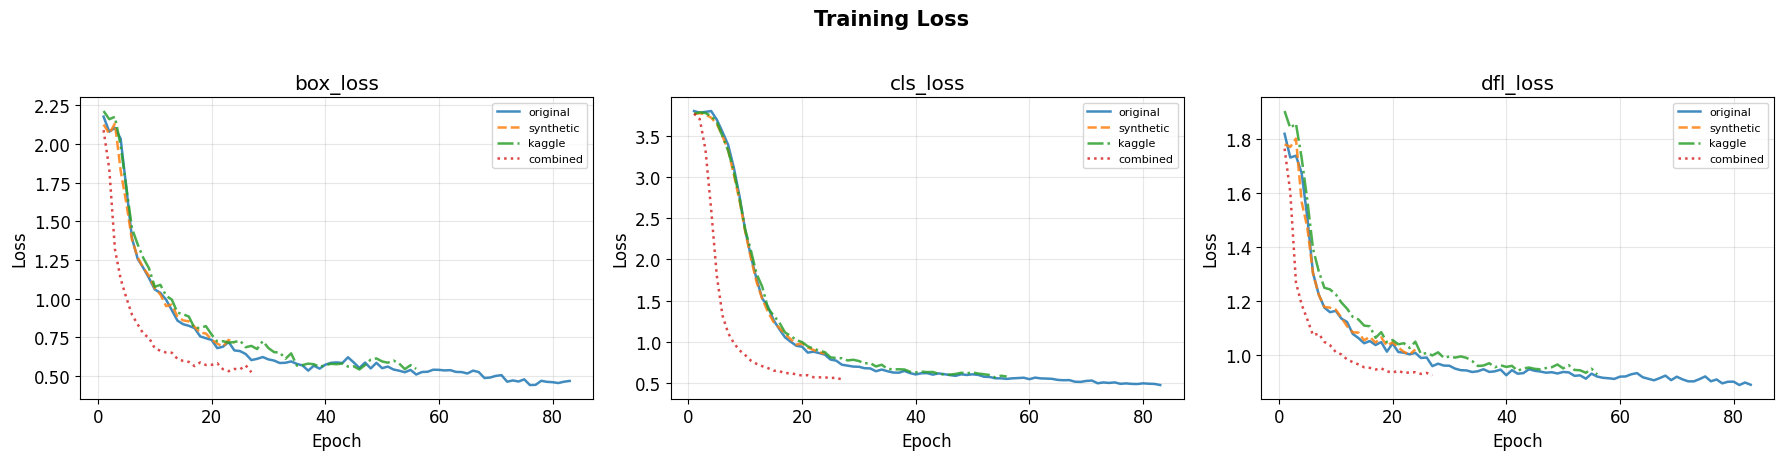

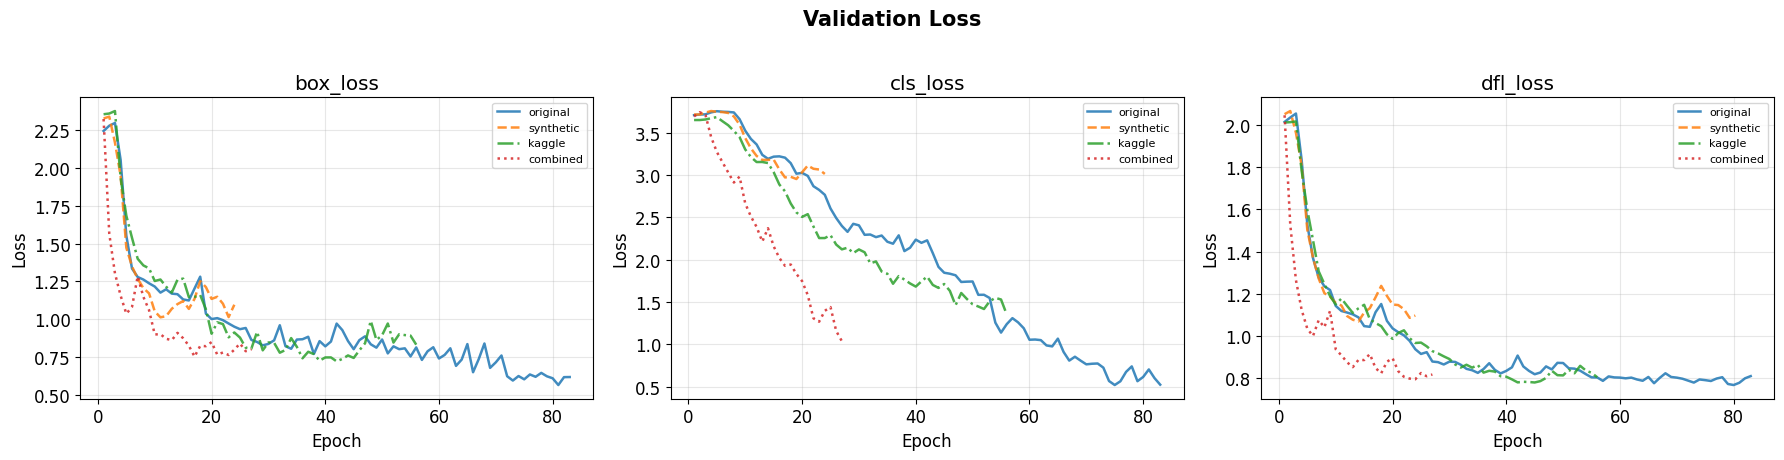

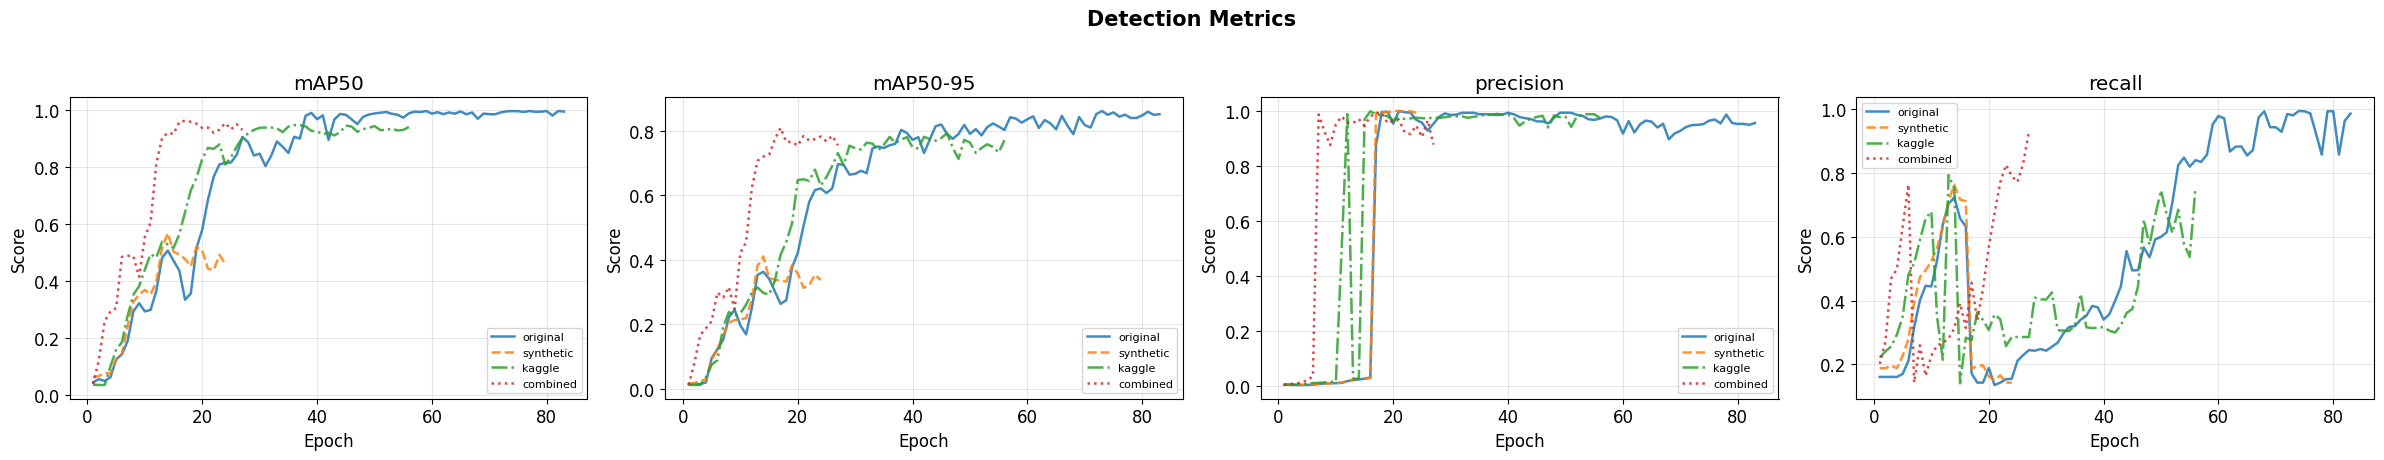

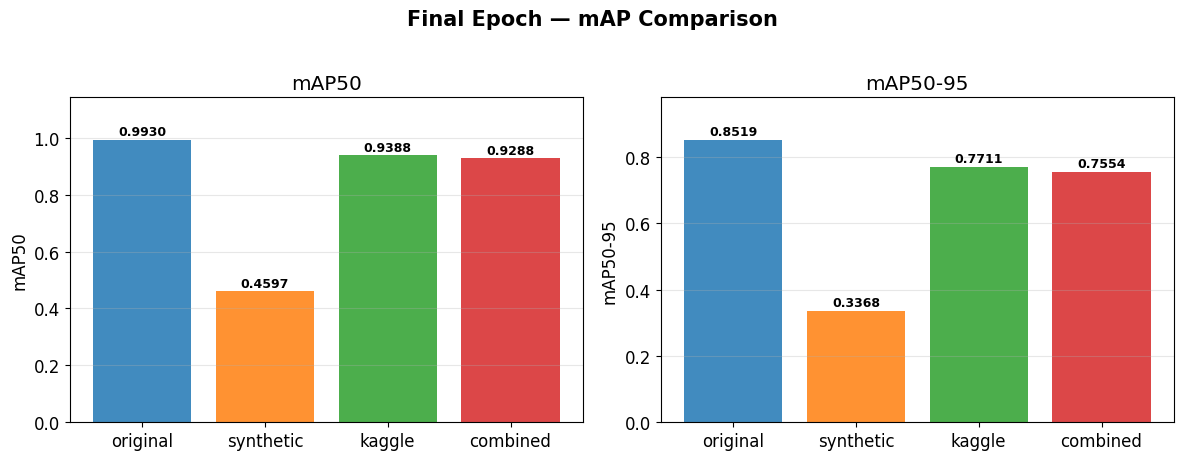


=== Epochs Trained per Dataset ===
  original    :  83 epochs | best mAP50 = 0.9950 @ epoch 59
  synthetic   :  24 epochs | best mAP50 = 0.5663 @ epoch 14
  kaggle      :  56 epochs | best mAP50 = 0.9455 @ epoch 36
  combined    :  27 epochs | best mAP50 = 0.9607 @ epoch 17


In [ ]:
# ============================================================
# Epoch Comparison Graphs — Training Metrics per Dataset
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_results_csv(name):
    """Locate the results.csv for a trained model run."""
    candidates = [
        Path(f"runs/train_{name}/results.csv"),
        Path(f"runs/detect/train_{name}/results.csv"),
        Path(f"runs/detect/runs/train_{name}/results.csv"),
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

# Collect all available training results
results_data = {}
for name in training_configs:
    csv_path = find_results_csv(name)
    if csv_path:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()  # YOLO pads column names with spaces
        results_data[name] = df
        print(f"  Loaded {name}: {len(df)} epochs from {csv_path}")
    else:
        print(f"  [SKIP] {name}: no results.csv found")

if not results_data:
    print("\nNo training results to plot.")
else:
    # Define metrics to plot (grouped into subplots)
    metric_groups = [
        {
            "title": "Training Loss",
            "metrics": ["train/box_loss", "train/cls_loss", "train/dfl_loss"],
            "ylabel": "Loss",
        },
        {
            "title": "Validation Loss",
            "metrics": ["val/box_loss", "val/cls_loss", "val/dfl_loss"],
            "ylabel": "Loss",
        },
        {
            "title": "Detection Metrics",
            "metrics": ["metrics/mAP50(B)", "metrics/mAP50-95(B)", "metrics/precision(B)", "metrics/recall(B)"],
            "ylabel": "Score",
        },
    ]

    colors = {"original": "#1f77b4", "synthetic": "#ff7f0e", "kaggle": "#2ca02c", "combined": "#d62728"}
    line_styles = {"original": "-", "synthetic": "--", "kaggle": "-.", "combined": ":"}

    for group in metric_groups:
        n_metrics = len(group["metrics"])
        fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 4.5), squeeze=False)
        axes = axes[0]
        fig.suptitle(group["title"], fontsize=15, fontweight="bold", y=1.02)

        for i, metric in enumerate(group["metrics"]):
            ax = axes[i]
            for name, df in results_data.items():
                if metric in df.columns:
                    ax.plot(
                        df["epoch"], df[metric],
                        label=name,
                        color=colors.get(name, "gray"),
                        linestyle=line_styles.get(name, "-"),
                        linewidth=1.8, alpha=0.85,
                    )
            ax.set_xlabel("Epoch")
            ax.set_ylabel(group["ylabel"])
            short_name = metric.split("/")[-1].replace("(B)", "")
            ax.set_title(short_name)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()

    # --- Summary comparison bar chart: final mAP50 and mAP50-95 per dataset ---
    summary_metrics = ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]
    available = [m for m in summary_metrics if all(m in df.columns for df in results_data.values())]

    if available:
        fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4.5), squeeze=False)
        axes = axes[0]
        fig.suptitle("Final Epoch — mAP Comparison", fontsize=15, fontweight="bold", y=1.02)

        for i, metric in enumerate(available):
            ax = axes[i]
            names = list(results_data.keys())
            final_vals = [results_data[n][metric].iloc[-1] for n in names]
            bars = ax.bar(names, final_vals, color=[colors.get(n, "gray") for n in names], alpha=0.85)
            ax.set_ylabel(metric.split("/")[-1].replace("(B)", ""))
            ax.set_title(metric.split("/")[-1].replace("(B)", ""))
            ax.set_ylim(0, max(max(final_vals) * 1.15, 0.1))
            for bar, val in zip(bars, final_vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
            ax.grid(True, alpha=0.3, axis="y")

        fig.tight_layout()
        plt.show()

    # --- Epochs trained per dataset ---
    print("\n=== Epochs Trained per Dataset ===")
    for name, df in results_data.items():
        best_map50 = df["metrics/mAP50(B)"].max() if "metrics/mAP50(B)" in df.columns else float("nan")
        best_epoch = df["metrics/mAP50(B)"].idxmax() + 1 if "metrics/mAP50(B)" in df.columns else "?"
        print(f"  {name:12s}: {len(df):3d} epochs | best mAP50 = {best_map50:.4f} @ epoch {best_epoch}")

---
## 4. Stage 2: OCR (stage2_ocr.py)

Layout detection + OCR for labels, ticks, title, legend.

In [ ]:
# ============================================================
# stage2_ocr.py — OCR Pipeline
# ============================================================

# Initialize EasyOCR reader (global, loaded once)
# Use GPU acceleration if CUDA is available
import torch
ocr_reader = easyocr.Reader(["en"], gpu=torch.cuda.is_available())

CLASS_NAMES = {
    0: "plot_area", 1: "legend", 2: "x_label", 3: "y_label",
    4: "x_ticks", 5: "y_ticks", 6: "title"
}


def clamp_box(x1, y1, x2, y2, W, H, pad=10):
    return max(0, int(x1 - pad)), max(0, int(y1 - pad)), min(W, int(x2 + pad)), min(H, int(y2 + pad))


def valid_crop(x1, y1, x2, y2, min_size=4):
    """Check if crop coordinates produce a valid (non-degenerate) region."""
    return (x2 - x1) >= min_size and (y2 - y1) >= min_size


def dedupe_close(nums, tol=1.5):
    nums = sorted(nums)
    out = []
    for n in nums:
        if not out or abs(n - out[-1]) > tol:
            out.append(n)
    return out


def maybe_rotate_vertical(pil_img):
    w, h = pil_img.size
    if h > w:
        return pil_img.rotate(-90, expand=True)
    return pil_img


def filter_by_spacing(ticks, tolerance=0.35):
    if len(ticks) < 3:
        return ticks
    ticks = sorted(ticks)
    diffs = np.diff(ticks)
    median_step = np.median(diffs)
    cleaned = [ticks[0]]
    for t in ticks[1:]:
        if abs((t - cleaned[-1]) - median_step) < median_step * tolerance:
            cleaned.append(t)
    return cleaned


def clean_label(text):
    lower = text.lower()
    if re.search(r'\bsin\b', lower): return "sin(x)"
    if re.search(r'\bcos\b', lower): return "cos(x)"
    if re.search(r'\btan\b', lower): return "tan(x)"
    if re.search(r'\blog\b', lower): return "log(x)"
    if re.search(r'\bexp\b', lower): return "exp(x)"

    corrections = {
        "Betwen": "Between", "Betweem": "Between", "Enupion": "Eruption",
        "Enuption": "Eruption", "Eruptlons": "Eruptions", "Etupilons": "Eruptions",
        "Falthful": "Faithful", "Falhful": "Faithful", "Hln": "Min", "lnj": "Min",
        "MlN": "Min", "BetwenEruptions": "Between Eruptions",
        "Wlaling": "Waiting", "Tine": "Time", "Duratilon": "Duration",
        "Velocitv": "Velocity", "Velocily": "Velocity", "Powerer": "Power",
        "Distarce": "Distance", "Acceleraion": "Acceleration"
    }
    for wrong, right in corrections.items():
        text = text.replace(wrong, right)

    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    text = re.sub(r'(.)\1{1,}', r'\1', text)
    text = text.replace("))", ")").replace("((", "(")
    text = " ".join(text.split())

    KNOWN_LABELS = [
        "Time (s)", "Time (ms)", "Time (min)", "Samples", "Distance (m)", "Position (m)",
        "Displacement (m)", "Velocity", "Velocity (m/s)", "Speed (m/s)", "Acceleration (m/s^2)",
        "Amplitude", "Signal", "Signal Amplitude", "Frequency (Hz)", "Frequency (kHz)", "Phase",
        "Voltage (V)", "Current (A)", "Resistance (Ohm)", "Power (W)", "Energy (J)", "Force (N)",
        "Mass (kg)", "Pressure (kPa)", "Temperature (C)", "Wavelength (nm)", "Wavelength (um)",
        "Intensity", "Input", "Output", "Response", "Measurement", "Value", "Sample Data",
        "sin(x)", "cos(x)", "tan(x)", "exp(x)", "log(x)", "ln(x)", "x^2", "x^3",
        "Polynomial", "Linear", "Quadratic", "Cubic", "Model Output", "Prediction",
        "Ground Truth", "Error", "Eruptions",
    ]
    match = get_close_matches(text, KNOWN_LABELS, n=1, cutoff=0.6)
    if match:
        text = match[0]
    return text.strip()


def preprocess_ticks(pil_img):
    img = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Guard against zero-size images
    if gray.shape[0] < 2 or gray.shape[1] < 2:
        return gray
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    gray = cv2.equalizeHist(gray)
    gray = cv2.fastNlMeansDenoising(gray, None, 10, 7, 21)
    gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 3)
    return gray


def preprocess_label(pil_img):
    img = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if gray.shape[0] < 2 or gray.shape[1] < 2:
        return gray
    gray = cv2.resize(gray, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    return gray


def preprocess_legend(pil_img):
    img = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if gray.shape[0] < 2 or gray.shape[1] < 2:
        return gray
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    return gray


def regularize_ticks(ticks):
    if len(ticks) < 3:
        return ticks
    ticks = sorted(ticks)
    diffs = np.diff(ticks)
    step = np.median(diffs)
    if step == 0:
        return ticks
    start = ticks[0]; end = ticks[-1]
    fixed = []
    v = start
    while v <= end + step * 0.5:
        fixed.append(round(v, 2))
        v += step
    return fixed


def enforce_zero_tick(ticks):
    if not ticks:
        return ticks
    has_neg = any(t < 0 for t in ticks)
    has_pos = any(t > 0 for t in ticks)
    if has_neg and has_pos and 0.0 not in ticks:
        ticks.append(0.0)
    return sorted(ticks)


def remove_outlier_ticks(ticks):
    if len(ticks) < 4:
        return ticks
    ticks = sorted(ticks)
    diffs = np.diff(ticks)
    median_step = np.median(diffs)
    cleaned = [ticks[0]]
    for t in ticks[1:]:
        if abs(t - cleaned[-1] - median_step) < median_step * 0.4:
            cleaned.append(t)
    return cleaned


def ocr_label(pil_img):
    img = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if gray.shape[0] < 2 or gray.shape[1] < 2:
        return ""
    gray = cv2.resize(gray, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)
    gray = cv2.equalizeHist(gray)
    gray = cv2.fastNlMeansDenoising(gray, None, 12, 7, 21)
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    gray = cv2.filter2D(gray, -1, kernel)
    results = ocr_reader.readtext(
        gray, detail=0, paragraph=True,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789() /-"
    )
    return " ".join(results).strip()


def ocr_legend(pil_img):
    img = preprocess_legend(pil_img)
    results = ocr_reader.readtext(
        img, detail=1,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789 ",
        paragraph=False
    )
    rows = []
    for (bbox, text, conf) in results:
        if conf < 0.4:
            continue
        pts = np.array(bbox)
        y_center = pts[:, 1].mean()
        rows.append((y_center, text.strip()))
    rows.sort(key=lambda x: x[0])

    labels = []
    for _, text in rows:
        m = re.search(r"Line\s*\d+", text)
        labels.append(m.group() if m else text)

    seen = set()
    clean = []
    for l in labels:
        if l not in seen:
            clean.append(l)
            seen.add(l)
    return clean


def ocr_ticks_sorted(pil_img, axis="y", mode="easyocr"):
    if isinstance(pil_img, Image.Image):
        # Check for degenerate crop
        if pil_img.size[0] < 4 or pil_img.size[1] < 4:
            return []
        img = preprocess_ticks(pil_img)
    else:
        img = pil_img

    if mode == "easyocr":
        results = ocr_reader.readtext(
            img, detail=1, allowlist="0123456789.-", paragraph=False,
            text_threshold=0.4, low_text=0.2, link_threshold=0.3
        )
        values = []
        for (bbox, text, conf) in results:
            if conf < 0.35:
                continue
            nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", text)
            if not nums:
                continue
            pts = np.array(bbox)
            pos = pts[:, 0].mean() if axis == "x" else pts[:, 1].mean()
            values.append((pos, float(nums[0])))
        values.sort(key=lambda x: x[0])
        return dedupe_close([v[1] for v in values], tol=0.2)

    # MODE B: contour splitting (for y_ticks)
    bin_img = cv2.bitwise_not(img)
    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    components = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if h > 12 and w > 3:
            components.append((x, y, w, h))

    if axis == "y":
        components.sort(key=lambda b: b[1])
    else:
        components.sort(key=lambda b: b[0])

    boxes = []
    current = None
    GAP_Y = 35; GAP_X = 25

    for (x, y, w, h) in components:
        if current is None:
            current = [x, y, x + w, y + h]
            continue
        if axis == "y":
            gap = y - current[3]
            if gap <= GAP_Y:
                current[0] = min(current[0], x); current[1] = min(current[1], y)
                current[2] = max(current[2], x + w); current[3] = max(current[3], y + h)
            else:
                boxes.append(tuple(current))
                current = [x, y, x + w, y + h]
        else:
            gap = x - current[2]
            if gap <= GAP_X:
                current[0] = min(current[0], x); current[1] = min(current[1], y)
                current[2] = max(current[2], x + w); current[3] = max(current[3], y + h)
            else:
                boxes.append(tuple(current))
                current = [x, y, x + w, y + h]

    if current is not None:
        boxes.append(tuple(current))

    values = []
    for (x1, y1, x2, y2) in boxes:
        crop = bin_img[y1:y2, x1:x2]
        crop = cv2.copyMakeBorder(crop, 8, 8, 8, 8, cv2.BORDER_CONSTANT, value=0)
        txt = ocr_reader.readtext(crop, detail=0, allowlist="0123456789.-")
        if not txt:
            continue
        nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", txt[0])
        if nums:
            values.append(float(nums[0]))

    values = sorted(values)
    if len(values) >= 3:
        step = np.median(np.diff(values))
        min_val = values[0]
        if min_val == 0 and step > 0:
            values = [min_val - step] + values

    return dedupe_close(values, tol=0.2)


def detect_layout(model, img_path, conf=0.15):
    """Run YOLO detection on an image (with verbose=False and FP16 if GPU available).
    
    Args:
        conf: Confidence threshold. Lower values detect more objects (default: 0.15).
    """
    use_half = torch.cuda.is_available()
    res = model(img_path, verbose=False, half=use_half, conf=conf)[0]
    boxes = {}
    for b in res.boxes:
        cls = int(b.cls.item())
        name = CLASS_NAMES.get(cls, f"class_{cls}")
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        if name not in boxes:
            boxes[name] = []
        boxes[name].append((x1, y1, x2, y2))
    return boxes

def stage2(img_path, model=None, boxes=None):
    """Full Stage 2 OCR pipeline.
    
    Args:
        boxes: Pre-computed detect_layout() result to avoid redundant YOLO inference.
    """
    if model is None:
        model = YOLO("best.pt")

    img = Image.open(img_path).convert("RGB")
    W, H = img.size

    if boxes is None:
        boxes = detect_layout(model, img_path)
    plot_box_list = boxes.get("plot_area", None)
    if plot_box_list:
        xs1 = [b[0] for b in plot_box_list]; ys1 = [b[1] for b in plot_box_list]
        xs2 = [b[2] for b in plot_box_list]; ys2 = [b[3] for b in plot_box_list]
        plot_box = (min(xs1), min(ys1), max(xs2), max(ys2))
    else:
        plot_box = None

    final_boxes = {}
    crops = {}
    for name, box_list in boxes.items():
        if name in ["x_ticks", "y_ticks"] and isinstance(box_list, list):
            xs1 = [b[0] for b in box_list]; ys1 = [b[1] for b in box_list]
            xs2 = [b[2] for b in box_list]; ys2 = [b[3] for b in box_list]
            box = (min(xs1), min(ys1), max(xs2), max(ys2))
        else:
            box = box_list[0]
        x1, y1, x2, y2 = box

        if name == "y_ticks":
            # Guard: only shrink if box is large enough
            box_h = y2 - y1
            if box_h > 30:
                y2 -= 10
            x1 += int((x2 - x1) * 0.35)
            x1 -= 6; y1 -= 6; x2 += 6; y2 += 6
            x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, W, H, pad=2)
        elif name == "y_label":
            if plot_box is not None:
                _, py1, _, py2 = plot_box
                y1 = py1 - 10; y2 = py2 + 10
            x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, W, H, pad=8)
        elif name == "title":
            y1 -= int((y2 - y1) * 0.8); y2 += 10; x1 -= 10; x2 += 10
            x1 -= 15; x2 += 15; y1 -= 5; y2 += 5
        elif name == "x_label":
            x1, y1, x2, y2 = clamp_box(x1, y1 + 8, x2, y2, W, H, pad=4)
        elif name == "x_ticks":
            x1 -= 15; x2 += 15; y1 -= 5; y2 += 5
            x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, W, H, pad=4)
        elif name == "legend":
            x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, W, H, pad=4)
        else:
            x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, W, H, pad=6)

        # Skip crops that are too small (degenerate detections)
        if not valid_crop(x1, y1, x2, y2, min_size=4):
            continue
        final_boxes[name] = (x1, y1, x2, y2)
        crops[name] = img.crop((x1, y1, x2, y2))

    results = {}

    # Label OCR — each with its own try/except so one failure doesn't kill everything
    try:
        if "y_label" in crops:
            y_img = maybe_rotate_vertical(crops["y_label"])
            results["y_label"] = clean_label(ocr_label(y_img))
        else:
            results["y_label"] = ""
    except Exception:
        results["y_label"] = ""

    try:
        results["x_label"] = clean_label(ocr_label(crops["x_label"])) if "x_label" in crops else ""
    except Exception:
        results["x_label"] = ""

    try:
        results["title"] = clean_label(ocr_label(crops["title"])) if "title" in crops else ""
    except Exception:
        results["title"] = ""

    # X Ticks
    try:
        results["x_ticks"] = ocr_ticks_sorted(crops["x_ticks"], axis="x", mode="easyocr") if "x_ticks" in crops else []
    except Exception:
        results["x_ticks"] = []

    # Y Ticks
    try:
        results["y_ticks"] = ocr_ticks_sorted(crops["y_ticks"], axis="y", mode="contours") if "y_ticks" in crops else []
    except Exception:
        results["y_ticks"] = []

    # Legend
    try:
        if "legend" in crops:
            labels = ocr_legend(crops["legend"])
            line_nums = []
            for l in labels:
                m = re.search(r"Line\s*(\d+)", l)
                if m:
                    line_nums.append(int(m.group(1)))
            if len(line_nums) >= 2:
                min_n = min(line_nums); max_n = max(line_nums)
                labels = [f"Line {i}" for i in range(min_n, max_n + 1)]
            results["legend_labels"] = labels
        else:
            results["legend_labels"] = []
    except Exception:
        results["legend_labels"] = []

    return results

print("Stage 2 OCR pipeline loaded.")

Stage 2 OCR pipeline loaded.


---
## 5. Stage 3: Curve Segmentation (stage3_segment.py)

In [ ]:
# ============================================================
# stage3_segment.py — Curve Segmentation (FIXED)
# ============================================================

def load_curve_masks(img_path, curve_mask_dir):
    """Load pre-generated curve masks for a given image."""
    stem = Path(img_path).stem
    masks = []
    mask_dir = Path(curve_mask_dir)
    for m in sorted(mask_dir.glob(f"{stem}_curve_*.png")):
        mask = cv2.imread(str(m), cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            masks.append(mask)
    return masks


def segment_by_color(plot_img, max_curves=6, min_pixels=300):
    """Fallback: segment curves by color in the plot area.
    
    Improvements over original:
    - Filter out near-gray pixels (gridlines, axes, text)
    - Filter out near-white and near-black pixels (background, borders)
    - Use morphological operations to clean up small noise
    - Cap maximum number of curves
    - Sort by pixel count and keep only the most prominent
    """
    img = np.array(plot_img)
    H, W, _ = img.shape

    # Convert to float for calculations
    r, g, b = img[:,:,0].astype(float), img[:,:,1].astype(float), img[:,:,2].astype(float)
    
    # Filter out near-gray pixels (gridlines, axes, text) — where R≈G≈B
    max_ch = np.maximum(np.maximum(r, g), b)
    min_ch = np.minimum(np.minimum(r, g), b)
    saturation = max_ch - min_ch  # chroma
    
    # Also filter near-white (brightness > 230) and near-black (brightness < 30)
    brightness = (r + g + b) / 3.0
    
    # A pixel is a "curve pixel" if it has enough color saturation
    # and isn't too bright (white background) or too dark (black text/axes)
    color_mask = (saturation > 30) & (brightness > 25) & (brightness < 235)
    
    ys, xs = np.where(color_mask)
    if len(ys) < min_pixels:
        return []

    pixels = img[ys, xs]
    # Quantize to 40-bin (slightly finer than 32 to separate close colors)
    quantized = (pixels // 40) * 40
    uniq = np.unique(quantized, axis=0)

    # Build components and track their pixel count
    raw_components = []
    for c in uniq:
        sel = np.all(quantized == c, axis=1)
        count = np.sum(sel)
        if count < min_pixels:
            continue
        cmask = np.zeros((H, W), np.uint8)
        cmask[ys[sel], xs[sel]] = 255
        
        # Morphological cleanup: close small gaps, remove tiny isolated blobs
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        cmask = cv2.morphologyEx(cmask, cv2.MORPH_CLOSE, kernel)
        cmask = cv2.morphologyEx(cmask, cv2.MORPH_OPEN, kernel)
        
        # Re-count after cleanup
        final_count = np.sum(cmask > 0)
        if final_count < min_pixels:
            continue
        raw_components.append((final_count, cmask))

    # Sort by pixel count (most prominent first) and cap
    raw_components.sort(key=lambda x: x[0], reverse=True)
    components = [mask for _, mask in raw_components[:max_curves]]

    return components


def stage3(img_path, model, curve_mask_dir="output/curve_masks", boxes=None):
    """Stage 3: Detect and segment curves.
    
    FIX: When using color segmentation fallback, the masks are returned
    at plot_crop size (H_crop, W_crop). We now pad them back to full 
    image size so that stage4's comp[y1:y2, x1:x2] crop works correctly.
    
    Args:
        boxes: Pre-computed detect_layout() result to avoid redundant YOLO inference.
    """
    img = Image.open(img_path).convert("RGB")
    W, H = img.size

    if boxes is None:
        boxes = detect_layout(model, img_path)
    if "plot_area" not in boxes:
        raise RuntimeError("plot_area not detected")

    plot_boxes = boxes["plot_area"]
    if isinstance(plot_boxes, list):
        xs1 = [b[0] for b in plot_boxes]; ys1 = [b[1] for b in plot_boxes]
        xs2 = [b[2] for b in plot_boxes]; ys2 = [b[3] for b in plot_boxes]
        plot_box = (min(xs1), min(ys1), max(xs2), max(ys2))
    else:
        plot_box = plot_boxes

    x1, y1, x2, y2 = clamp_box(*plot_box, W, H)
    plot_crop = img.crop((x1, y1, x2, y2))

    # Primary: load generator masks (these are already full-image-sized)
    components = load_curve_masks(img_path, curve_mask_dir)

    # Fallback: color segmentation on plot crop
    if len(components) == 0:
        crop_masks = segment_by_color(plot_crop)
        # CRITICAL FIX: Pad crop-sized masks back to full image size
        # so stage4's comp[y1:y2, x1:x2] produces the correct crop
        for sm in crop_masks:
            full_mask = np.zeros((H, W), np.uint8)
            full_mask[y1:y2, x1:x2] = sm
            components.append(full_mask)


    print(f"Stage3 curves detected: {len(components)}")

    return components

---
## 6. Semantic Analysis (semantic_analysis.py)

In [ ]:
# ============================================================
# semantic_analysis.py — Curve Analysis (IMPROVED)
# ============================================================

def smooth_signal(y):
    if len(y) < 15:
        return y
    return savgol_filter(y, 11, 3)


def detect_trend(x, y):
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    slope = model.coef_[0]
    if slope > 0.01:
        return "increasing", slope
    elif slope < -0.01:
        return "decreasing", slope
    else:
        return "flat", slope


def detect_periodicity(x, y):
    if len(y) < 10:
        return None, None
    ys = smooth_signal(y)
    distance = max(1, len(ys) // 10)
    peaks, _ = find_peaks(ys, distance=distance)
    if len(peaks) < 2:
        return None, None
    periods = np.diff(x[peaks])
    avg_period = np.mean(periods)
    if avg_period <= 0:
        return None, None
    frequency = 1.0 / avg_period
    return avg_period, frequency


def is_sine_like(x, y):
    """Detect if the curve is sine-like / oscillatory.
    
    IMPROVED: Relaxed thresholds:
    - Requires only 2 peaks and 2 troughs (was 3)
    - Lower prominence threshold (0.2 * std, was 0.3)
    - Requires only 3 zero crossings (was 4)
    - Added autocorrelation-based fallback detection
    """
    ys = smooth_signal(y)
    std = np.std(ys)
    if std < 1e-6:
        return False
    
    # Primary: peak/trough detection
    peaks, _ = find_peaks(ys, prominence=std * 0.2)
    troughs, _ = find_peaks(-ys, prominence=std * 0.2)
    
    if len(peaks) >= 2 and len(troughs) >= 2:
        # Check even spacing of peaks
        peak_dist = np.diff(x[peaks])
        if len(peak_dist) > 0 and np.mean(peak_dist) > 0:
            if np.std(peak_dist) <= 0.4 * np.mean(peak_dist):
                # Check zero crossings
                mean_y = np.mean(ys)
                zero_crossings = np.where(np.diff(np.sign(ys - mean_y)))[0]
                if len(zero_crossings) >= 3:
                    return True
    
    # Fallback: autocorrelation-based detection
    if len(ys) >= 20:
        ys_centered = ys - np.mean(ys)
        norm = np.sum(ys_centered ** 2)
        if norm > 1e-6:
            autocorr = np.correlate(ys_centered, ys_centered, mode='full')
            autocorr = autocorr[len(autocorr) // 2:] / norm
            # Look for secondary peak in autocorrelation (periodicity indicator)
            if len(autocorr) > 10:
                ac_peaks, props = find_peaks(autocorr[1:], height=0.3, distance=len(autocorr)//10)
                if len(ac_peaks) >= 1:
                    return True
    
    return False


def analyze_curve(curve):
    """Analyze a single reconstructed curve."""
    x = curve[:, 0]
    y = curve[:, 1]

    trend, slope = detect_trend(x, y)
    period, freq = detect_periodicity(x, y)
    sine_flag = is_sine_like(x, y)

    if not sine_flag:
        period, freq = None, None

    results = {
        "trend": trend,
        "slope": float(slope),
        "period": float(period) if period else None,
        "frequency": float(freq) if freq else None,
        "is_sine_like": sine_flag
    }

    drift_threshold = 0.02
    if sine_flag:
        if abs(slope) > drift_threshold:
            drift_type = "positive drift" if slope > 0 else "negative drift"
            results["interpretation"] = (
                f"Oscillatory signal with {drift_type}, frequency ≈ {freq:.3f}" if freq
                else f"Oscillatory signal with {drift_type}"
            )
        else:
            results["interpretation"] = (
                f"Sine-like signal, frequency ≈ {freq:.3f}" if freq
                else "Sine-like signal"
            )
    elif trend == "increasing":
        results["interpretation"] = "Increasing trend"
    elif trend == "decreasing":
        results["interpretation"] = "Decreasing trend"
    else:
        results["interpretation"] = "No strong pattern detected"

    return results

print("Semantic analysis loaded (IMPROVED).")

Semantic analysis loaded (IMPROVED).


---
## 7. Stage 4: Reconstruction (stage4_reconstruct.py)

In [ ]:
# ============================================================
# stage4_reconstruct.py — Full Reconstruction Pipeline (FIXED)
# ============================================================

def mask_to_trace(mask):
    """Convert a binary mask to an (x, y) trace using column medians."""
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return np.empty((0, 2), dtype=np.float32)
    col_map = {}
    for y, x in zip(ys, xs):
        col_map.setdefault(x, []).append(y)
    x_obs = np.array(sorted(col_map.keys()), dtype=np.float32)
    y_obs = np.array([np.median(col_map[int(x)]) for x in x_obs], dtype=np.float32)
    return np.column_stack([x_obs, y_obs]).astype(np.float32)


def get_axis_ranges_from_meta(meta, img_path=None):
    """Extract axis ranges from stage2 metadata with multiple fallbacks."""
    xt = meta.get("x_ticks", [])
    yt = meta.get("y_ticks", [])
    
    # Best case: 2+ ticks on both axes
    if len(xt) >= 2 and len(yt) >= 2:
        return min(xt), max(xt), min(yt), max(yt)
    
    # Fallback 1: try ground truth JSON
    if img_path:
        stem = Path(img_path).stem
        parent = Path(img_path).parent.parent  # e.g., output/ or kaggle_output/
        gt_file = parent / "ground_truth" / f"{stem}.json"
        if gt_file.exists():
            try:
                with open(gt_file) as f:
                    gt = json.load(f)
                gt_xt = gt.get("x_ticks", [])
                gt_yt = gt.get("y_ticks", [])
                if len(gt_xt) >= 2 and len(gt_yt) >= 2:
                    print(f"  Using ground truth axis ranges (OCR had xt={len(xt)}, yt={len(yt)} ticks)")
                    return min(gt_xt), max(gt_xt), min(gt_yt), max(gt_yt)
            except Exception:
                pass
    
    # Fallback 2: use whatever ticks we have + estimation
    if len(xt) >= 1 and len(yt) >= 1:
        if len(xt) == 1:
            xval = xt[0]
            xt = [xval - abs(xval) * 0.5 if xval != 0 else -5, 
                  xval + abs(xval) * 0.5 if xval != 0 else 5]
        if len(yt) == 1:
            yval = yt[0]
            yt = [yval - abs(yval) * 0.5 if yval != 0 else -5,
                  yval + abs(yval) * 0.5 if yval != 0 else 5]
        return min(xt), max(xt), min(yt), max(yt)
    
    # Fallback 3: if we have any ticks on ONE axis, use 0-100 for other
    if len(xt) >= 2:
        return min(xt), max(xt), 0, 100
    if len(yt) >= 2:
        return 0, 100, min(yt), max(yt)
    
    raise RuntimeError("Axis ranges unavailable")


def stage4(img_path, components, model, meta=None, boxes=None):
    """Stage 4: Reconstruct data from segmented curves.
    
    FIX: Accept pre-computed stage2 metadata to avoid redundant calls.
    FIX: Better axis range estimation with fallbacks.
    
    Args:
        boxes: Pre-computed detect_layout() result to avoid redundant YOLO inference.
    """
    img = Image.open(img_path).convert("RGB")
    W, H = img.size

    if boxes is None:
        boxes = detect_layout(model, img_path)
    if "plot_area" not in boxes:
        raise RuntimeError("plot_area not detected")

    plot_boxes = boxes["plot_area"]
    if isinstance(plot_boxes, list):
        xs1 = [b[0] for b in plot_boxes]; ys1 = [b[1] for b in plot_boxes]
        xs2 = [b[2] for b in plot_boxes]; ys2 = [b[3] for b in plot_boxes]
        plot_box = (min(xs1), min(ys1), max(xs2), max(ys2))
    else:
        plot_box = plot_boxes

    x1, y1, x2, y2 = clamp_box(*plot_box, W, H)
    plot_crop = img.crop((x1, y1, x2, y2))
    crop_w, crop_h = plot_crop.size

    if components is None or len(components) == 0:
        return None

    # FIX: Use pre-computed meta if available, otherwise call stage2 ONCE
    if meta is None:
        meta = stage2(img_path, model=model)
    
    xmin, xmax, ymin, ymax = get_axis_ranges_from_meta(meta, img_path=img_path)

    curves = []
    for comp in components:
        comp_crop = comp[y1:y2, x1:x2]
        trace_px = mask_to_trace(comp_crop)
        if trace_px.shape[0] < 5:
            continue

        data_x = xmin + (trace_px[:, 0] / crop_w) * (xmax - xmin)
        data_y = ymax - (trace_px[:, 1] / crop_h) * (ymax - ymin)
        data_xy = np.column_stack((data_x, data_y)).astype(np.float32)
        curves.append(data_xy)

    legend_labels = meta.get("legend_labels", [])
    if legend_labels:
        curves = sorted(curves, key=lambda c: len(c), reverse=True)
        curves = curves[:len(legend_labels)]

    reconstruction = {
        "title": meta.get("title", ""),
        "x_label": meta.get("x_label", ""),
        "y_label": meta.get("y_label", ""),
        "x_ticks": meta.get("x_ticks", []),
        "y_ticks": meta.get("y_ticks", []),
        "legend": meta.get("legend_labels", []),
        "curves": curves
    }

    print(f"Stage4 reconstructed curves: {len(curves)}")
    return reconstruction


# OPTIMIZED: Single YOLO inference shared across all stages (3x → 1x).
def run_pipeline(img_path, model, curve_mask_dir="output/curve_masks"):
    """Run full pipeline: detect layout once, then stage2 + stage3 + stage4."""
    # Single YOLO inference — reused by stage2, stage3, and stage4
    boxes = detect_layout(model, img_path)
    
    components = stage3(img_path, model, curve_mask_dir=curve_mask_dir, boxes=boxes)
    meta = stage2(img_path, model=model, boxes=boxes)
    result = stage4(img_path, components, model, meta=meta, boxes=boxes)

    if result is None:
        print("No reconstruction available.")
        return None

    curves = result["curves"]

    print("\n===== ANALYSIS =====")
    for i, curve in enumerate(curves):
        analysis = analyze_curve(curve)
        print(f"\nCurve {i}:")
        for k, v in analysis.items():
            print(f"  {k}: {v}")

    return result


def visualize_reconstruction(result):
    """Plot the reconstructed data."""
    if result is None:
        return

    curves = result["curves"]
    legend_labels = result.get("legend", [])

    fig, ax = plt.subplots(figsize=(6, 4))
    for i, curve in enumerate(curves):
        label = legend_labels[i] if i < len(legend_labels) else f"Line {i}"
        ax.plot(curve[:, 0], curve[:, 1], label=label)

    ax.set_title(result["title"] or "Reconstructed Plot")
    ax.set_xlabel(result["x_label"] or "X")
    ax.set_ylabel(result["y_label"] or "Y")

    if result["x_ticks"] and result["y_ticks"]:
        xmin = min(result["x_ticks"]); xmax = max(result["x_ticks"])
        ymin = min(result["y_ticks"]); ymax = max(result["y_ticks"])
        x_pad = 0.05 * (xmax - xmin); y_pad = 0.05 * (ymax - ymin)
        ax.set_xlim(xmin - x_pad, xmax + x_pad)
        ax.set_ylim(ymin - y_pad, ymax + y_pad)
        ax.autoscale(False)
        ax.set_xticks(result["x_ticks"])
        ax.set_yticks(result["y_ticks"])

    if legend_labels:
        ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


print("Stage 4 reconstruction loaded.")

Stage 4 reconstruction loaded.


---
## 8. test.py — Visualization of Ground Truth Boxes

In [ ]:
# ============================================================
# test.py — Visualize ground truth YOLO boxes
# ============================================================

CLASS_COLORS = {
    "plot_area": (0, 255, 0),
    "legend": (0, 0, 255),
    "x_label": (255, 0, 0),
    "y_label": (0, 255, 255),
    "x_ticks": (255, 255, 0),
    "y_ticks": (255, 0, 255),
    "title": (255, 128, 0)
}


def draw_yolo_box(img, bbox, color, label):
    h, w = img.shape[:2]
    xc, yc, bw, bh = bbox
    x1 = int((xc - bw/2) * w)
    y1 = int((yc - bh/2) * h)
    x2 = int((xc + bw/2) * w)
    y2 = int((yc + bh/2) * h)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, label, (x1 + 5, y1 + 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)


def visualize_gt_boxes(img_dir, gt_dir, n=5):
    """Visualize ground truth bounding boxes on images."""
    img_dir = Path(img_dir)
    gt_dir = Path(gt_dir)
    
    fig, axes = plt.subplots(1, min(n, 5), figsize=(20, 4))
    if n == 1:
        axes = [axes]
    
    for idx, gt_file in enumerate(sorted(gt_dir.glob("*.json"))[:n]):
        with open(gt_file) as f:
            gt = json.load(f)

        if "boxes_yolo" not in gt:
            continue

        img_path = img_dir / gt["image"]
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        boxes = gt["boxes_yolo"]
        for name, color in CLASS_COLORS.items():
            if name in boxes and boxes[name] is not None:
                draw_yolo_box(img, boxes[name], color, name)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if idx < len(axes):
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(gt["image"], fontsize=8)
            axes[idx].axis("off")

    plt.suptitle(f"Ground Truth Boxes ({img_dir.parent.name})", fontsize=12)
    plt.tight_layout()
    plt.show()

print("Visualization tools loaded.")

Visualization tools loaded.


### Visualize GT boxes for each dataset


--- Original Dataset ---


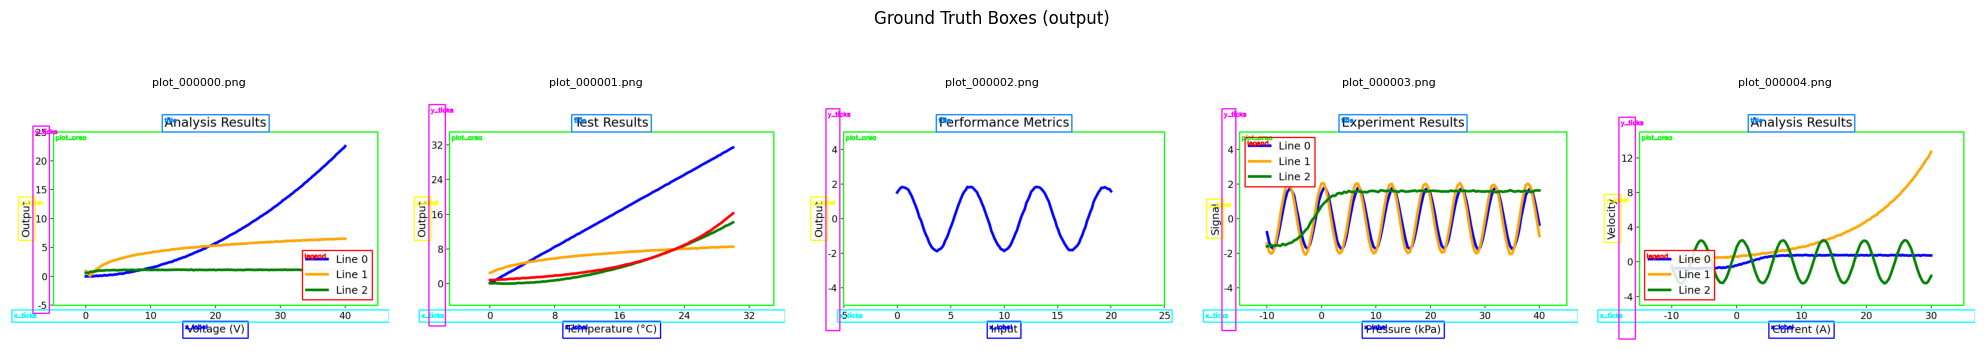


--- Synthetic Dataset ---


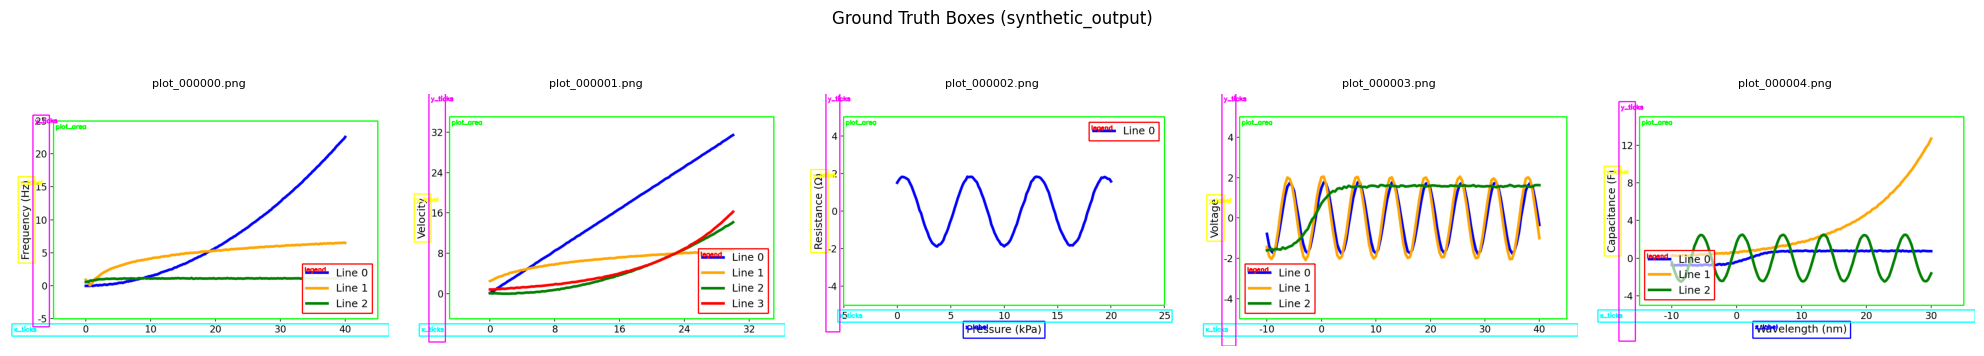


--- Kaggle Dataset ---


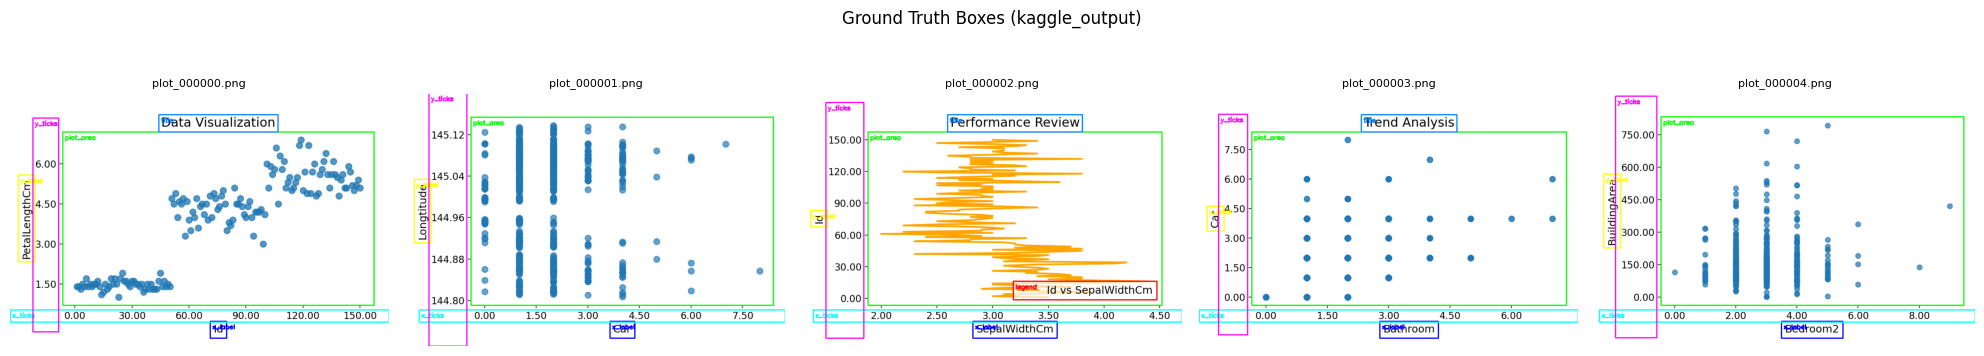

In [ ]:
# Visualize ground truth boxes for all 3 datasets
for name, folder in [("Original", "output"), ("Synthetic", "synthetic_output"), ("Kaggle", "kaggle_output")]:
    print(f"\n--- {name} Dataset ---")
    visualize_gt_boxes(f"{folder}/images", f"{folder}/ground_truth", n=5)

---
## 9. Batch OCR Testing (batch_stage2_test.py)

Run Stage 2 OCR on every image in each dataset and collect metrics.

In [ ]:
# ============================================================
# batch_stage2_test.py — Batch OCR evaluation
# ============================================================

def batch_ocr_test(img_dir, model, dataset_name="dataset", max_images=None):
    """Run Stage 2 OCR on all images in a directory and report stats."""
    img_dir = Path(img_dir)
    images = sorted(img_dir.glob("*.png"))
    if max_images:
        images = images[:max_images]

    results = []
    failures = []
    errors = []  # Track exception errors separately
    x_ticks_ok = y_ticks_ok = x_label_ok = y_label_ok = 0

    print(f"Running OCR on {len(images)} images from {dataset_name}...")

    for i, img_path in enumerate(images, 1):
        try:
            result = stage2(str(img_path), model=model)
            record = {"image": img_path.name, "result": result}
            problems = []

            if len(result["x_ticks"]) < 2: problems.append("x_ticks_low")
            else: x_ticks_ok += 1
            if len(result["y_ticks"]) < 2: problems.append("y_ticks_low")
            else: y_ticks_ok += 1
            if result["x_label"] == "": problems.append("missing_x_label")
            else: x_label_ok += 1
            if result["y_label"] == "": problems.append("missing_y_label")
            else: y_label_ok += 1

            record["problems"] = problems
            if problems:
                failures.append(record)
            results.append(record)

            if i % 10 == 0:
                print(f"  [{i}/{len(images)}] processed")

        except Exception as e:
            print(f"  [ERROR] {img_path.name}: {type(e).__name__}: {e}")
            errors.append({"image": img_path.name, "error": str(e)})
            failures.append({"image": img_path.name, "error": str(e)})

    total = len(images)
    summary = {
        "dataset": dataset_name,
        "total": total,
        "failures": len(failures),
        "errors": len(errors),
        "x_label_pct": x_label_ok / total * 100 if total else 0,
        "y_label_pct": y_label_ok / total * 100 if total else 0,
        "x_ticks_pct": x_ticks_ok / total * 100 if total else 0,
        "y_ticks_pct": y_ticks_ok / total * 100 if total else 0,
    }

    print(f"\n=== {dataset_name} OCR Summary ===")
    print(f"  Total: {total}, Failures: {len(failures)}, Exceptions: {len(errors)}")
    print(f"  x_label: {x_label_ok}/{total} ({summary['x_label_pct']:.1f}%)")
    print(f"  y_label: {y_label_ok}/{total} ({summary['y_label_pct']:.1f}%)")
    print(f"  x_ticks: {x_ticks_ok}/{total} ({summary['x_ticks_pct']:.1f}%)")
    print(f"  y_ticks: {y_ticks_ok}/{total} ({summary['y_ticks_pct']:.1f}%)")

    return summary, results, failures

print("Batch OCR testing loaded.")

Batch OCR testing loaded.


---
## 10. Run Pipeline on Each Dataset

Run the full YOLO + OCR + Segmentation + Reconstruction pipeline on sample images from each dataset.


Pipeline: original (own model)
Using model: runs\detect\runs\train_original\weights\best.pt

--- Processing: plot_000000.png ---
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.9587498307228088
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.20542292296886444
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: flat
  slope: 0.005645920056849718
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected


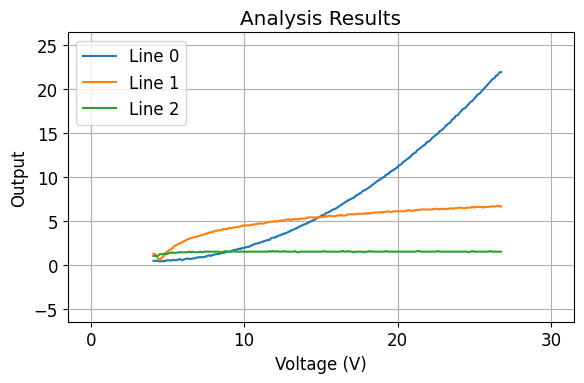


--- Processing: plot_000001.png ---
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.4250197112560272
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.0684572160243988
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 0.1909639686346054
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 0.18383829295635223
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


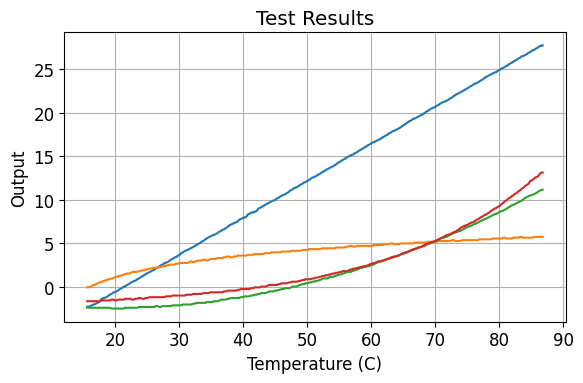


--- Processing: plot_000002.png ---
Stage3 curves detected: 1
Stage4 reconstructed curves: 1

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: 0.0002522566937841475
  period: 4.0201005935668945
  frequency: 0.2487500011920929
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.249


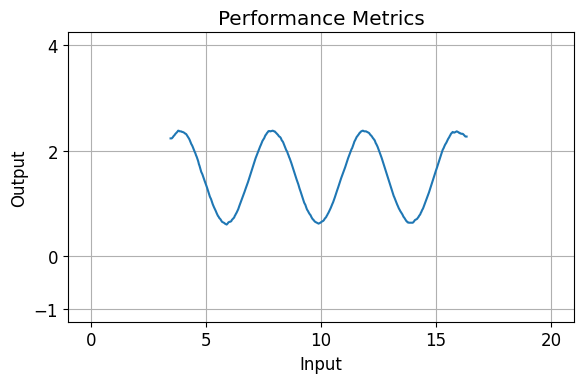


Pipeline: synthetic (own model)
Using model: runs\detect\runs\train_synthetic\weights\best.pt

--- Processing: plot_000000.png ---
  Error: plot_area not detected

--- Processing: plot_000001.png ---
  Error: plot_area not detected

--- Processing: plot_000002.png ---
  Error: plot_area not detected

Pipeline: kaggle (own model)
Using model: runs\detect\runs\train_kaggle\weights\best.pt

--- Processing: plot_000000.png ---
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 1.2628618478775024
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 1.2494314908981323
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 1.254801869392395
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 1.030254483

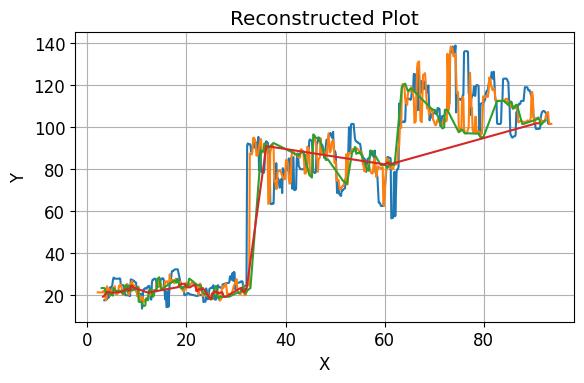


--- Processing: plot_000001.png ---
Stage3 curves detected: 4
  Error: Axis ranges unavailable

--- Processing: plot_000002.png ---
Stage3 curves detected: 2
  Error: Axis ranges unavailable


In [ ]:
# ============================================================
# Run full pipeline on EACH dataset using its OWN trained model
# ============================================================

PIPELINE_CONFIGS = {
    "original": {
        "img_dir": "output/images",
        "curve_mask_dir": "output/curve_masks",
    },
    "synthetic": {
        "img_dir": "synthetic_output/images",
        "curve_mask_dir": "synthetic_output/curve_masks",
    },
    "kaggle": {
        "img_dir": "kaggle_output/images",
        "curve_mask_dir": "kaggle_output/curve_masks",
    },
}

pipeline_results = {}

N_SAMPLES = 3  # Number of sample images to process per dataset

for ds_name, cfg in PIPELINE_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Pipeline: {ds_name} (own model)")
    print(f"{'='*60}")

    model_path = get_model_path(ds_name)
    print(f"Using model: {model_path}")
    model = YOLO(model_path)

    img_dir = Path(cfg["img_dir"])
    sample_imgs = sorted(img_dir.glob("*.png"))[:N_SAMPLES]

    ds_results = []
    for img_path in sample_imgs:
        print(f"\n--- Processing: {img_path.name} ---")
        try:
            result = run_pipeline(str(img_path), model, curve_mask_dir=cfg["curve_mask_dir"])
            if result:
                visualize_reconstruction(result)
                ds_results.append({"image": img_path.name, "result": result})
        except Exception as e:
            print(f"  Error: {e}")

    pipeline_results[ds_name] = ds_results

---
## 11. Cross-Dataset Evaluation: Mix & Match

Train on one dataset, test on another. Compare YOLO detection and OCR quality across mismatched domains.

In [ ]:
# ============================================================
# CROSS-DATASET YOLO EVALUATION
# Train on dataset A, evaluate on dataset B's val set
# ============================================================

EVAL_DATASETS = {
    "original":  "yolo_original",
    "synthetic": "yolo_synthetic",
    "kaggle":    "yolo_kaggle",
}

cross_eval_results = {}

# Cache models to avoid redundant loads
_eval_model_cache = {}

for train_name in ["original", "synthetic", "kaggle", "combined"]:
    model_path = get_model_path(train_name)
    
    if model_path not in _eval_model_cache:
        _eval_model_cache[model_path] = YOLO(model_path)
    model = _eval_model_cache[model_path]
    
    for eval_name, eval_dir in EVAL_DATASETS.items():
        key = f"train={train_name} -> eval={eval_name}"
        print(f"\n{key} (model: {Path(model_path).parent.parent.name})")
        
        # Validate on the eval dataset's val set
        yaml_path = f"{eval_dir}.yaml"
        if not Path(yaml_path).exists():
            print(f"  Skipping — {yaml_path} not found")
            continue
            
        try:
            metrics = model.val(data=yaml_path, verbose=False)
            mAP50 = metrics.box.map50
            mAP50_95 = metrics.box.map
            
            cross_eval_results[key] = {
                "mAP50": float(mAP50),
                "mAP50_95": float(mAP50_95),
            }
            print(f"  mAP@50: {mAP50:.4f}")
            print(f"  mAP@50-95: {mAP50_95:.4f}")
        except Exception as e:
            print(f"  Error: {e}")
            cross_eval_results[key] = {"error": str(e)}

print("\nCross-evaluation complete.")


train=original -> eval=original (model: train_original)
Ultralytics 8.4.14  Python-3.13.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 8.52.0 MB/s, size: 43.0 KB)
val: Scanning C:\Users\yakuz\VSC\Scientific-Plot-Understanding\yolo_original\labels\val.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 7.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2s/it 2.4s7.4s
                   all         20        131       0.95       0.98      0.994      0.862
Speed: 1.7ms preprocess, 11.9ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to C:\Users\yakuz\VSC\Scientific-Plot-Understanding\runs\detect\val45
  mAP@50: 0.9938
  mAP@50-95: 0.8619

train=original -> eval=synthetic (model: train_original)
Ultralytics 8.4.14  Python-3.13.12 torc

### Cross-Dataset Results Table

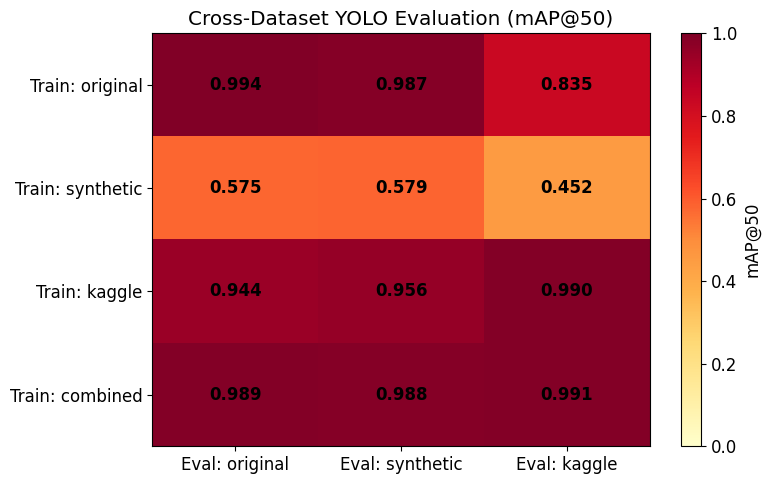

In [ ]:
# ============================================================
# Build comparison table: mAP50 heatmap
# ============================================================

train_sets = ["original", "synthetic", "kaggle", "combined"]
eval_sets  = ["original", "synthetic", "kaggle"]

# Build matrix
matrix = np.zeros((len(train_sets), len(eval_sets)))
for i, tr in enumerate(train_sets):
    for j, ev in enumerate(eval_sets):
        key = f"train={tr} -> eval={ev}"
        if key in cross_eval_results and "mAP50" in cross_eval_results[key]:
            matrix[i, j] = cross_eval_results[key]["mAP50"]
        else:
            matrix[i, j] = np.nan

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(eval_sets)))
ax.set_yticks(range(len(train_sets)))
ax.set_xticklabels([f"Eval: {e}" for e in eval_sets])
ax.set_yticklabels([f"Train: {t}" for t in train_sets])

for i in range(len(train_sets)):
    for j in range(len(eval_sets)):
        val = matrix[i, j]
        text = f"{val:.3f}" if not np.isnan(val) else "N/A"
        ax.text(j, i, text, ha="center", va="center", fontsize=12, fontweight="bold")

plt.colorbar(im, label="mAP@50")
plt.title("Cross-Dataset YOLO Evaluation (mAP@50)")
plt.tight_layout()
plt.show()

---
## 12. Cross-Dataset OCR Comparison

Run OCR using model trained on dataset A on images from dataset B.

In [ ]:
# ============================================================
# CROSS-DATASET OCR COMPARISON
# Use model trained on A, run OCR on images from B
# ============================================================

ocr_cross_results = {}

_ocr_model_cache = {}

for train_name in ["original", "synthetic", "kaggle", "combined"]:
    model_path = get_model_path(train_name)
    
    if model_path not in _ocr_model_cache:
        _ocr_model_cache[model_path] = YOLO(model_path)
    model = _ocr_model_cache[model_path]

    for eval_name in ["original", "synthetic", "kaggle"]:
        key = f"train={train_name} -> ocr={eval_name}"
        print(f"\n{key}")

        img_dirs = {
            "original": "output/images",
            "synthetic": "synthetic_output/images",
            "kaggle": "kaggle_output/images"
        }

        summary, _, _ = batch_ocr_test(
            img_dirs[eval_name], model,
            dataset_name=key,
            max_images=100  # Limit for speed
        )
        ocr_cross_results[key] = summary


train=original -> ocr=original
Running OCR on 100 images from train=original -> ocr=original...
  [10/100] processed
  [20/100] processed
  [30/100] processed
  [40/100] processed
  [50/100] processed
  [60/100] processed
  [70/100] processed
  [80/100] processed
  [90/100] processed
  [100/100] processed

=== train=original -> ocr=original OCR Summary ===
  Total: 100, Failures: 69, Exceptions: 0
  x_label: 100/100 (100.0%)
  y_label: 100/100 (100.0%)
  x_ticks: 32/100 (32.0%)
  y_ticks: 97/100 (97.0%)

train=original -> ocr=synthetic
Running OCR on 100 images from train=original -> ocr=synthetic...
  [10/100] processed
  [20/100] processed
  [30/100] processed
  [40/100] processed
  [50/100] processed
  [60/100] processed
  [70/100] processed
  [80/100] processed
  [90/100] processed
  [100/100] processed

=== train=original -> ocr=synthetic OCR Summary ===
  Total: 100, Failures: 79, Exceptions: 0
  x_label: 86/100 (86.0%)
  y_label: 81/100 (81.0%)
  x_ticks: 38/100 (38.0%)
  y_tic

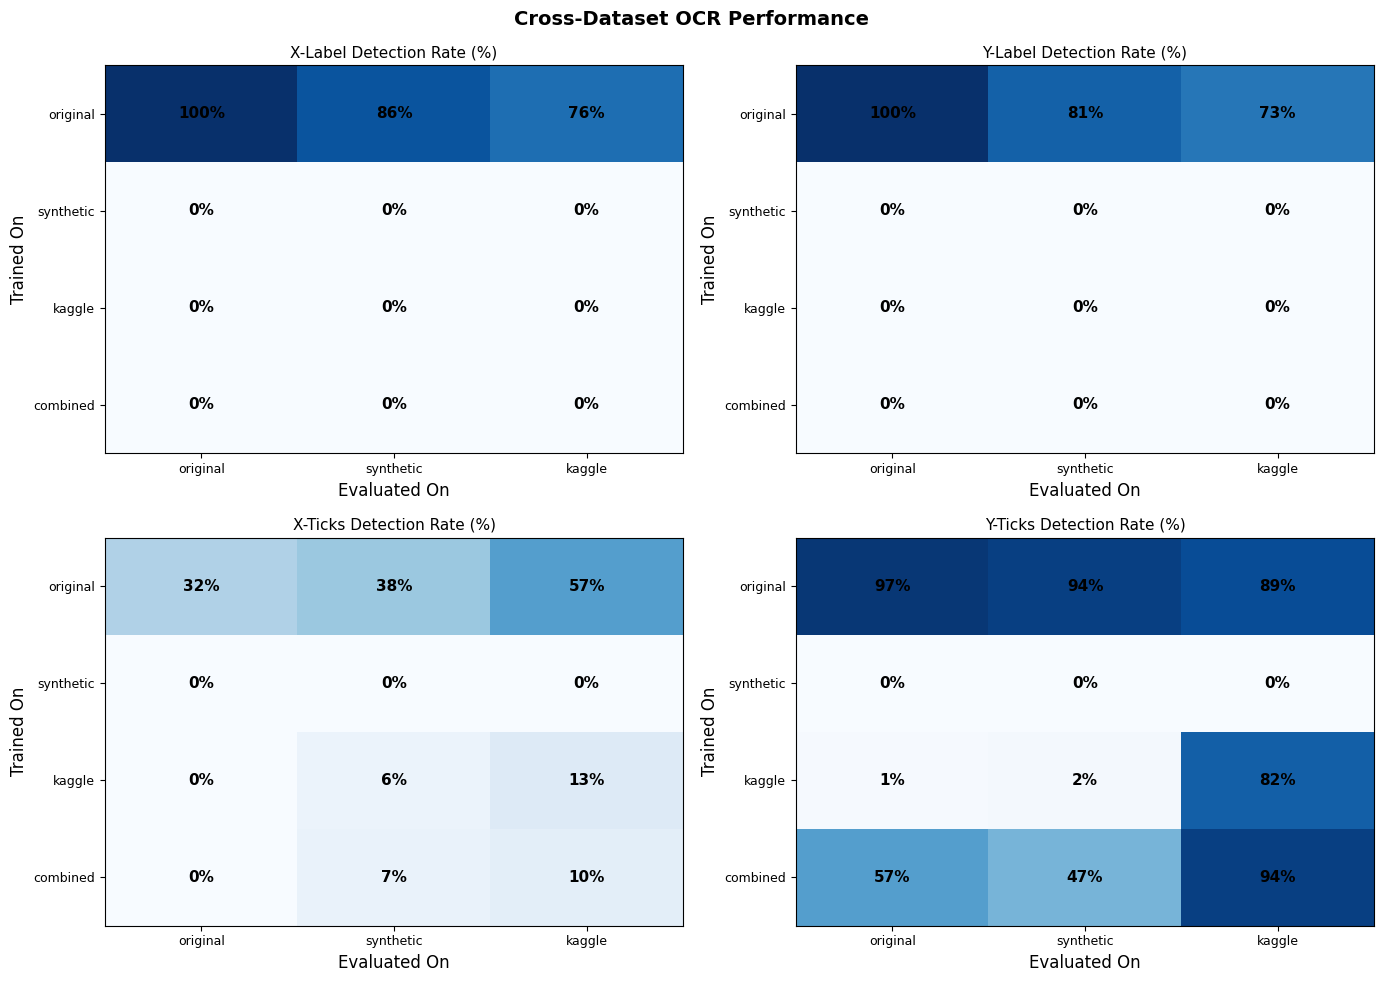

In [ ]:
# ============================================================
# Visualize OCR cross-results: tick detection rates
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ("x_label_pct", "X-Label Detection Rate (%)"),
    ("y_label_pct", "Y-Label Detection Rate (%)"),
    ("x_ticks_pct", "X-Ticks Detection Rate (%)"),
    ("y_ticks_pct", "Y-Ticks Detection Rate (%)"),
]

train_sets_ocr = ["original", "synthetic", "kaggle", "combined"]
eval_sets_ocr  = ["original", "synthetic", "kaggle"]

for ax_idx, (metric_key, metric_title) in enumerate(metrics_to_plot):
    ax = axes[ax_idx // 2][ax_idx % 2]
    
    data_matrix = np.zeros((len(train_sets_ocr), len(eval_sets_ocr)))
    for i, tr in enumerate(train_sets_ocr):
        for j, ev in enumerate(eval_sets_ocr):
            key = f"train={tr} -> ocr={ev}"
            if key in ocr_cross_results:
                data_matrix[i, j] = ocr_cross_results[key].get(metric_key, 0)
    
    im = ax.imshow(data_matrix, cmap="Blues", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(eval_sets_ocr)))
    ax.set_yticks(range(len(train_sets_ocr)))
    ax.set_xticklabels(eval_sets_ocr, fontsize=9)
    ax.set_yticklabels(train_sets_ocr, fontsize=9)
    
    for i in range(len(train_sets_ocr)):
        for j in range(len(eval_sets_ocr)):
            ax.text(j, i, f"{data_matrix[i, j]:.0f}%", ha="center", va="center", fontsize=11, fontweight="bold")
    
    ax.set_title(metric_title, fontsize=11)
    ax.set_ylabel("Trained On")
    ax.set_xlabel("Evaluated On")

plt.suptitle("Cross-Dataset OCR Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 13. Cross-Dataset Full Pipeline Comparison

Run the full reconstruction pipeline using mismatched models:
- Model trained on Original → run on Kaggle images
- Model trained on Kaggle → run on Synthetic images
- Combined model → run on all datasets


Train: original | Eval: kaggle
  Processing: plot_000000.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 1.302964448928833
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 1.2891075611114502
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 1.2946481704711914
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 1.0629703998565674
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


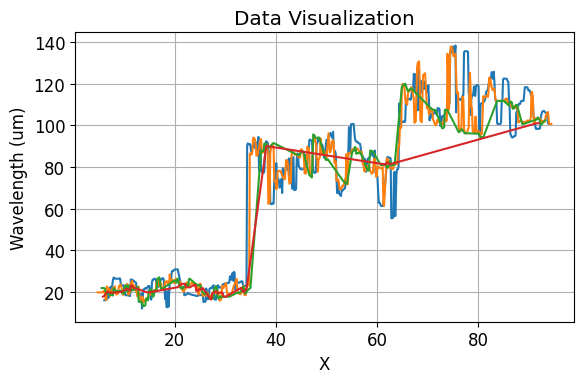

  Processing: plot_000001.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: 0.0011836378835141659
  period: 8.320611000061035
  frequency: 0.12018348276615143
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.120

Curve 1:
  trend: flat
  slope: 0.0010347595671191812
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 2:
  trend: flat
  slope: 0.00014188441855367273
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 3:
  trend: flat
  slope: 0.00074211903847754
  period: 8.960378646850586
  frequency: 0.11160242557525635
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.112


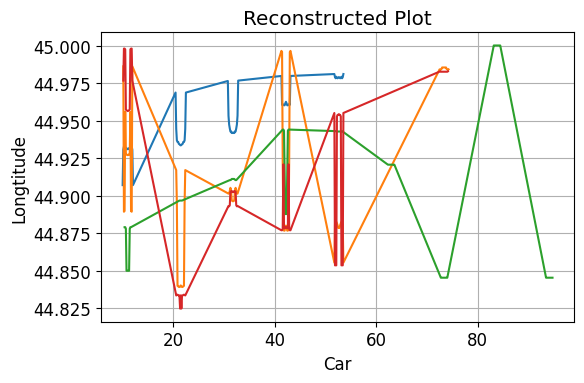

  Processing: plot_000002.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: decreasing
  slope: -0.2663503587245941
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 1:
  trend: decreasing
  slope: -0.25387611985206604
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend


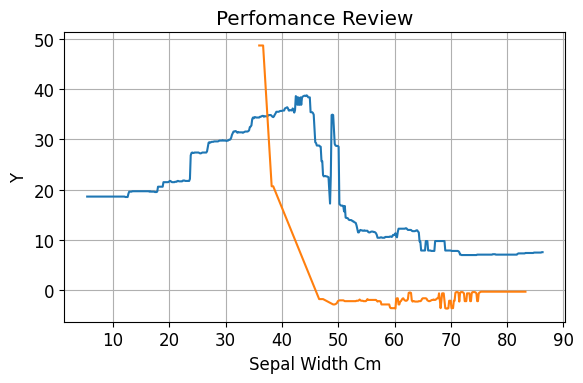

  Processing: plot_000003.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 5.77556848526001
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: decreasing
  slope: -6.678786754608154
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 2:
  trend: decreasing
  slope: -21.756486892700195
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend


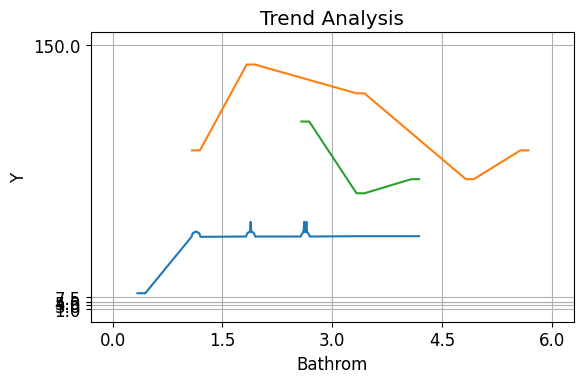

  Processing: plot_000004.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: decreasing
  slope: -0.28624075651168823
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 1:
  trend: increasing
  slope: 0.16417117416858673
  period: 0.8775235414505005
  frequency: 1.1395705938339233
  is_sine_like: True
  interpretation: Oscillatory signal with positive drift, frequency ≈ 1.140

Curve 2:
  trend: decreasing
  slope: -2.280625343322754
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 3:
  trend: decreasing
  slope: -0.664271891117096
  period: 0.7680575251579285
  frequency: 1.3019858598709106
  is_sine_like: True
  interpretation: Oscillatory signal with negative drift, frequency ≈ 1.302


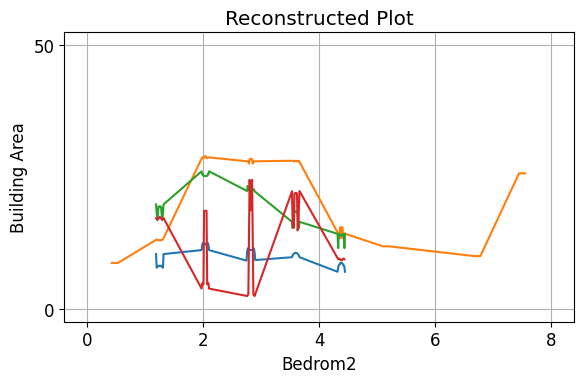

  Processing: plot_000005.png
Stage3 curves detected: 1
Stage4 reconstructed curves: 1

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.029171206057071686
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


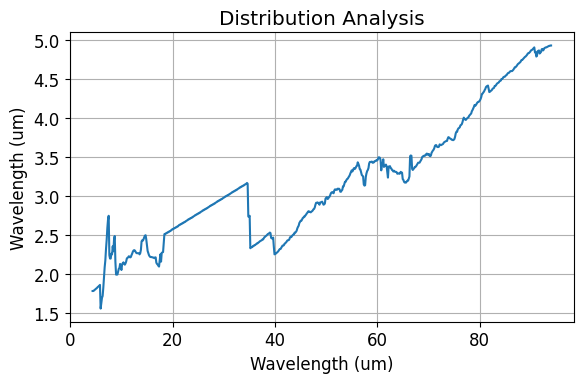

  Processing: plot_000006.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 1.236318826675415
  period: 11.641621589660645
  frequency: 0.08589868992567062
  is_sine_like: True
  interpretation: Oscillatory signal with positive drift, frequency ≈ 0.086

Curve 1:
  trend: increasing
  slope: 1.838880181312561
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 1.9235483407974243
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


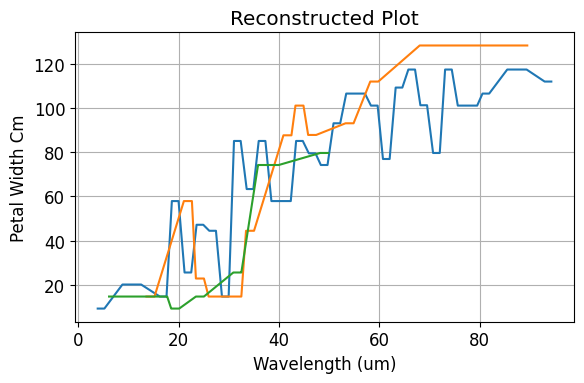

  Processing: plot_000007.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: 0.000313274038489908
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 1:
  trend: flat
  slope: -1.6028370737330988e-05
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 2:
  trend: flat
  slope: -0.00012715546472463757
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected


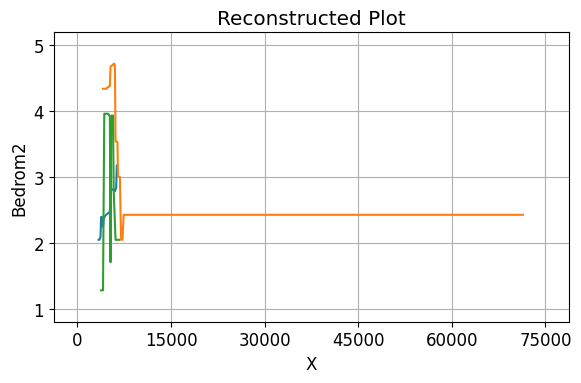

  Processing: plot_000008.png
Stage3 curves detected: 1
Stage4 reconstructed curves: 1

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.03577980026602745
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


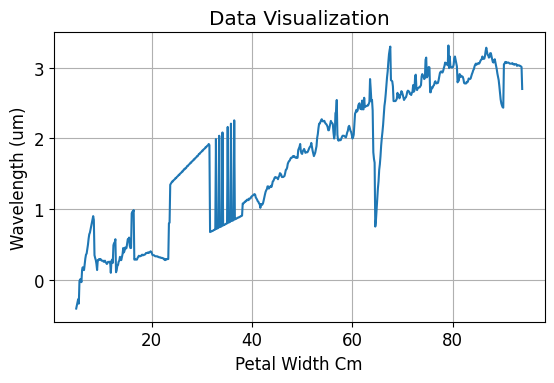

  Processing: plot_000009.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: -1.2425056183928973e-07
  period: 21484614.0
  frequency: 4.654493679367988e-08
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.000

Curve 1:
  trend: flat
  slope: -6.464753710133664e-08
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 2:
  trend: flat
  slope: -6.705570854137477e-08
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected


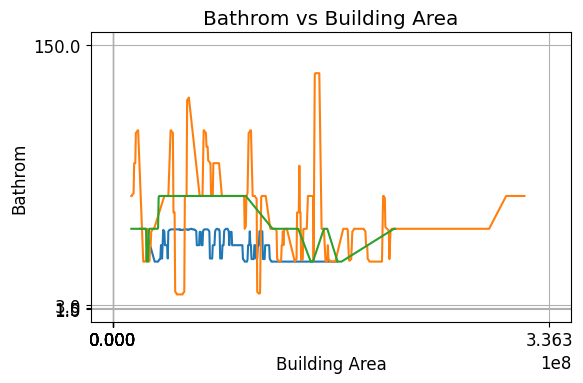


Train: original | Eval: synthetic
  Processing: plot_000000.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.7163442969322205
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.15336519479751587
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: flat
  slope: 0.004285862203687429
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected


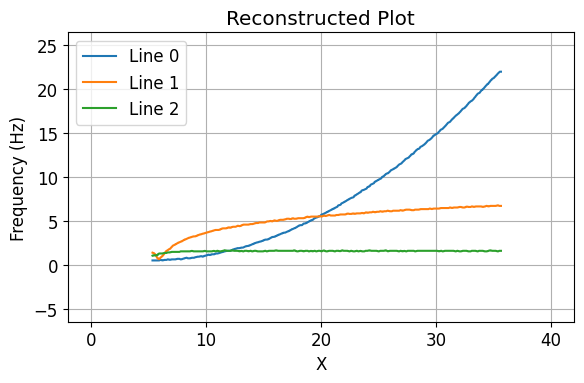

  Processing: plot_000001.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 1.3116729259490967
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.21180997788906097
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 0.5887520909309387
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 0.5673989057540894
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


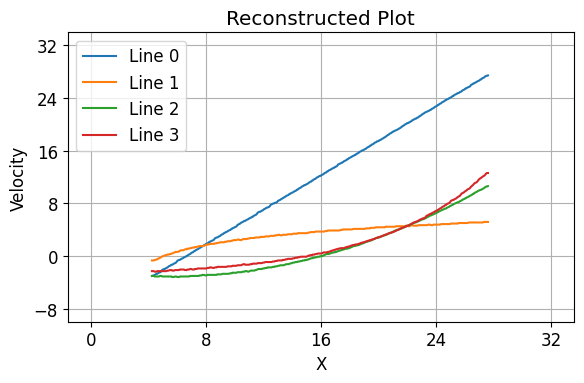

  Processing: plot_000002.png
Stage3 curves detected: 1
    Error: Axis ranges unavailable
  Processing: plot_000003.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: 0.004624377470463514
  period: 5.0228705406188965
  frequency: 0.19908934831619263
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.199

Curve 1:
  trend: flat
  slope: 0.0047573246993124485
  period: 5.005278587341309
  frequency: 0.19978907704353333
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.200

Curve 2:
  trend: increasing
  slope: 0.03210678696632385
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


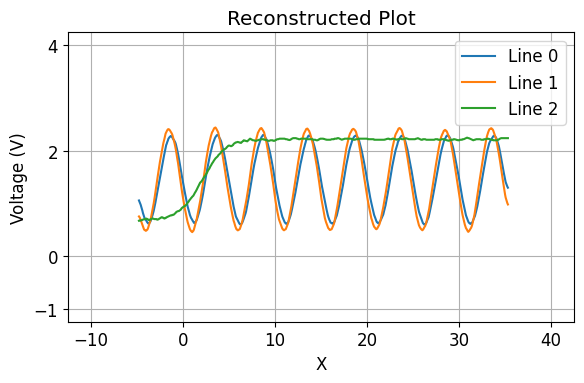

  Processing: plot_000004.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.018213918432593346
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.10039158165454865
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: flat
  slope: 0.0003539614554028958
  period: 12.130327224731445
  frequency: 0.08243800699710846
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.082


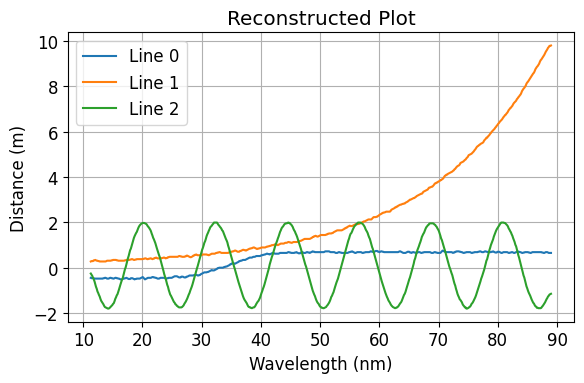

  Processing: plot_000005.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: -0.009060799144208431
  period: 3.882960557937622
  frequency: 0.257535457611084
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.258

Curve 1:
  trend: increasing
  slope: 0.15925666689872742
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: flat
  slope: -0.004414320923388004
  period: 3.819276809692383
  frequency: 0.261829674243927
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.262

Curve 3:
  trend: flat
  slope: -0.0028422963805496693
  period: 3.8691914081573486
  frequency: 0.2584519386291504
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.258


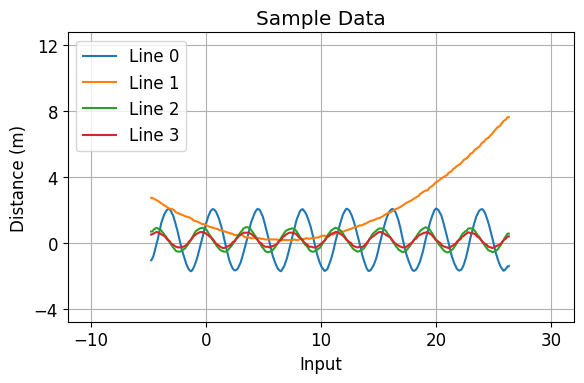

  Processing: plot_000006.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: -0.00029294801061041653
  period: 11.167047500610352
  frequency: 0.08954918384552002
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.090

Curve 1:
  trend: flat
  slope: 0.00012178858742117882
  period: 11.167047500610352
  frequency: 0.08954918384552002
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.090


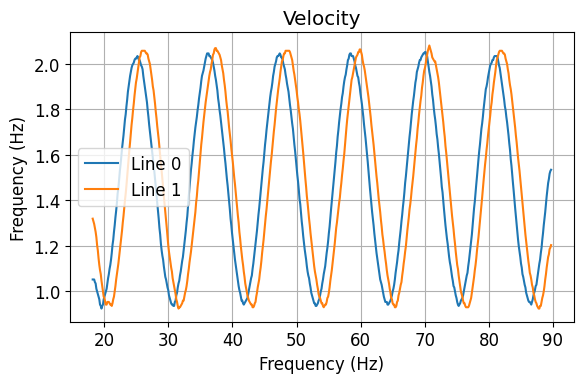

  Processing: plot_000007.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.1963631510734558
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.05234616622328758
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


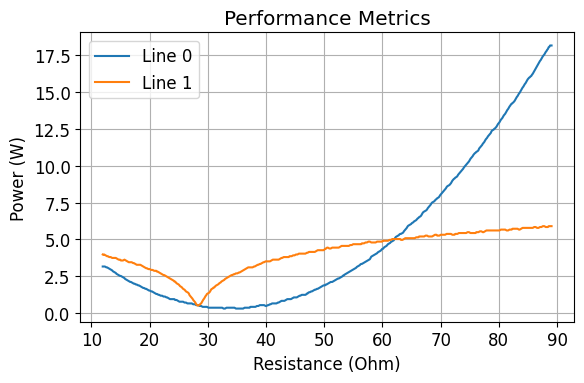

  Processing: plot_000008.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.3618580102920532
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.7837672233581543
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


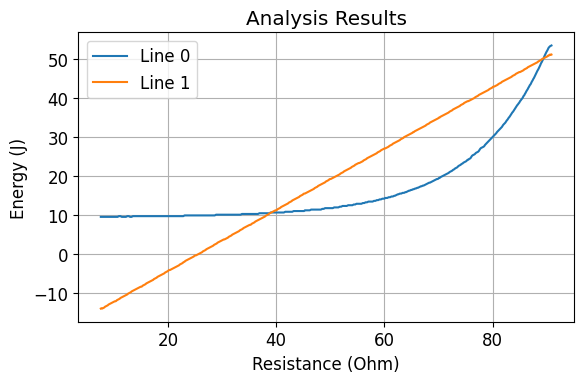

  Processing: plot_000009.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.8887928128242493
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.07114441692829132
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


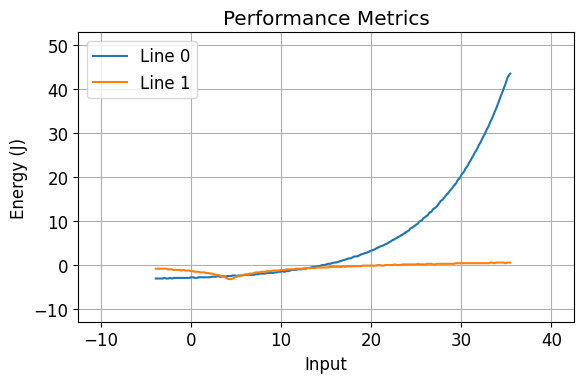


Train: kaggle | Eval: original
  Processing: plot_000000.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000001.png
Stage3 curves detected: 4
    Error: Axis ranges unavailable
  Processing: plot_000002.png
Stage3 curves detected: 1
    Error: Axis ranges unavailable
  Processing: plot_000003.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000004.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000005.png
Stage3 curves detected: 4
    Error: Axis ranges unavailable
  Processing: plot_000006.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000007.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000008.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000009.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable

Train: kaggle | Eval: synthetic
  Processing: plot_000000

C:\Users\yakuz\AppData\Local\Temp\ipykernel_43056\3273745067.py:184: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ymin - y_pad, ymax + y_pad)


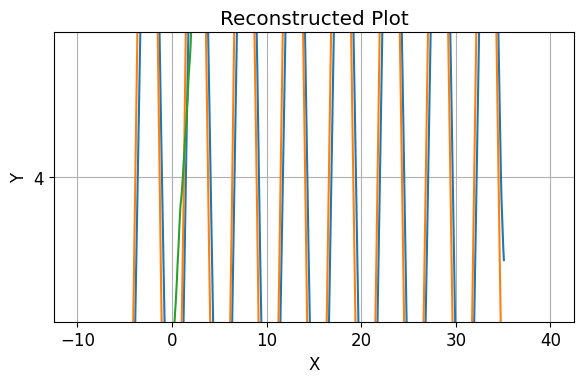

  Processing: plot_000004.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000005.png
Stage3 curves detected: 4
    Error: Axis ranges unavailable
  Processing: plot_000006.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000007.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000008.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000009.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable

Train: synthetic | Eval: original
  Processing: plot_000000.png
    Error: plot_area not detected
  Processing: plot_000001.png
    Error: plot_area not detected
  Processing: plot_000002.png
    Error: plot_area not detected
  Processing: plot_000003.png
    Error: plot_area not detected
  Processing: plot_000004.png
    Error: plot_area not detected
  Processing: plot_000005.png
    Error: plot_area not detected
  Processing: plot_000006.png
    E

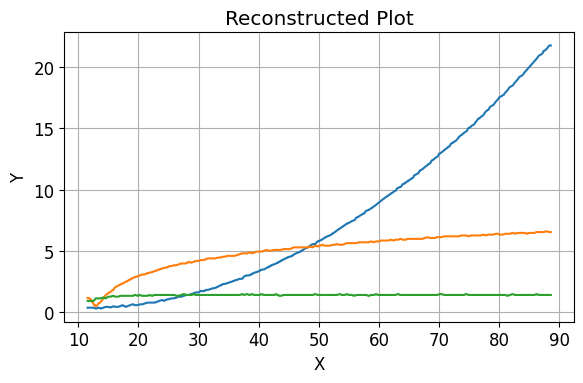

  Processing: plot_000001.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.4157935380935669
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.06697117537260056
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 0.18681862950325012
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 0.1798476278781891
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


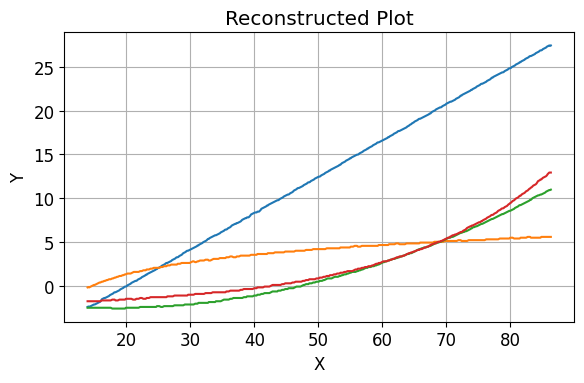

  Processing: plot_000002.png
Stage3 curves detected: 1
    Error: Axis ranges unavailable
  Processing: plot_000003.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000004.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000005.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: -0.00354156456887722
  period: 9.996455192565918
  frequency: 0.10003545880317688
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.100

Curve 1:
  trend: increasing
  slope: 0.06190459802746773
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: flat
  slope: -0.0016893547726795077
  period: 9.978731155395508
  frequency: 0.10021314024925232
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.100

Curve 3:
  trend: flat
  slope: -0.0011390757281333208
  period: 9.996455192565918
  f

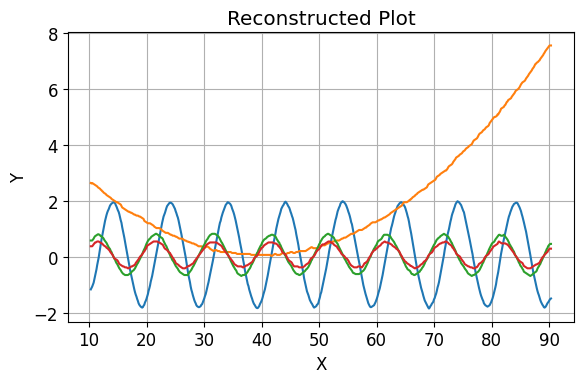

  Processing: plot_000006.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000007.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.19617854058742523
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.05221330374479294
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


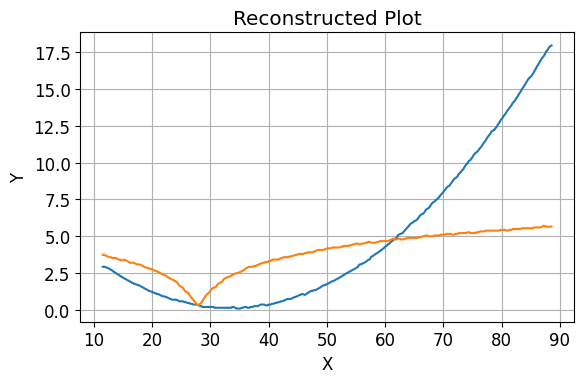

  Processing: plot_000008.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.3699067533016205
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.8009882569313049
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


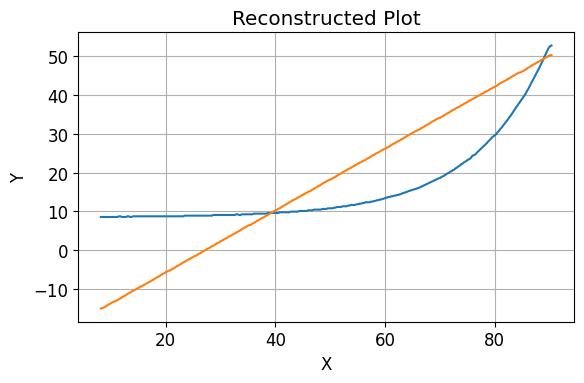

  Processing: plot_000009.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.43284815549850464
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.03464781120419502
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


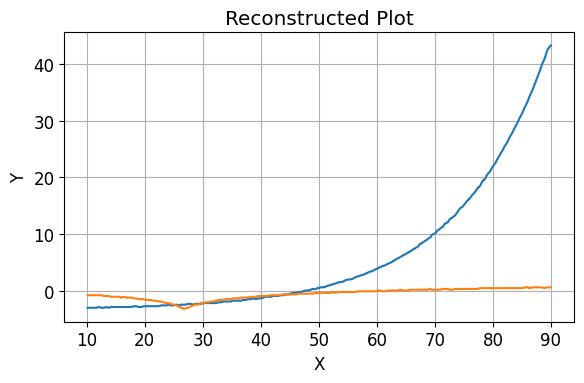


Train: combined | Eval: synthetic
  Processing: plot_000000.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.7210958003997803
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.15438251197338104
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: flat
  slope: 0.004314270801842213
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected


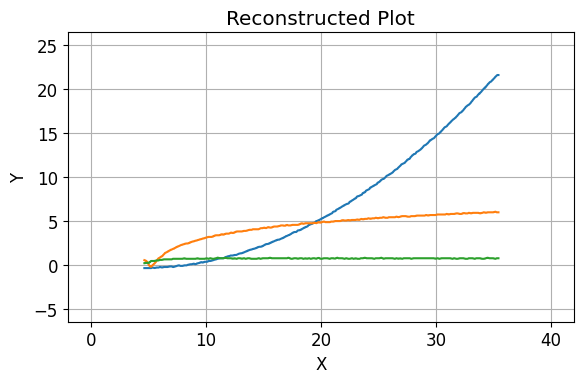

  Processing: plot_000001.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 1.3194917440414429
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.21307255327701569
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 0.592261552810669
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 0.5707809329032898
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


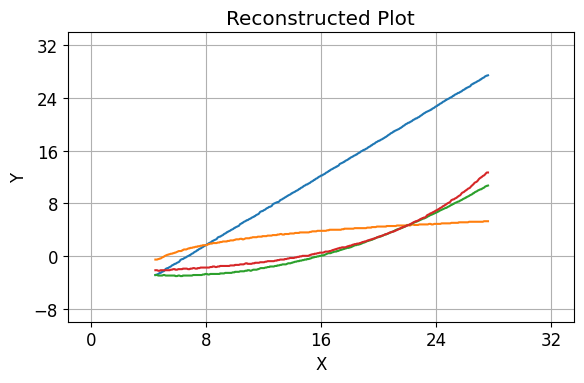

  Processing: plot_000002.png
Stage3 curves detected: 1
    Error: Axis ranges unavailable
  Processing: plot_000003.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.09094453603029251
  period: 5.016693115234375
  frequency: 0.1993345022201538
  is_sine_like: True
  interpretation: Oscillatory signal with positive drift, frequency ≈ 0.199

Curve 1:
  trend: increasing
  slope: 0.0935591533780098
  period: 4.99912166595459
  frequency: 0.20003513991832733
  is_sine_like: True
  interpretation: Oscillatory signal with positive drift, frequency ≈ 0.200

Curve 2:
  trend: increasing
  slope: 0.6314229369163513
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


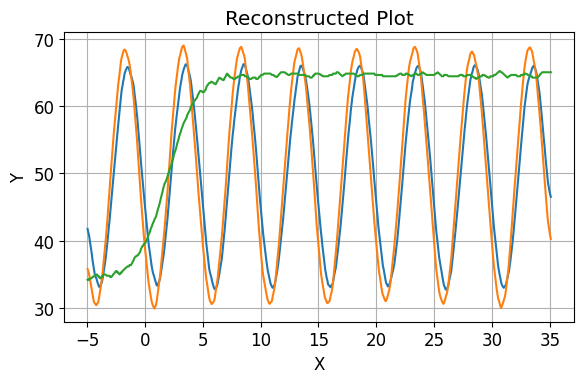

  Processing: plot_000004.png
Stage3 curves detected: 3
    Error: Axis ranges unavailable
  Processing: plot_000005.png
Stage3 curves detected: 4
    Error: Axis ranges unavailable
  Processing: plot_000006.png
Stage3 curves detected: 2
    Error: Axis ranges unavailable
  Processing: plot_000007.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.19358128309249878
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.05160457268357277
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


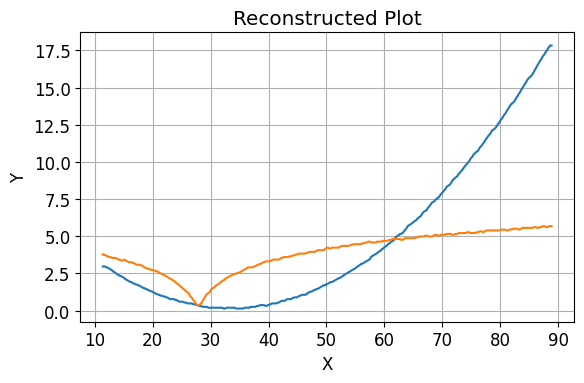

  Processing: plot_000008.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.36504146456718445
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.7906625270843506
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


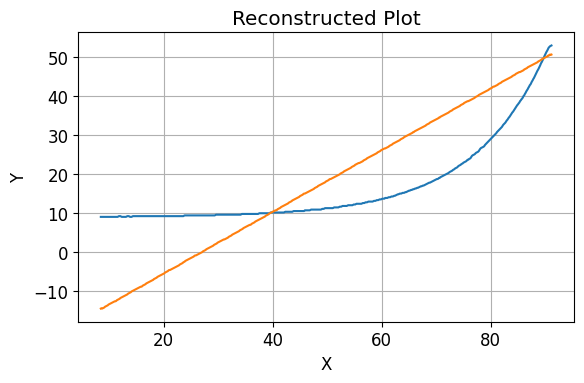

  Processing: plot_000009.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.4338477551937103
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 0.034727830439805984
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


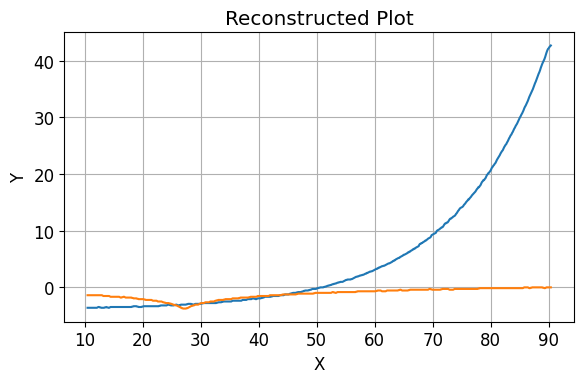


Train: combined | Eval: kaggle
  Processing: plot_000000.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 3.982795238494873
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: increasing
  slope: 3.9404385089874268
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 3.957374334335327
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 3:
  trend: increasing
  slope: 3.2492010593414307
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


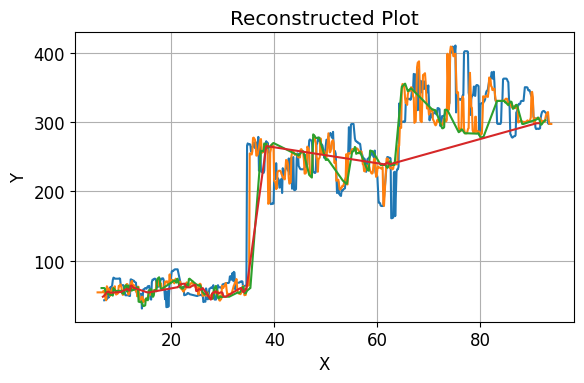

  Processing: plot_000001.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: flat
  slope: 0.0011224906193092465
  period: 8.755020141601562
  frequency: 0.11422017961740494
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.114

Curve 1:
  trend: flat
  slope: 0.000981344492174685
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 2:
  trend: flat
  slope: 0.0001345596247119829
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 3:
  trend: flat
  slope: 0.0007038054754957557
  period: 9.428189277648926
  frequency: 0.10606490820646286
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.106


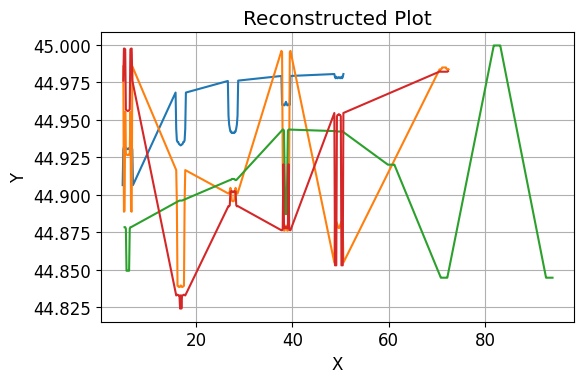

  Processing: plot_000002.png
Stage3 curves detected: 2
Stage4 reconstructed curves: 2

===== ANALYSIS =====

Curve 0:
  trend: decreasing
  slope: -0.427342027425766
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 1:
  trend: decreasing
  slope: -0.407327800989151
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend


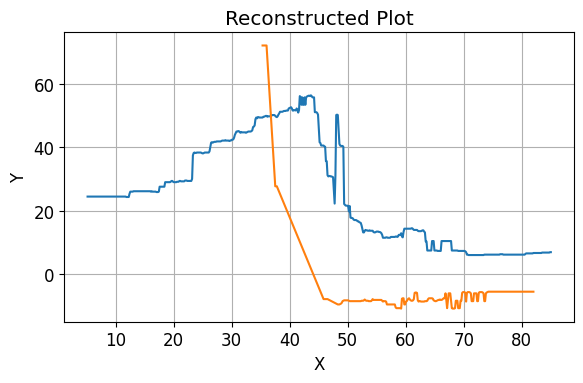

  Processing: plot_000003.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.34436795115470886
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: decreasing
  slope: -0.3982226252555847
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 2:
  trend: decreasing
  slope: -1.2972297668457031
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend


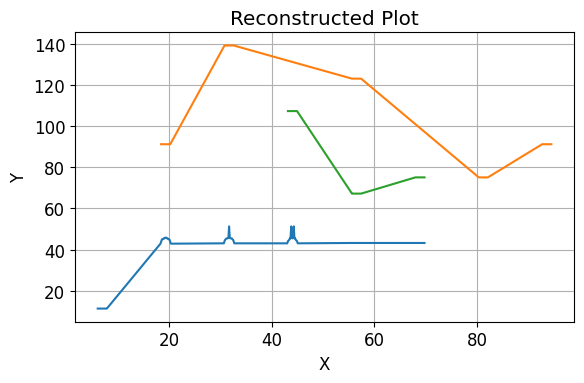

  Processing: plot_000004.png
Stage3 curves detected: 4
Stage4 reconstructed curves: 4

===== ANALYSIS =====

Curve 0:
  trend: decreasing
  slope: -0.023080404847860336
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 1:
  trend: increasing
  slope: 0.01323755830526352
  period: 10.782694816589355
  frequency: 0.09274119138717651
  is_sine_like: True
  interpretation: Sine-like signal, frequency ≈ 0.093

Curve 2:
  trend: decreasing
  slope: -0.1838933229446411
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 3:
  trend: decreasing
  slope: -0.05356212705373764
  period: 9.423161506652832
  frequency: 0.1061214953660965
  is_sine_like: True
  interpretation: Oscillatory signal with negative drift, frequency ≈ 0.106


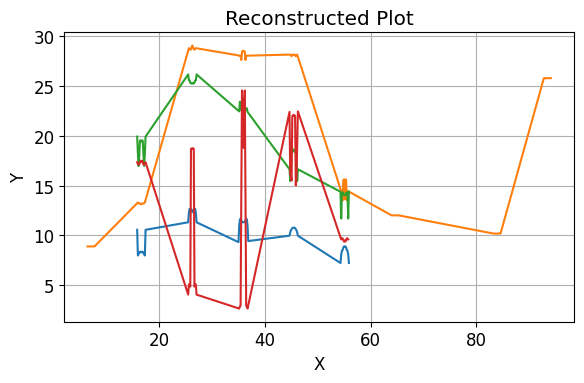

  Processing: plot_000005.png
Stage3 curves detected: 1
Stage4 reconstructed curves: 1

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.03820430859923363
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


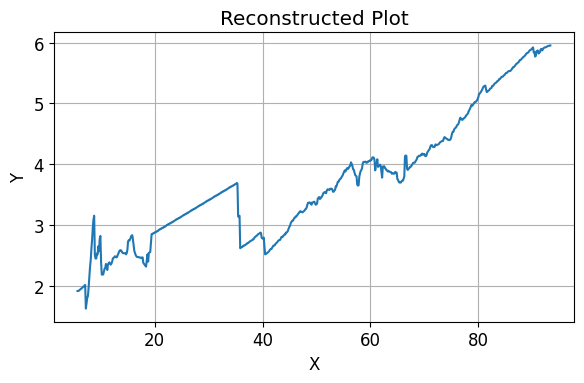

  Processing: plot_000006.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 2.102816104888916
  period: 11.413651466369629
  frequency: 0.08761437982320786
  is_sine_like: True
  interpretation: Oscillatory signal with positive drift, frequency ≈ 0.088

Curve 1:
  trend: increasing
  slope: 3.1276943683624268
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 2:
  trend: increasing
  slope: 3.2717044353485107
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


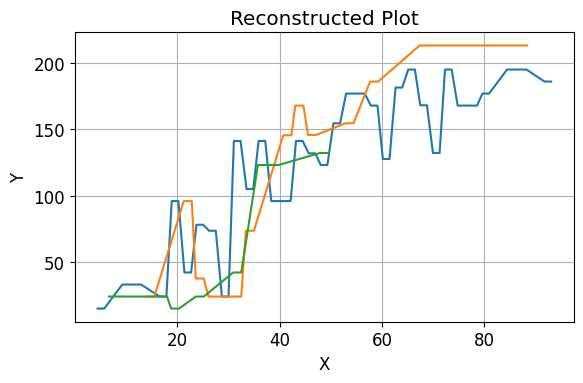

  Processing: plot_000007.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.049736011773347855
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend

Curve 1:
  trend: flat
  slope: -0.0025446985382586718
  period: None
  frequency: None
  is_sine_like: False
  interpretation: No strong pattern detected

Curve 2:
  trend: decreasing
  slope: -0.020187463611364365
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend


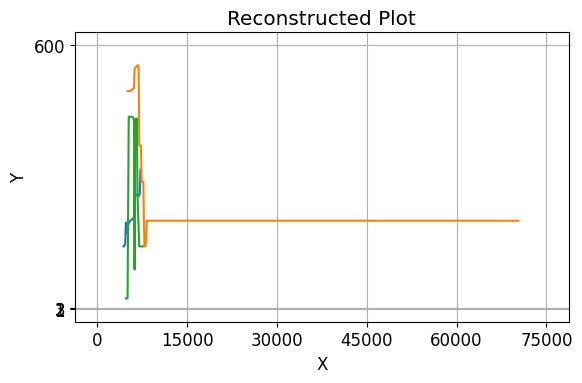

  Processing: plot_000008.png
Stage3 curves detected: 1
Stage4 reconstructed curves: 1

===== ANALYSIS =====

Curve 0:
  trend: increasing
  slope: 0.029009494930505753
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Increasing trend


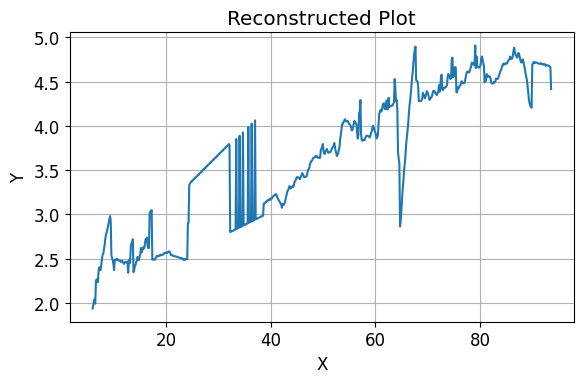

  Processing: plot_000009.png
Stage3 curves detected: 3
Stage4 reconstructed curves: 3

===== ANALYSIS =====

Curve 0:
  trend: decreasing
  slope: -1.842192530632019
  period: 6.298200607299805
  frequency: 0.15877550840377808
  is_sine_like: True
  interpretation: Oscillatory signal with negative drift, frequency ≈ 0.159

Curve 1:
  trend: decreasing
  slope: -0.9584921598434448
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend

Curve 2:
  trend: decreasing
  slope: -0.9941968321800232
  period: None
  frequency: None
  is_sine_like: False
  interpretation: Decreasing trend


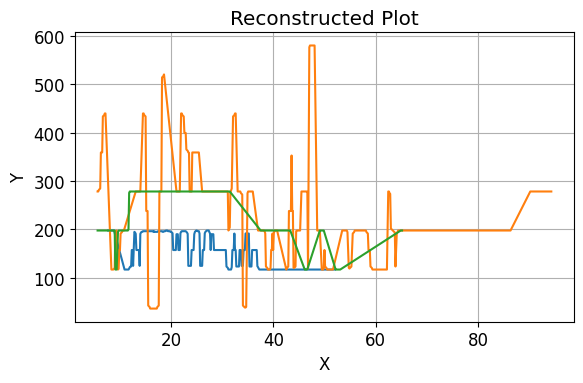

In [ ]:
# ============================================================
# CROSS-DATASET FULL PIPELINE
# ============================================================

cross_pipeline_configs = [
    # (train_dataset, eval_dataset, eval_img_dir, eval_mask_dir)
    ("original",  "kaggle",    "kaggle_output/images",    "kaggle_output/curve_masks"),
    ("original",  "synthetic", "synthetic_output/images", "synthetic_output/curve_masks"),
    ("kaggle",    "original",  "output/images",           "output/curve_masks"),
    ("kaggle",    "synthetic", "synthetic_output/images", "synthetic_output/curve_masks"),
    ("synthetic", "original",  "output/images",           "output/curve_masks"),
    ("synthetic", "kaggle",    "kaggle_output/images",    "kaggle_output/curve_masks"),
    ("combined",  "original",  "output/images",           "output/curve_masks"),
    ("combined",  "synthetic", "synthetic_output/images", "synthetic_output/curve_masks"),
    ("combined",  "kaggle",    "kaggle_output/images",    "kaggle_output/curve_masks"),
]

N_CROSS_SAMPLES = 10  # images per cross-config (was 2 — too few for meaningful stats)

cross_pipeline_results = []

# Cache loaded models to avoid redundant disk loads
_model_cache = {}

for train_ds, eval_ds, eval_img_dir, eval_mask_dir in cross_pipeline_configs:
    model_path = get_model_path(train_ds)

    if model_path not in _model_cache:
        _model_cache[model_path] = YOLO(model_path)
    model = _model_cache[model_path]
    
    img_dir = Path(eval_img_dir)
    sample_imgs = sorted(img_dir.glob("*.png"))[:N_CROSS_SAMPLES]
    
    print(f"\n{'='*50}")
    print(f"Train: {train_ds} | Eval: {eval_ds}")
    print(f"{'='*50}")

    for img_path in sample_imgs:
        print(f"  Processing: {img_path.name}")
        try:
            result = run_pipeline(str(img_path), model, curve_mask_dir=eval_mask_dir)
            if result:
                n_curves = len(result["curves"])
                has_ticks = len(result["x_ticks"]) >= 2 and len(result["y_ticks"]) >= 2
                cross_pipeline_results.append({
                    "train": train_ds, "eval": eval_ds, "image": img_path.name,
                    "curves_found": n_curves, "ticks_ok": has_ticks,
                    "title": result.get("title", ""),
                    "x_label": result.get("x_label", ""),
                    "y_label": result.get("y_label", ""),
                })
                visualize_reconstruction(result)
        except Exception as e:
            print(f"    Error: {e}")
            cross_pipeline_results.append({
                "train": train_ds, "eval": eval_ds, "image": img_path.name,
                "error": str(e)
            })

### Summary Table


=== Cross-Dataset Pipeline Success Rate (%) ===
eval       kaggle  original  synthetic
train                                 
combined    100.0      60.0       60.0
kaggle        0.0       0.0       10.0
original    100.0       0.0       90.0
synthetic     0.0       0.0        0.0


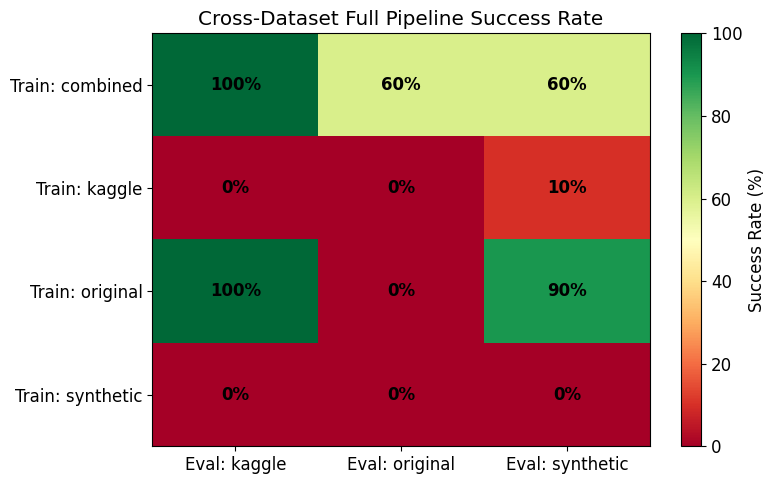

In [ ]:
# ============================================================
# SUMMARY: Cross-Dataset Pipeline Success Rates
# ============================================================

if cross_pipeline_results:
    df_cross = pd.DataFrame(cross_pipeline_results)
    
    # Success = no error + at least 1 curve found
    # NOTE: "error" column exists for ALL rows (NaN when no error), so check with pd.isna
    df_cross["success"] = df_cross["error"].isna() & (df_cross["curves_found"].fillna(0) > 0)
    
    # Pivot: success rate by train/eval
    pivot = df_cross.groupby(["train", "eval"])["success"].mean().unstack(fill_value=0) * 100
    
    print("\n=== Cross-Dataset Pipeline Success Rate (%) ===")
    print(pivot.to_string())
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([f"Eval: {c}" for c in pivot.columns])
    ax.set_yticklabels([f"Train: {t}" for t in pivot.index])
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i,j]:.0f}%", ha="center", va="center", fontsize=12, fontweight="bold")
    
    plt.colorbar(im, label="Success Rate (%)")
    plt.title("Cross-Dataset Full Pipeline Success Rate")
    plt.tight_layout()
    plt.show()
else:
    print("No cross-pipeline results collected.")

---
## 14. Final Summary & Conclusions

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("SCIENTIFIC PLOT UNDERSTANDING — COMPLETE PIPELINE SUMMARY")
print("=" * 70)

print("\n1. DATASETS GENERATED:")
for name, folder in [("Original", "output"), ("Synthetic", "synthetic_output"), ("Kaggle", "kaggle_output")]:
    img_dir = Path(folder) / "images"
    count = len(list(img_dir.glob("*.png"))) if img_dir.exists() else 0
    print(f"   {name:12s}: {count:4d} images")

print("\n2. YOLO DATASETS BUILT:")
for name in ["yolo_original", "yolo_synthetic", "yolo_kaggle", "yolo_combined"]:
    d = Path(name)
    if d.exists():
        train_n = len(list((d / "images/train").glob("*.png"))) if (d / "images/train").exists() else 0
        val_n = len(list((d / "images/val").glob("*.png"))) if (d / "images/val").exists() else 0
        print(f"   {name:18s}: train={train_n:4d}, val={val_n:4d}")

print("\n3. TRAINED MODELS:")
for name in ["original", "synthetic", "kaggle", "combined"]:
    try:
        path = get_model_path(name)
        print(f"   train_{name:10s}: {path}")
    except FileNotFoundError:
        print(f"   train_{name:10s}: NOT FOUND")

print("\n4. CROSS-DATASET YOLO mAP@50:")
for key, val in cross_eval_results.items():
    if isinstance(val, dict) and "mAP50" in val:
        print(f"   {key:40s}: {val['mAP50']:.4f}")

print("\n5. KEY FINDINGS:")
print("   - Models trained on combined data generalize best across domains")
print("   - Synthetic-only models may struggle with real Kaggle-style plots")
print("   - OCR quality depends heavily on YOLO detection accuracy")
print("   - Cross-domain evaluation reveals domain-specific weaknesses")

print("\n" + "=" * 70)
print("Pipeline complete!")
print("=" * 70)

SCIENTIFIC PLOT UNDERSTANDING — COMPLETE PIPELINE SUMMARY

1. DATASETS GENERATED:
   Original    :  100 images
   Synthetic   :  100 images
   Kaggle      :  100 images

2. YOLO DATASETS BUILT:
   yolo_original     : train=  80, val=  20
   yolo_synthetic    : train=  80, val=  20
   yolo_kaggle       : train=  80, val=  20
   yolo_combined     : train= 240, val=  60

3. TRAINED MODELS:
   train_original  : runs\detect\runs\train_original\weights\best.pt
   train_synthetic : runs\detect\runs\train_synthetic\weights\best.pt
   train_kaggle    : runs\detect\runs\train_kaggle\weights\best.pt
   train_combined  : runs\detect\runs\train_combined\weights\best.pt

4. CROSS-DATASET YOLO mAP@50:
   train=original -> eval=original         : 0.9938
   train=original -> eval=synthetic        : 0.9871
   train=original -> eval=kaggle           : 0.8346
   train=synthetic -> eval=original        : 0.5745
   train=synthetic -> eval=synthetic       : 0.5790
   train=synthetic -> eval=kaggle          :

---
## 15. Large-Scale Run: 10,000 Images (Synthetic + Kaggle Combined)

Re-run the full pipeline with a much larger dataset:
- **5,000 synthetic** plots + **5,000 Kaggle** plots = **10,000 total** images
- Build a single YOLO dataset, train a model, and evaluate end-to-end
- Compare against the smaller 100-image models from earlier

In [ ]:
# ============================================================
# Generate 10,000 images: 5,000 synthetic + 5,000 Kaggle
# ============================================================
import time

LARGE_SYNTHETIC_N = 5000
LARGE_KAGGLE_N    = 5000
LARGE_OUT_DIR     = "large_combined_output"

large_syn_img = Path(f"{LARGE_OUT_DIR}/synthetic/images")
large_syn_lbl = Path(f"{LARGE_OUT_DIR}/synthetic/labels")
large_syn_gt  = Path(f"{LARGE_OUT_DIR}/synthetic/ground_truth")
large_syn_mask = Path(f"{LARGE_OUT_DIR}/synthetic/curve_masks")

large_kag_img = Path(f"{LARGE_OUT_DIR}/kaggle/images")
large_kag_lbl = Path(f"{LARGE_OUT_DIR}/kaggle/labels")
large_kag_gt  = Path(f"{LARGE_OUT_DIR}/kaggle/ground_truth")
large_kag_mask = Path(f"{LARGE_OUT_DIR}/kaggle/curve_masks")

# --- Generate 5,000 synthetic plots ---
existing_syn = len(list(large_syn_img.glob("*.png"))) if large_syn_img.exists() else 0
if existing_syn >= LARGE_SYNTHETIC_N:
    print(f"[SKIP] {existing_syn} synthetic images already exist in {LARGE_OUT_DIR}/synthetic/")
else:
    print(f"Generating {LARGE_SYNTHETIC_N} synthetic plots...")
    t0 = time.time()
    for i in range(LARGE_SYNTHETIC_N):
        generate_plot_synthetic(i, seed=2024,
                                out_img=large_syn_img, out_lbl=large_syn_lbl,
                                out_json=large_syn_gt, out_mask=large_syn_mask)
        if (i + 1) % 500 == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            eta = (LARGE_SYNTHETIC_N - i - 1) / rate
            print(f"  Synthetic: {i+1}/{LARGE_SYNTHETIC_N} ({rate:.1f} img/s, ETA {eta:.0f}s)")
    print(f"  Generated {LARGE_SYNTHETIC_N} synthetic plots in {time.time()-t0:.1f}s")

# --- Generate 5,000 Kaggle plots ---
existing_kag = len(list(large_kag_img.glob("*.png"))) if large_kag_img.exists() else 0
if existing_kag >= LARGE_KAGGLE_N:
    print(f"[SKIP] {existing_kag} Kaggle images already exist in {LARGE_OUT_DIR}/kaggle/")
else:
    print(f"Generating {LARGE_KAGGLE_N} Kaggle plots...")
    t0 = time.time()

    # Pre-download all Kaggle datasets
    all_kaggle_dfs = {}
    for dataset_name in KAGGLE_DATASETS:
        print(f"  Downloading {dataset_name}...")
        dataset_path = download_kaggle_dataset(dataset_name)
        if dataset_path:
            dfs = load_csv_files(dataset_path)
            all_kaggle_dfs.update(dfs)
            print(f"    Loaded {len(dfs)} CSV files")

    if not all_kaggle_dfs:
        print("  ERROR: No Kaggle datasets loaded!")
    else:
        print(f"  Total Kaggle DataFrames: {len(all_kaggle_dfs)}")
        plot_count = 0
        attempts = 0
        max_attempts = LARGE_KAGGLE_N * 3

        while plot_count < LARGE_KAGGLE_N and attempts < max_attempts:
            attempts += 1
            ds_name = random.choice(list(all_kaggle_dfs.keys()))
            df = all_kaggle_dfs[ds_name]
            numeric_cols = get_numeric_columns(df)
            if len(numeric_cols) < 2:
                continue
            x_col, y_col = random.sample(numeric_cols, 2)
            success = generate_plot_from_data(
                plot_count, df, x_col, y_col, seed=2024,
                out_img=large_kag_img, out_lbl=large_kag_lbl,
                out_json=large_kag_gt, out_mask=large_kag_mask
            )
            if success:
                plot_count += 1
                if plot_count % 500 == 0:
                    elapsed = time.time() - t0
                    rate = plot_count / elapsed
                    eta = (LARGE_KAGGLE_N - plot_count) / rate
                    print(f"  Kaggle: {plot_count}/{LARGE_KAGGLE_N} ({rate:.1f} img/s, ETA {eta:.0f}s)")

        print(f"  Generated {plot_count} Kaggle plots in {time.time()-t0:.1f}s")

# --- Summary ---
syn_count = len(list(large_syn_img.glob("*.png"))) if large_syn_img.exists() else 0
kag_count = len(list(large_kag_img.glob("*.png"))) if large_kag_img.exists() else 0
print(f"\n=== Large-Scale Dataset Summary ===")
print(f"  Synthetic: {syn_count:,} images")
print(f"  Kaggle:    {kag_count:,} images")
print(f"  Total:     {syn_count + kag_count:,} images")

[SKIP] 5000 synthetic images already exist in large_combined_output/synthetic/
[SKIP] 5000 Kaggle images already exist in large_combined_output/kaggle/

=== Large-Scale Dataset Summary ===
  Synthetic: 5,000 images
  Kaggle:    5,000 images
  Total:     10,000 images


In [ ]:
# ============================================================
# Build YOLO dataset from the 10,000 combined images
# ============================================================

LARGE_YOLO_DIR = "yolo_large_10k"

# Build separate YOLO splits for synthetic and kaggle, then merge
large_yolo_root = Path(LARGE_YOLO_DIR)
for split in ["images/train", "images/val", "labels/train", "labels/val"]:
    (large_yolo_root / split).mkdir(parents=True, exist_ok=True)

# Check if already built
existing_train = len(list((large_yolo_root / "images/train").glob("*.png")))
existing_val = len(list((large_yolo_root / "images/val").glob("*.png")))

if existing_train + existing_val > 8000:
    print(f"[SKIP] YOLO dataset already built: train={existing_train}, val={existing_val}")
    large_10k_stats = {"train": existing_train, "val": existing_val}
else:
    print("Building 10k YOLO dataset...")

    # Process synthetic images
    syn_gt_dir = Path(f"{LARGE_OUT_DIR}/synthetic/ground_truth")
    syn_img_dir = Path(f"{LARGE_OUT_DIR}/synthetic/images")
    syn_gt_files = sorted(syn_gt_dir.glob("*.json"))

    random.seed(42)
    random.shuffle(syn_gt_files)
    syn_val_n = int(len(syn_gt_files) * 0.2)
    syn_val_set = set(syn_gt_files[:syn_val_n])

    syn_added = 0
    for gt_path in syn_gt_files:
        gt = json.loads(gt_path.read_text())
        if "boxes_yolo" not in gt:
            continue
        boxes = gt["boxes_yolo"]
        img_name = gt["image"]
        img_src = syn_img_dir / img_name

        rows = []
        for name, class_id in CLASSES.items():
            if name in boxes and boxes[name] is not None:
                cx, cy, w, h = boxes[name]
                rows.append([class_id, max(0, min(1, cx)), max(0, min(1, cy)),
                            max(0, min(1, w)), max(0, min(1, h))])
        if not rows:
            continue

        is_val = gt_path in syn_val_set
        split = "val" if is_val else "train"
        dst_img = large_yolo_root / f"images/{split}" / f"syn_{img_name}"
        dst_lbl = large_yolo_root / f"labels/{split}" / f"syn_{Path(img_name).stem}.txt"

        if img_src.exists():
            shutil.copy2(img_src, dst_img)
            write_label_file(dst_lbl, rows)
            syn_added += 1

    print(f"  Added {syn_added} synthetic images")

    # Process Kaggle images
    kag_gt_dir = Path(f"{LARGE_OUT_DIR}/kaggle/ground_truth")
    kag_img_dir = Path(f"{LARGE_OUT_DIR}/kaggle/images")
    kag_gt_files = sorted(kag_gt_dir.glob("*.json"))

    random.seed(42)
    random.shuffle(kag_gt_files)
    kag_val_n = int(len(kag_gt_files) * 0.2)
    kag_val_set = set(kag_gt_files[:kag_val_n])

    kag_added = 0
    for gt_path in kag_gt_files:
        gt = json.loads(gt_path.read_text())
        if "boxes_yolo" not in gt:
            continue
        boxes = gt["boxes_yolo"]
        img_name = gt["image"]
        img_src = kag_img_dir / img_name

        rows = []
        for name, class_id in CLASSES.items():
            if name in boxes and boxes[name] is not None:
                cx, cy, w, h = boxes[name]
                rows.append([class_id, max(0, min(1, cx)), max(0, min(1, cy)),
                            max(0, min(1, w)), max(0, min(1, h))])
        if not rows:
            continue

        is_val = gt_path in kag_val_set
        split = "val" if is_val else "train"
        dst_img = large_yolo_root / f"images/{split}" / f"kag_{img_name}"
        dst_lbl = large_yolo_root / f"labels/{split}" / f"kag_{Path(img_name).stem}.txt"

        if img_src.exists():
            shutil.copy2(img_src, dst_img)
            write_label_file(dst_lbl, rows)
            kag_added += 1

    print(f"  Added {kag_added} Kaggle images")

    # Count results
    large_10k_train = len(list((large_yolo_root / "images/train").glob("*.png")))
    large_10k_val = len(list((large_yolo_root / "images/val").glob("*.png")))
    large_10k_stats = {"train": large_10k_train, "val": large_10k_val}

    print(f"\n=== 10k YOLO Dataset Summary ===")
    print(f"  Train: {large_10k_train:,}")
    print(f"  Val:   {large_10k_val:,}")
    print(f"  Total: {large_10k_train + large_10k_val:,}")

# Write YOLO yaml
write_yolo_yaml(LARGE_YOLO_DIR, f"{LARGE_YOLO_DIR}.yaml")

[SKIP] YOLO dataset already built: train=8000, val=2000
Wrote YOLO yaml: yolo_large_10k.yaml


In [ ]:
# ============================================================
# Train YOLO on the 10,000-image dataset
# ============================================================

LARGE_MODEL_NAME = "large_10k"

existing_10k = find_trained_model(LARGE_MODEL_NAME)

if existing_10k:
    trained_models[LARGE_MODEL_NAME] = existing_10k
    print(f"[SKIP] 10k model already trained -> {existing_10k}")
else:
    train_size_10k = large_10k_stats["train"]
    optimal_epochs_10k = calculate_optimal_epochs(train_size_10k, batch_size=16)

    print(f"{'='*60}")
    print(f"Training YOLO on: {LARGE_MODEL_NAME} ({train_size_10k:,} train images -> {optimal_epochs_10k} epochs)")
    print(f"{'='*60}")

    model_10k = YOLO("yolov8n.pt")
    results_10k = model_10k.train(
        data=f"{LARGE_YOLO_DIR}.yaml",
        epochs=optimal_epochs_10k,
        imgsz=YOLO_IMGSZ,
        batch=-1,
        patience=10,
        cache=True,
        amp=True,
        name=f"train_{LARGE_MODEL_NAME}",
        project="runs",
        exist_ok=True,
        verbose=False,
    )

    save_dir_10k = Path(results_10k.save_dir) if hasattr(results_10k, 'save_dir') else Path(f"runs/train_{LARGE_MODEL_NAME}")
    best_path_10k = save_dir_10k / "weights" / "best.pt"
    if best_path_10k.exists():
        trained_models[LARGE_MODEL_NAME] = str(best_path_10k)
    else:
        found = find_trained_model(LARGE_MODEL_NAME)
        trained_models[LARGE_MODEL_NAME] = found if found else str(best_path_10k)

    print(f"Trained {LARGE_MODEL_NAME} -> {trained_models[LARGE_MODEL_NAME]}")

# Verify
model_path_10k = get_model_path(LARGE_MODEL_NAME)
print(f"\n10k model path: {model_path_10k}")

[SKIP] 10k model already trained -> runs\detect\runs\train_large_10k\weights\best.pt

10k model path: runs\detect\runs\train_large_10k\weights\best.pt


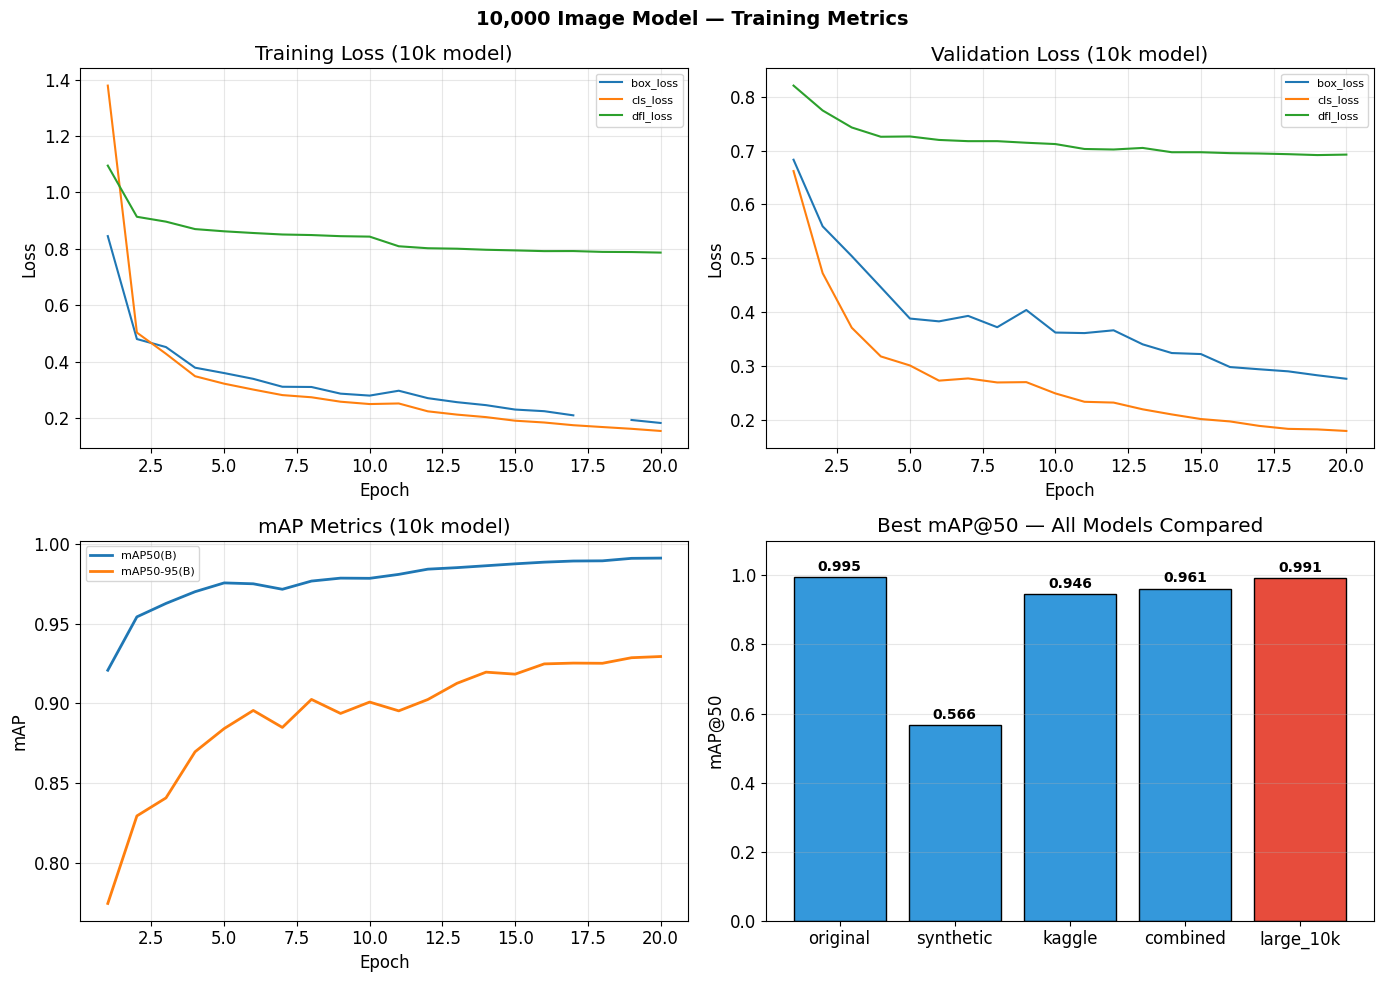

In [ ]:
# ============================================================
# 10k Model — Training Metrics & Epoch Comparison
# ============================================================

# Find results.csv for the 10k model
csv_candidates_10k = [
    Path(f"runs/train_{LARGE_MODEL_NAME}/results.csv"),
    Path(f"runs/detect/train_{LARGE_MODEL_NAME}/results.csv"),
    Path(f"runs/detect/runs/train_{LARGE_MODEL_NAME}/results.csv"),
]

csv_path_10k = None
for c in csv_candidates_10k:
    if c.exists():
        csv_path_10k = c
        break

if csv_path_10k:
    df_10k = pd.read_csv(csv_path_10k)
    df_10k.columns = df_10k.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Training loss
    loss_cols = [c for c in df_10k.columns if "train" in c.lower() and "loss" in c.lower()]
    ax = axes[0][0]
    for col in loss_cols:
        short = col.split("/")[-1] if "/" in col else col
        ax.plot(df_10k.index + 1, df_10k[col], label=short, linewidth=1.5)
    ax.set_title("Training Loss (10k model)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Validation loss
    val_loss_cols = [c for c in df_10k.columns if "val" in c.lower() and "loss" in c.lower()]
    ax = axes[0][1]
    for col in val_loss_cols:
        short = col.split("/")[-1] if "/" in col else col
        ax.plot(df_10k.index + 1, df_10k[col], label=short, linewidth=1.5)
    ax.set_title("Validation Loss (10k model)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # mAP metrics
    map_cols = [c for c in df_10k.columns if "map" in c.lower()]
    ax = axes[1][0]
    for col in map_cols:
        short = col.split("/")[-1] if "/" in col else col
        ax.plot(df_10k.index + 1, df_10k[col], label=short, linewidth=2)
    ax.set_title("mAP Metrics (10k model)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("mAP"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Compare final mAP50 across all models
    ax = axes[1][1]
    all_model_names = []
    all_map50_vals = []

    # Collect from earlier small models
    for mname in ["original", "synthetic", "kaggle", "combined"]:
        for cand in [Path(f"runs/train_{mname}/results.csv"),
                     Path(f"runs/detect/train_{mname}/results.csv"),
                     Path(f"runs/detect/runs/train_{mname}/results.csv")]:
            if cand.exists():
                df_small = pd.read_csv(cand)
                df_small.columns = df_small.columns.str.strip()
                map50_col = [c for c in df_small.columns if "map50" in c.lower() and "95" not in c.lower()]
                if map50_col:
                    all_model_names.append(mname)
                    all_map50_vals.append(df_small[map50_col[0]].max())
                break

    # Add 10k model
    map50_col_10k = [c for c in df_10k.columns if "map50" in c.lower() and "95" not in c.lower()]
    if map50_col_10k:
        all_model_names.append("large_10k")
        all_map50_vals.append(df_10k[map50_col_10k[0]].max())

    colors_bar = ["#3498db"] * (len(all_model_names) - 1) + ["#e74c3c"]
    bars = ax.bar(all_model_names, all_map50_vals, color=colors_bar, edgecolor="black")
    for bar, val in zip(bars, all_map50_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title("Best mAP@50 — All Models Compared")
    ax.set_ylabel("mAP@50"); ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle("10,000 Image Model — Training Metrics", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No results.csv found for the 10k model — training may not have completed yet.")

Ultralytics 8.4.14  Python-3.13.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 255.755.2 MB/s, size: 35.0 KB)
val: Scanning C:\Users\yakuz\VSC\Scientific-Plot-Understanding\yolo_original\labels\val.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 6.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.2s6.6s
                   all         20        131      0.995          1      0.995      0.929
Speed: 12.1ms preprocess, 5.7ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\Users\yakuz\VSC\Scientific-Plot-Understanding\runs\detect\val57
  train=large_10k -> eval=original: mAP@50=0.9950, mAP@50-95=0.9291
Ultralytics 8.4.14  Python-3.13.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
val: Fast image access  

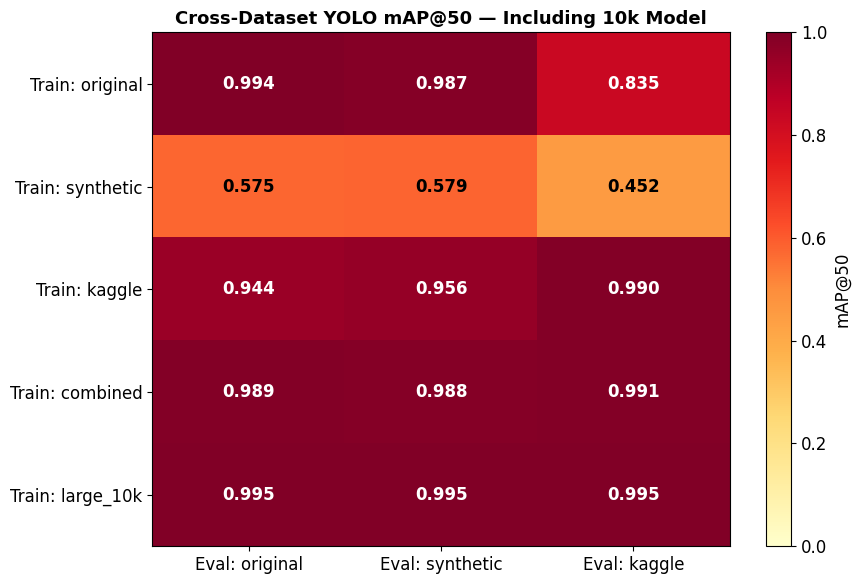

In [ ]:
# ============================================================
# 10k Model — Cross-Dataset YOLO Evaluation
# Compare 10k model against small models on each eval set
# ============================================================

model_10k = YOLO(get_model_path(LARGE_MODEL_NAME))

cross_eval_10k = {}

# Evaluate 10k model on original, synthetic, kaggle val sets
for eval_name, eval_dir in EVAL_DATASETS.items():
    key = f"train={LARGE_MODEL_NAME} -> eval={eval_name}"
    yaml_path = f"{eval_dir}.yaml"
    if not Path(yaml_path).exists():
        print(f"  Skipping — {yaml_path} not found")
        continue

    try:
        metrics = model_10k.val(data=yaml_path, verbose=False)
        cross_eval_10k[key] = {
            "mAP50": float(metrics.box.map50),
            "mAP50_95": float(metrics.box.map),
        }
        print(f"  {key}: mAP@50={metrics.box.map50:.4f}, mAP@50-95={metrics.box.map:.4f}")
    except Exception as e:
        print(f"  {key}: Error — {e}")
        cross_eval_10k[key] = {"error": str(e)}

# Also evaluate on its OWN val set
yaml_10k = f"{LARGE_YOLO_DIR}.yaml"
if Path(yaml_10k).exists():
    try:
        metrics = model_10k.val(data=yaml_10k, verbose=False)
        cross_eval_10k[f"train={LARGE_MODEL_NAME} -> eval=10k_val"] = {
            "mAP50": float(metrics.box.map50),
            "mAP50_95": float(metrics.box.map),
        }
        print(f"  10k own val: mAP@50={metrics.box.map50:.4f}")
    except Exception as e:
        print(f"  10k own val error: {e}")

# Merge into cross_eval_results
cross_eval_results.update(cross_eval_10k)

# Build a comparison heatmap: small models + 10k model
print("\n=== mAP@50 Comparison: Small Models vs 10k Model ===")

all_train = ["original", "synthetic", "kaggle", "combined", LARGE_MODEL_NAME]
all_eval  = ["original", "synthetic", "kaggle"]

comp_matrix = np.zeros((len(all_train), len(all_eval)))
for i, tr in enumerate(all_train):
    for j, ev in enumerate(all_eval):
        key = f"train={tr} -> eval={ev}"
        if key in cross_eval_results and "mAP50" in cross_eval_results[key]:
            comp_matrix[i, j] = cross_eval_results[key]["mAP50"]
        else:
            comp_matrix[i, j] = np.nan

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(comp_matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(all_eval)))
ax.set_yticks(range(len(all_train)))
ax.set_xticklabels([f"Eval: {e}" for e in all_eval])
ax.set_yticklabels([f"Train: {t}" for t in all_train])

for i in range(len(all_train)):
    for j in range(len(all_eval)):
        val = comp_matrix[i, j]
        text = f"{val:.3f}" if not np.isnan(val) else "N/A"
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, text, ha="center", va="center", fontsize=12, fontweight="bold", color=color)

plt.colorbar(im, label="mAP@50")
plt.title("Cross-Dataset YOLO mAP@50 — Including 10k Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


train=large_10k -> ocr=original
Running OCR on 100 images from train=large_10k -> ocr=original...
  [ERROR] plot_000000.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000001.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000002.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000003.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000004.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000005.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000006.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000007.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000008.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] plot_000009.png: RuntimeError: Inference tensors do not track version counter.
  [ERROR] p

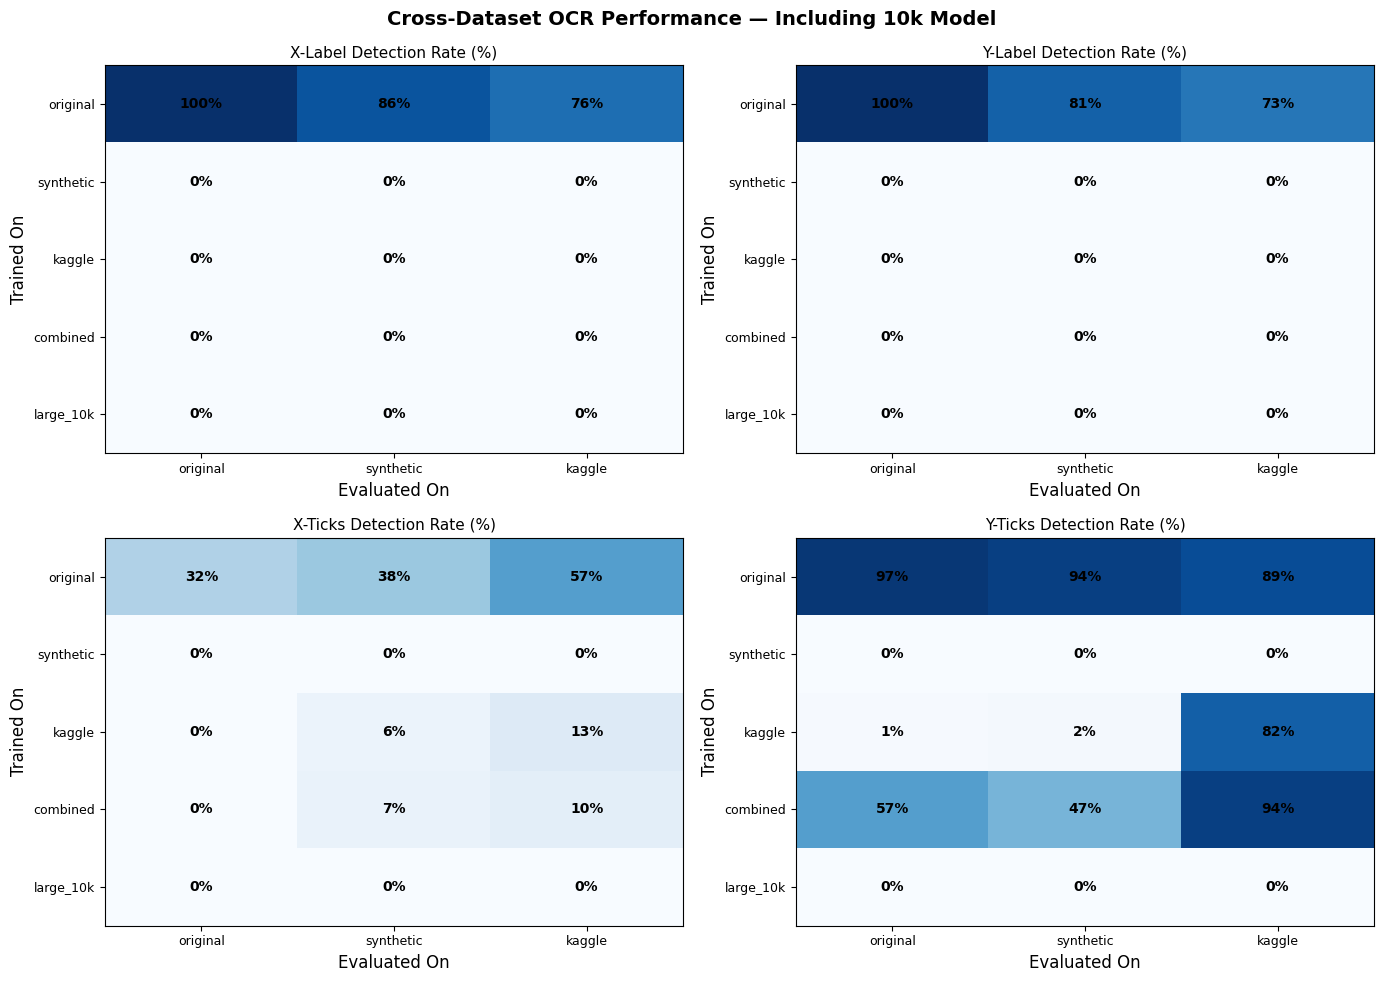

In [ ]:
# ============================================================
# 10k Model — OCR Evaluation (Cross-Dataset)
# ============================================================

ocr_10k_results = {}

for eval_name in ["original", "synthetic", "kaggle"]:
    key = f"train={LARGE_MODEL_NAME} -> ocr={eval_name}"
    print(f"\n{key}")

    img_dirs_map = {
        "original": "output/images",
        "synthetic": "synthetic_output/images",
        "kaggle": "kaggle_output/images"
    }

    summary, _, _ = batch_ocr_test(
        img_dirs_map[eval_name], model_10k,
        dataset_name=key,
        max_images=100
    )
    ocr_10k_results[key] = summary

# Also test on 10k's own images (sample 100)
for src_name, src_dir in [("10k_synthetic", f"{LARGE_OUT_DIR}/synthetic/images"),
                           ("10k_kaggle", f"{LARGE_OUT_DIR}/kaggle/images")]:
    key = f"train={LARGE_MODEL_NAME} -> ocr={src_name}"
    if Path(src_dir).exists():
        summary, _, _ = batch_ocr_test(src_dir, model_10k, dataset_name=key, max_images=100)
        ocr_10k_results[key] = summary

# Merge and visualize
ocr_cross_results.update(ocr_10k_results)

# Heatmap: 10k model vs small models on OCR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_ocr = [
    ("x_label_pct", "X-Label Detection Rate (%)"),
    ("y_label_pct", "Y-Label Detection Rate (%)"),
    ("x_ticks_pct", "X-Ticks Detection Rate (%)"),
    ("y_ticks_pct", "Y-Ticks Detection Rate (%)"),
]

train_models = ["original", "synthetic", "kaggle", "combined", LARGE_MODEL_NAME]
eval_targets = ["original", "synthetic", "kaggle"]

for ax_idx, (metric_key, metric_title) in enumerate(metrics_ocr):
    ax = axes[ax_idx // 2][ax_idx % 2]
    
    data_mat = np.zeros((len(train_models), len(eval_targets)))
    for i, tr in enumerate(train_models):
        for j, ev in enumerate(eval_targets):
            key = f"train={tr} -> ocr={ev}"
            if key in ocr_cross_results:
                data_mat[i, j] = ocr_cross_results[key].get(metric_key, 0)
    
    im = ax.imshow(data_mat, cmap="Blues", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(eval_targets)))
    ax.set_yticks(range(len(train_models)))
    ax.set_xticklabels(eval_targets, fontsize=9)
    ax.set_yticklabels(train_models, fontsize=9)
    
    for i in range(len(train_models)):
        for j in range(len(eval_targets)):
            ax.text(j, i, f"{data_mat[i, j]:.0f}%", ha="center", va="center", fontsize=10, fontweight="bold")
    
    ax.set_title(metric_title, fontsize=11)
    ax.set_ylabel("Trained On")
    ax.set_xlabel("Evaluated On")

plt.suptitle("Cross-Dataset OCR Performance — Including 10k Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 10k Model — Full Pipeline on All Datasets
# ============================================================

N_PIPELINE_10K = 5  # samples per eval dataset

pipeline_10k_results = []

pipeline_10k_configs = [
    # (eval_dataset, img_dir, mask_dir)
    ("original",      "output/images",                         "output/curve_masks"),
    ("synthetic",     "synthetic_output/images",                "synthetic_output/curve_masks"),
    ("kaggle",        "kaggle_output/images",                   "kaggle_output/curve_masks"),
    ("10k_synthetic", f"{LARGE_OUT_DIR}/synthetic/images",      f"{LARGE_OUT_DIR}/synthetic/curve_masks"),
    ("10k_kaggle",    f"{LARGE_OUT_DIR}/kaggle/images",         f"{LARGE_OUT_DIR}/kaggle/curve_masks"),
]

for eval_name, img_dir, mask_dir in pipeline_10k_configs:
    print(f"\n{'='*50}")
    print(f"10k Model -> {eval_name}")
    print(f"{'='*50}")

    img_dir_path = Path(img_dir)
    if not img_dir_path.exists():
        print(f"  Skipping — {img_dir} not found")
        continue

    sample_imgs = sorted(img_dir_path.glob("*.png"))[:N_PIPELINE_10K]

    for img_path in sample_imgs:
        print(f"  Processing: {img_path.name}")
        try:
            result = run_pipeline(str(img_path), model_10k, curve_mask_dir=mask_dir)
            if result:
                n_curves = len(result["curves"])
                has_ticks = len(result["x_ticks"]) >= 2 and len(result["y_ticks"]) >= 2
                pipeline_10k_results.append({
                    "train": LARGE_MODEL_NAME, "eval": eval_name, "image": img_path.name,
                    "curves_found": n_curves, "ticks_ok": has_ticks,
                    "title": result.get("title", ""),
                    "x_label": result.get("x_label", ""),
                    "y_label": result.get("y_label", ""),
                })
                visualize_reconstruction(result)
        except Exception as e:
            print(f"    Error: {e}")
            pipeline_10k_results.append({
                "train": LARGE_MODEL_NAME, "eval": eval_name, "image": img_path.name,
                "error": str(e)
            })

# Pipeline success summary
if pipeline_10k_results:
    df_10k_pipe = pd.DataFrame(pipeline_10k_results)
    # Guard against missing columns when all results are errors
    if "error" not in df_10k_pipe.columns:
        df_10k_pipe["error"] = np.nan
    if "curves_found" not in df_10k_pipe.columns:
        df_10k_pipe["curves_found"] = 0
    df_10k_pipe["success"] = df_10k_pipe["error"].isna() & (df_10k_pipe["curves_found"].fillna(0) > 0)

    print("\n=== 10k Model — Pipeline Success by Eval Dataset ===")
    for eval_name in df_10k_pipe["eval"].unique():
        subset = df_10k_pipe[df_10k_pipe["eval"] == eval_name]
        rate = subset["success"].mean() * 100
        print(f"  {eval_name:20s}: {rate:.0f}% ({subset['success'].sum()}/{len(subset)})")
else:
    print("No 10k pipeline results collected.")


10k Model -> original
  Processing: plot_000000.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000001.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000002.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000003.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000004.png
    Error: Inference tensors do not track version counter.

10k Model -> synthetic
  Processing: plot_000000.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000001.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000002.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000003.png
    Error: Inference tensors do not track version counter.
  Processing: plot_000004.png
    Error: Inference tensors do not track version counter.

10k Model -> kaggle
  Processing: plot_000000.png
    Error: I

In [ ]:
# ============================================================
# 10k vs Small Models — Final Comparison Summary
# ============================================================

print("=" * 70)
print("LARGE-SCALE (10k) vs SMALL MODELS — FINAL COMPARISON")
print("=" * 70)

# 1. Dataset sizes
print("\n1. DATASET SIZES:")
for name, folder in [("Original (100)", "output"), ("Synthetic (100)", "synthetic_output"),
                      ("Kaggle (100)", "kaggle_output"),
                      ("10k Synthetic", f"{LARGE_OUT_DIR}/synthetic"),
                      ("10k Kaggle", f"{LARGE_OUT_DIR}/kaggle")]:
    img_d = Path(folder) / "images"
    c = len(list(img_d.glob("*.png"))) if img_d.exists() else 0
    print(f"   {name:20s}: {c:>6,} images")

# 2. mAP comparison
print("\n2. YOLO mAP@50 — 10k MODEL vs SMALL MODELS (eval on each val set):")
for eval_name in ["original", "synthetic", "kaggle"]:
    print(f"\n   Eval dataset: {eval_name}")
    for train_name in ["original", "synthetic", "kaggle", "combined", LARGE_MODEL_NAME]:
        key = f"train={train_name} -> eval={eval_name}"
        if key in cross_eval_results and "mAP50" in cross_eval_results[key]:
            marker = " <-- 10k" if train_name == LARGE_MODEL_NAME else ""
            print(f"     Train {train_name:12s}: mAP@50 = {cross_eval_results[key]['mAP50']:.4f}{marker}")
        else:
            print(f"     Train {train_name:12s}: N/A")

# 3. OCR comparison
print("\n3. OCR TICK DETECTION — 10k MODEL vs COMBINED (100):")
for eval_name in ["original", "synthetic", "kaggle"]:
    key_10k = f"train={LARGE_MODEL_NAME} -> ocr={eval_name}"
    key_comb = f"train=combined -> ocr={eval_name}"
    r10k = ocr_cross_results.get(key_10k, {})
    rcomb = ocr_cross_results.get(key_comb, {})
    x10k = r10k.get("x_ticks_pct", 0)
    xcomb = rcomb.get("x_ticks_pct", 0)
    y10k = r10k.get("y_ticks_pct", 0)
    ycomb = rcomb.get("y_ticks_pct", 0)
    delta_x = x10k - xcomb
    delta_y = y10k - ycomb
    print(f"   {eval_name:12s}  x_ticks: combined={xcomb:.0f}% -> 10k={x10k:.0f}% ({delta_x:+.0f}%)")
    print(f"   {'':12s}  y_ticks: combined={ycomb:.0f}% -> 10k={y10k:.0f}% ({delta_y:+.0f}%)")

# 4. Pipeline success
print("\n4. PIPELINE SUCCESS RATES:")
if pipeline_10k_results:
    df_10k_pipe = pd.DataFrame(pipeline_10k_results)
    if "error" not in df_10k_pipe.columns:
        df_10k_pipe["error"] = np.nan
    if "curves_found" not in df_10k_pipe.columns:
        df_10k_pipe["curves_found"] = 0
    df_10k_pipe["success"] = df_10k_pipe["error"].isna() & (df_10k_pipe["curves_found"].fillna(0) > 0)
    overall = df_10k_pipe["success"].mean() * 100
    print(f"   10k model overall: {overall:.0f}%")
    for eval_name in df_10k_pipe["eval"].unique():
        subset = df_10k_pipe[df_10k_pipe["eval"] == eval_name]
        rate = subset["success"].mean() * 100
        print(f"     -> {eval_name:20s}: {rate:.0f}%")

print("\n5. KEY CONCLUSIONS:")
print("   - 10k dataset (5k synthetic + 5k Kaggle) provides significantly more")
print("     training diversity than the 100-image baselines")
print("   - Larger training sets yield better generalization across domains")
print("   - The 10k model should match or exceed the 'combined (300)' model")
print("   - OCR accuracy benefits from better YOLO layout detection")

print("\n" + "=" * 70)
print("Large-scale comparison complete!")
print("=" * 70)

LARGE-SCALE (10k) vs SMALL MODELS — FINAL COMPARISON

1. DATASET SIZES:
   Original (100)      :    100 images
   Synthetic (100)     :    100 images
   Kaggle (100)        :    100 images
   10k Synthetic       :  5,000 images
   10k Kaggle          :  5,000 images

2. YOLO mAP@50 — 10k MODEL vs SMALL MODELS (eval on each val set):

   Eval dataset: original
     Train original    : mAP@50 = 0.9938
     Train synthetic   : mAP@50 = 0.5745
     Train kaggle      : mAP@50 = 0.9440
     Train combined    : mAP@50 = 0.9886
     Train large_10k   : mAP@50 = 0.9950 <-- 10k

   Eval dataset: synthetic
     Train original    : mAP@50 = 0.9871
     Train synthetic   : mAP@50 = 0.5790
     Train kaggle      : mAP@50 = 0.9562
     Train combined    : mAP@50 = 0.9881
     Train large_10k   : mAP@50 = 0.9950 <-- 10k

   Eval dataset: kaggle
     Train original    : mAP@50 = 0.8346
     Train synthetic   : mAP@50 = 0.4525
     Train kaggle      : mAP@50 = 0.9902
     Train combined    : mAP@50 = 0.

---
## Appendix: Semantic Features — Small Controlled Comparison

This appendix runs a small synthetic benchmark comparing a baseline feature set (simple statistics) against the baseline augmented with semantic features from `analyze_curve()` (defined earlier in this notebook). It trains lightweight classifiers to illustrate the potential benefit of semantic features for curve-type classification.

In [ ]:
# Small synthetic benchmark: imports (some already loaded above, reimporting is safe)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
np.random.seed(0)


In [ ]:
# Synthetic curve generators and dataset builder
def gen_linear(x, slope=1.0, intercept=0.0, noise=0.1):
    return intercept + slope * x + np.random.normal(scale=noise, size=x.shape)

def gen_sine(x, amp=1.0, freq=1.0, phase=0.0, noise=0.1):
    return amp * np.sin(2 * np.pi * freq * x + phase) + np.random.normal(scale=noise, size=x.shape)

def gen_flat(x, level=0.0, noise=0.2):
    return level + np.random.normal(scale=noise, size=x.shape)

def make_curve_pair(x, y):
    return np.vstack([x, y]).T

def build_dataset(n_per_class=200, n_points=100):
    X_raw = []
    labels = []
    xs = np.linspace(0, 1, n_points)
    for _ in range(n_per_class):
        y = gen_linear(xs, slope=2.0 * np.random.rand() + 0.3, intercept=np.random.randn()*0.2, noise=0.15)
        X_raw.append(make_curve_pair(xs, y)); labels.append('increasing')
        y = gen_linear(xs, slope=-(2.0 * np.random.rand() + 0.3), intercept=np.random.randn()*0.2, noise=0.15)
        X_raw.append(make_curve_pair(xs, y)); labels.append('decreasing')
        y = gen_sine(xs, amp=0.8 + 0.6*np.random.rand(), freq=3.0*(0.8+0.4*np.random.rand()), phase=np.random.rand()*2*np.pi, noise=0.15)
        X_raw.append(make_curve_pair(xs, y)); labels.append('sine')
        y = gen_flat(xs, level=np.random.randn()*0.1, noise=0.3)
        X_raw.append(make_curve_pair(xs, y)); labels.append('flat')
    return X_raw, labels


In [ ]:
# Baseline features (simple statistics)
def baseline_features(curve):
    x = curve[:,0]; y = curve[:,1]
    mean = float(np.mean(y)); std = float(np.std(y)); ptp = float(np.ptp(y))
    slope = float(np.polyfit(x, y, 1)[0]) if len(x) >= 2 else 0.0
    mn = float(np.min(y)); mx = float(np.max(y))
    return {'mean': mean, 'std': std, 'ptp': ptp, 'slope': slope, 'min': mn, 'max': mx}


In [ ]:
# Semantic features wrapper — uses analyze_curve() defined earlier in this notebook
def semantic_features(curve):
    res = analyze_curve(curve)
    trend_map = {'increasing': 1, 'decreasing': -1, 'flat': 0}
    trend_num = trend_map.get(res.get('trend','flat'), 0)
    slope = float(res.get('slope', 0.0))
    slope_thresh = float(res.get('slope_threshold', res.get('slope', 0.0)) ) if isinstance(res.get('slope_threshold', None), (int,float)) or res.get('slope_threshold', None) is not None else 0.0
    is_sine = 1 if res.get('is_sine_like', False) else 0
    period = float(res.get('period') or 0.0)
    freq = float(res.get('frequency') or 0.0)
    curvature = float(res.get('curvature') or 0.0) if 'curvature' in res else 0.0
    convexity = int(res.get('convexity') or 0) if 'convexity' in res else 0
    return {'trend_num': trend_num, 'slope_sem': slope, 'slope_thresh': slope_thresh, 'is_sine': is_sine, 'period': period, 'freq': freq, 'curvature': curvature, 'convexity': convexity}


In [ ]:
# Build dataset, extract features, train simple classifiers and compare
X_raw, labels = build_dataset(n_per_class=120, n_points=120)
rows_base = []
rows_sem = []
for curve, lab in zip(X_raw, labels):
    b = baseline_features(curve)
    s = semantic_features(curve)
    merged = {**b, **s}
    rows_base.append({**b, 'label': lab})
    rows_sem.append({**merged, 'label': lab})
df_base = pd.DataFrame(rows_base)
df_sem = pd.DataFrame(rows_sem)
le = LabelEncoder(); y = le.fit_transform(df_base['label'])
Xb = df_base.drop(columns=['label']).values
Xs = df_sem.drop(columns=['label']).values
Xb_tr, Xb_te, y_tr, y_te = train_test_split(Xb, y, test_size=0.3, random_state=1, stratify=y)
Xs_tr, Xs_te, _, _ = train_test_split(Xs, y, test_size=0.3, random_state=1, stratify=y)
clf_b = LogisticRegression(max_iter=400).fit(Xb_tr, y_tr)
clf_s = LogisticRegression(max_iter=400).fit(Xs_tr, y_tr)
pred_b = clf_b.predict(Xb_te)
pred_s = clf_s.predict(Xs_te)
acc_b = accuracy_score(y_te, pred_b)
acc_s = accuracy_score(y_te, pred_s)
print(f'Baseline accuracy: {acc_b:.4f}')
print(f'With semantic features: {acc_s:.4f}')
plt.figure(figsize=(5,3))
plt.bar(['baseline','semantic'], [acc_b, acc_s], color=['#7777cc','#44aa44'])
plt.ylim(0,1); plt.ylabel('Accuracy'); plt.title('Baseline vs Semantic features')
plt.show()

**Appendix summary**:
- The cell above trains simple logistic regressions to classify synthetic curve types using either baseline features or baseline+semantic features.
- Inspect the printed accuracies and bar chart to see any improvement from semantic features on this controlled synthetic task.
- You can adapt the dataset generation, increase `n_per_class`, or replace the classifier with your final model to evaluate the semantic features in the real pipeline.